# Six-month cash forecast

Built one step at a time. So far:

1. **Scope** - which countries, and which months, set in the notebook.
2. **Invoice dates** - each month spread across that country's work days.
3. **Payment terms** - each invoiced day split across the terms, in nominal days.
4. **Duty** - budgeted in its own right on each side, not a rate applied to revenue.
5. **Four streams** - the same decomposition run for the service and for the duty
   riding on it, on the money-in side (customer invoices) and the money-out side
   (COGS invoices from providers).
6. **Delays** - each due date shifted by how late that country and term actually pays.
7. **Payment dates** - the result rolled forward onto a work day.
8. **Factoring** - the countries that sell invoices to a bank settle them on a
   weekly clock of their own, in four legs rather than one.
9. **Cost timing** - manpower and SG&A reach cash on a rule each rather than on a
   term, at week grain.
10. **VAT** - charged on the invoices in and out, and settled with the government on
    each country's own clock, which moves with the invoice rather than the payment.

No amounts are needed here. Every figure is a share of its stream's monthly budget, and
the amounts are applied in the workbook exported at the end.

The shares are **within a month and within a stream**: the four streams are shares of
four different budgets, so none of them can be netted against another until the amounts
are applied.

> **Justo:** notes marked like this are mine. The rest is the model.
>
> All the numbers are made up so far - mixes, delays, the eight P&Ls. Look at the structure.


## 1. Setup

In [1]:
# --- Packages -----------------------------------------------------------------------------
# What this notebook needs, for a machine that has not run it before. Left commented out
# because it only ever has to happen once: a notebook that installs on every run reaches
# out to the network before it will draw anything, and on a machine without a way out that
# is the difference between slow and broken. Uncomment, run the cell, comment it back.
#
# python-dateutil is named even though pandas already depends on it, because section 3
# imports it directly for the Easter rule - a package this notebook names is one it should
# ask for rather than hope somebody else's dependencies keep bringing along. ipykernel is
# not named for the opposite reason: running this cell at all means there is already one.
#
# The version floors are the ones in requirements.txt. Quoted because the shell would read
# a bare >= as a redirect and write the package name to a file instead of installing it.
# If pip lands in a different environment than the kernel, %pip installs into this one.

# !pip install "pandas>=2.0" "matplotlib>=3.7" "openpyxl>=3.1" "python-dateutil>=2.8"


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

### Settings

Everything worth changing lives in the next cell, so you can set the model up without
reading the rest. The sections below explain what each of these means and what the code
around them does with it, but none of them are set anywhere else.

Two things are not in there because they are code rather than numbers. The bank holiday
rules in section 3 are functions, one per country, since a holiday like Easter Monday has
to be worked out rather than typed. And the P&L layout in the Excel section is the shape
of the sheet itself, not a setting.


In [3]:
# ======================================================================================
# SETTINGS
#
# Everything the model runs on. Nothing below this cell sets any of it, so this is the
# only place to change the forecast. Two exceptions, both further down and both code
# rather than numbers: the bank holiday rules in section 3, and the P&L layout in the
# Excel section.
# ======================================================================================

# --- Scope: who is in the forecast, and over what months -----------------------------------
COUNTRIES = ["Denmark", "Norway", "Sweden", "United States"]
START = "2026-01"      # first month of the horizon
HORIZON_MONTHS = 24

# What to show instead of the full name in visuals and exports.
COUNTRY_LABELS = {
    "Denmark": "DNK",
    "Norway": "NOR",
    "Sweden": "SWE",
    "United States": "USA",
}

# --- Output: the file that gets written, and what the streams are called in it -------------
WORKBOOK = "forecast_dev.xlsx"

# What the streams are called on the way out, the same way COUNTRY_LABELS does for
# countries. Insertion order is service-then-duty per side, which is the order the
# stacked charts and the budget dropdown both read.
STREAM_LABELS = {"revenue": "Revenue", "revenue_duty": "Revenue duty",
                 "cogs": "COGS", "cogs_duty": "COGS duty"}

# --- Payment terms: how long a customer or a provider has to pay ---------------------------
PAYMENT_TERMS = {
    "Cash":                   ("invoice", 0),
    "Net +7 days":            ("invoice", 7),
    "Net +14 days":           ("invoice", 14),
    "Net +21 days":           ("invoice", 21),
    "Net +30 days":           ("invoice", 30),
    "Net +45 days":           ("invoice", 45),
    "Net +60 days":           ("invoice", 60),
    "Current Month +14 days": ("month_end", 14),
    "Current Month +21 days": ("month_end", 21),
    "Current Month +30 days": ("month_end", 30),
    "Current Month +45 days": ("month_end", 45),
    "Current Month +60 days": ("month_end", 60),
}

# --- The customer mix: how our revenue is split across those terms -------------------------
# Share of revenue invoicing on each term, per country. One column per country, so
# a new country is a new column. Placeholder weights - replace with the real mix.
# Each column is normalised later, so it does not have to add up to 100.
# Justo: made up. Replace before anyone sees these.
CUSTOMER_MIX = pd.DataFrame.from_dict(
    {                          # Denmark  Norway  Sweden  United States
        "Cash":                   (   5,      5,      5,      5),
        "Net +7 days":            (   5,      5,      5,      0),
        "Net +14 days":           (  20,     20,     15,      5),
        "Net +21 days":           (   5,      5,      5,      5),
        "Net +30 days":           (  40,     40,     40,     45),
        "Net +45 days":           (   5,      5,     10,     15),
        "Net +60 days":           (   5,      5,      5,     15),
        "Current Month +14 days": (   5,      5,      5,      0),
        "Current Month +21 days": (   0,      0,      0,      0),
        "Current Month +30 days": (  10,     10,     10,     10),
        "Current Month +45 days": (   0,      0,      0,      0),
        "Current Month +60 days": (   0,      0,      0,      0),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# --- The provider mix: who we buy COGS from, and on what term ------------------------------
# Who invoices us for COGS, and on what term. Global: a provider's terms are its own.
PROVIDERS = {
    "Provider 1": "Net +45 days",
    "Provider 2": "Net +60 days",
}

# How COGS spend is split between them, per country. Same 80/20 everywhere for now -
# change a column and only that country moves.
PROVIDER_MIX = pd.DataFrame.from_dict(
    {               # Denmark  Norway  Sweden  United States
        "Provider 1": (  80,     80,     80,     80),
        "Provider 2": (  20,     20,     20,     20),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# --- The four traded streams, and which side of the cash flow each lands on ----------------
# The four streams, and which side of the cash flow each lands on. Everything that has
# to tell money in from money out reads these rather than testing for a stream by name.
STREAMS_IN = ("revenue", "revenue_duty")
STREAMS_OUT = ("cogs", "cogs_duty")

# Which duty stream belongs to which service stream. The pair shares a term mix and a
# delay table; all that separates them is the budget.
DUTY_OF = {"revenue": "revenue_duty", "cogs": "cogs_duty"}

# --- Payment delays: how late each side actually settles ------------------------------------
# Average delay in calendar days between the due date and the payment.
#
# The two sides are set on different things, because they are known in different ways. A
# customer is a payment term and nothing more, so its delay is per term. A courier is somebody
# we have a contract with and an argument with, so its delay is per courier and per month -
# and that one is typed in the workbook rather than set here.
#
# Placeholder statistics - replace with your own. 0 means settled on the due date.
DELAY_CUSTOMER = pd.DataFrame.from_dict(
    {                          # Denmark  Norway  Sweden  United States
        "Cash":                   (   0,      0,      0,      0),
        "Net +7 days":            (   2,      2,      2,      4),
        "Net +14 days":           (   3,      3,      3,      6),
        "Net +21 days":           (   3,      3,      4,      7),
        "Net +30 days":           (   4,      4,      5,      9),
        "Net +45 days":           (   5,      5,      6,     11),
        "Net +60 days":           (   6,      6,      7,     13),
        "Current Month +14 days": (   3,      3,      4,      6),
        "Current Month +21 days": (   3,      3,      4,      7),
        "Current Month +30 days": (   4,      4,      5,      9),
        "Current Month +45 days": (   5,      5,      6,     11),
        "Current Month +60 days": (   6,      6,      7,     13),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# Days late we pay each courier against the day its invoice falls due, per country. This is
# what every month is seeded at; the months themselves are typed on the COGS delay sheet in
# the workbook, because a courier's behaviour gets argued about far more often than this
# notebook gets re-run.
#
# Read off the month the invoice falls *due*, and not the month the cost was budgeted in.
# "Anything due in March is running thirty days late" is the sentence that actually gets said,
# and a December invoice on 60-day terms falls due in February whichever month it was budgeted
# in.
# Justo: not here. Use the COGS delay sheet.
DELAY_PROVIDER = pd.DataFrame.from_dict(
    {               # Denmark  Norway  Sweden  United States
        "Provider 1": (  30,     30,     30,     30),
        "Provider 2": (   0,      0,      0,      0),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# A due month that runs to something other than its courier's figure above. Keyed the way the
# workbook is: the courier, the country, and the month the invoice falls due.
DELAY_PROVIDER_BY_MONTH = {}      # ("Provider 1", "Denmark", "2026-07"): 45

# The most the workbook will accept in that column, and the headroom every sheet downstream is
# sized for. A delay past this would land cash in a week no sheet has a column for.
MAX_DELAY_DAYS = 120

# --- Factoring: which countries sell invoices to a bank, in which months, and on what terms
# All four of these are per country *and* per month. A facility is negotiated and
# renegotiated rather than settled once: a country can take one on halfway through the
# horizon, give it up again, or keep it and sell less through it, and the advance and the
# fee move with the same conversation. So each of them is a table of one row per month and
# one column per country, and a single month in a single country is a single cell.
#
# The rows have to cover START through HORIZON_MONTHS exactly. Section 10 raises where one
# is missing, rather than reading the nearest month it can find and quietly forecasting
# something nobody asked for.
#
# Every cell is seeded with what its country carried before any of this was per month, so
# the model is exactly what it was until one of them is edited.

# Does this country sell part of its receivables to a bank in this month at all? A month
# with no facility runs exactly as it did before this section existed: one leg, worth all
# of it. Whether the country carries the other three legs at all is still decided once for
# the whole horizon - see factors_ever() in section 10 - because the rows are written when
# this notebook runs and it is the rate on them that empties a month answering No.
FACTORING = pd.DataFrame.from_dict(
    {             # Denmark  Norway  Sweden  United States
        "2026-01": (   True,  False,  False,         False),
        "2026-02": (   True,  False,  False,         False),
        "2026-03": (   True,  False,  False,         False),
        "2026-04": (   True,  False,  False,         False),
        "2026-05": (   True,  False,  False,         False),
        "2026-06": (   True,  False,  False,         False),
        "2026-07": (   True,  False,  False,         False),
        "2026-08": (   True,  False,  False,         False),
        "2026-09": (   True,  False,  False,         False),
        "2026-10": (   True,  False,  False,         False),
        "2026-11": (   True,  False,  False,         False),
        "2026-12": (   True,  False,  False,         False),
        "2027-01": (   True,  False,  False,         False),
        "2027-02": (   True,  False,  False,         False),
        "2027-03": (   True,  False,  False,         False),
        "2027-04": (   True,  False,  False,         False),
        "2027-05": (   True,  False,  False,         False),
        "2027-06": (   True,  False,  False,         False),
        "2027-07": (   True,  False,  False,         False),
        "2027-08": (   True,  False,  False,         False),
        "2027-09": (   True,  False,  False,         False),
        "2027-10": (   True,  False,  False,         False),
        "2027-11": (   True,  False,  False,         False),
        "2027-12": (   True,  False,  False,         False),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# How much of that country's invoicing the bank buys in this month, what it pays out
# against it, and what it keeps. Placeholder figures - replace them with what the facility
# actually says, month by month where it says something different.
#
# The fee is a share of the invoice *face value*, not of the retention it is taken out of.
# Justo: Norway off for now, same as Sweden and the US. Denmark at half, was 40%.
FACTORED_SHARE = pd.DataFrame.from_dict(
    {             # Denmark  Norway  Sweden  United States
        "2026-01": (   0.50,   0.00,   0.00,          0.00),
        "2026-02": (   0.50,   0.00,   0.00,          0.00),
        "2026-03": (   0.50,   0.00,   0.00,          0.00),
        "2026-04": (   0.50,   0.00,   0.00,          0.00),
        "2026-05": (   0.50,   0.00,   0.00,          0.00),
        "2026-06": (   0.50,   0.00,   0.00,          0.00),
        "2026-07": (   0.50,   0.00,   0.00,          0.00),
        "2026-08": (   0.50,   0.00,   0.00,          0.00),
        "2026-09": (   0.50,   0.00,   0.00,          0.00),
        "2026-10": (   0.50,   0.00,   0.00,          0.00),
        "2026-11": (   0.50,   0.00,   0.00,          0.00),
        "2026-12": (   0.50,   0.00,   0.00,          0.00),
        "2027-01": (   0.50,   0.00,   0.00,          0.00),
        "2027-02": (   0.50,   0.00,   0.00,          0.00),
        "2027-03": (   0.50,   0.00,   0.00,          0.00),
        "2027-04": (   0.50,   0.00,   0.00,          0.00),
        "2027-05": (   0.50,   0.00,   0.00,          0.00),
        "2027-06": (   0.50,   0.00,   0.00,          0.00),
        "2027-07": (   0.50,   0.00,   0.00,          0.00),
        "2027-08": (   0.50,   0.00,   0.00,          0.00),
        "2027-09": (   0.50,   0.00,   0.00,          0.00),
        "2027-10": (   0.50,   0.00,   0.00,          0.00),
        "2027-11": (   0.50,   0.00,   0.00,          0.00),
        "2027-12": (   0.50,   0.00,   0.00,          0.00),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# Justo: 80/20 now, was 90/10.
ADVANCE_RATE = pd.DataFrame.from_dict(
    {             # Denmark  Norway  Sweden  United States
        "2026-01": (   0.80,   0.80,   0.80,          0.80),
        "2026-02": (   0.80,   0.80,   0.80,          0.80),
        "2026-03": (   0.80,   0.80,   0.80,          0.80),
        "2026-04": (   0.80,   0.80,   0.80,          0.80),
        "2026-05": (   0.80,   0.80,   0.80,          0.80),
        "2026-06": (   0.80,   0.80,   0.80,          0.80),
        "2026-07": (   0.80,   0.80,   0.80,          0.80),
        "2026-08": (   0.80,   0.80,   0.80,          0.80),
        "2026-09": (   0.80,   0.80,   0.80,          0.80),
        "2026-10": (   0.80,   0.80,   0.80,          0.80),
        "2026-11": (   0.80,   0.80,   0.80,          0.80),
        "2026-12": (   0.80,   0.80,   0.80,          0.80),
        "2027-01": (   0.80,   0.80,   0.80,          0.80),
        "2027-02": (   0.80,   0.80,   0.80,          0.80),
        "2027-03": (   0.80,   0.80,   0.80,          0.80),
        "2027-04": (   0.80,   0.80,   0.80,          0.80),
        "2027-05": (   0.80,   0.80,   0.80,          0.80),
        "2027-06": (   0.80,   0.80,   0.80,          0.80),
        "2027-07": (   0.80,   0.80,   0.80,          0.80),
        "2027-08": (   0.80,   0.80,   0.80,          0.80),
        "2027-09": (   0.80,   0.80,   0.80,          0.80),
        "2027-10": (   0.80,   0.80,   0.80,          0.80),
        "2027-11": (   0.80,   0.80,   0.80,          0.80),
        "2027-12": (   0.80,   0.80,   0.80,          0.80),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# Justo: 0.1% of face value. Confirm the rate with the bank.
FACTORING_FEE = pd.DataFrame.from_dict(
    {             # Denmark  Norway  Sweden  United States
        "2026-01": (  0.001,  0.001,  0.001,         0.001),
        "2026-02": (  0.001,  0.001,  0.001,         0.001),
        "2026-03": (  0.001,  0.001,  0.001,         0.001),
        "2026-04": (  0.001,  0.001,  0.001,         0.001),
        "2026-05": (  0.001,  0.001,  0.001,         0.001),
        "2026-06": (  0.001,  0.001,  0.001,         0.001),
        "2026-07": (  0.001,  0.001,  0.001,         0.001),
        "2026-08": (  0.001,  0.001,  0.001,         0.001),
        "2026-09": (  0.001,  0.001,  0.001,         0.001),
        "2026-10": (  0.001,  0.001,  0.001,         0.001),
        "2026-11": (  0.001,  0.001,  0.001,         0.001),
        "2026-12": (  0.001,  0.001,  0.001,         0.001),
        "2027-01": (  0.001,  0.001,  0.001,         0.001),
        "2027-02": (  0.001,  0.001,  0.001,         0.001),
        "2027-03": (  0.001,  0.001,  0.001,         0.001),
        "2027-04": (  0.001,  0.001,  0.001,         0.001),
        "2027-05": (  0.001,  0.001,  0.001,         0.001),
        "2027-06": (  0.001,  0.001,  0.001,         0.001),
        "2027-07": (  0.001,  0.001,  0.001,         0.001),
        "2027-08": (  0.001,  0.001,  0.001,         0.001),
        "2027-09": (  0.001,  0.001,  0.001,         0.001),
        "2027-10": (  0.001,  0.001,  0.001,         0.001),
        "2027-11": (  0.001,  0.001,  0.001,         0.001),
        "2027-12": (  0.001,  0.001,  0.001,         0.001),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# --- Factoring: what the bank buys, and when it pays ---------------------------------------
# The bank buys the invoice, and duty is a line on that invoice, so it is sold with it.
FACTORED_STREAMS = ("revenue", "revenue_duty")

# The four ways money reaches us, and what they are called on the way out - the same way
# STREAM_LABELS does for streams. Every row carries one.
LEG_LABELS = {
    "direct":    "Direct",               # the customer pays us, on the terms in section 5
    "advance":   "Factoring advance",    # the bank pays out, on its own weekly clock
    "retention": "Factoring retention",  # the rest, once the customer has paid the bank
    "fee":       "Factoring fee",        # what the bank keeps out of it, and money out
}

INVOICE_RUN_WEEKDAY = 0    # Monday - the day the week's factored invoices go out
ADVANCE_OFFSET_DAYS = 3    # Thursday - three days on, when the bank settles that run
BANK_DELAY_DAYS = 1        # the retention reaches us a day behind the customer's payment

# --- Factoring: where the facility switch lives --------------------------------------------
# Whether the facility itself is a notebook setting. Option B: it is not, so every country
# carries the factoring legs whether it uses them or not and the rate on the workbook is
# what empties them. Turning one on is typing Yes on the Factoring sheet - at the cost of
# the rows a country that never factors still drags around.
FACTORING_IS_A_NOTEBOOK_SETTING = False

# --- Cost timing: which rule each cost line pays on, per country ---------------------------
# The cost lines that move on a schedule of their own rather than on a payment term. The
# key is the P&L row each one is budgeted on, so a figure typed on a P&L sheet drives its
# cash the same way revenue and COGS already do.
SCHEDULED_LINES = {
    "mp_courier":   "Manpower courier",
    "mp_ff":        "Manpower freight forward",
    "sga_staff":    "Staff cost",
    "sga_vehicle":  "Vehicle",
    "sga_rent":     "Rent",
    "sga_it":       "IT",
    "sga_sales":    "Sales & Marketing",
    "sga_travel":   "Travel & Rep",
    "sga_admin":    "Admin & Misc",
    "sga_bad_debt": "Bad debt",
    "sga_sla":      "SLA",
    "sga_external": "External Assistance",
}

TIMING_RULES = {
    "month_end": "Last working day of month",
    "mid_month": "Mid month, the 15th",
    "spread":    "Equal spread over working days",
    "none":      "No cash effect",
}

# Justo: leave bad debt on "none". It never hits cash.
COST_TIMING = pd.DataFrame.from_dict(
    {                    # Denmark      Norway       Sweden       United States
        "mp_courier":   ("month_end", "month_end", "month_end", "month_end"),
        "mp_ff":        ("month_end", "month_end", "month_end", "month_end"),
        "sga_staff":    ("month_end", "month_end", "month_end", "month_end"),
        "sga_vehicle":  ("mid_month", "mid_month", "mid_month", "mid_month"),
        "sga_rent":     ("month_end", "month_end", "month_end", "month_end"),
        "sga_it":       ("spread",    "spread",    "spread",    "spread"),
        "sga_sales":    ("spread",    "spread",    "spread",    "spread"),
        "sga_travel":   ("spread",    "spread",    "spread",    "spread"),
        "sga_admin":    ("spread",    "spread",    "spread",    "spread"),
        # Written off rather than paid out, so it never reaches cash.
        "sga_bad_debt": ("none",      "none",      "none",      "none"),
        "sga_sla":      ("month_end", "month_end", "month_end", "month_end"),
        "sga_external": ("month_end", "month_end", "month_end", "month_end"),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# --- Cost timing: the one parameter the rules take -----------------------------------------
MID_MONTH_DAY = 15

# --- Cost delays: what gets pushed out when the month is tight -----------------------------
# Days late a scheduled cost is actually paid, against the day its rule says it falls due.
# Nought everywhere here, because the rule is what a line normally does. This is for the
# months it does not: the ones where the rent waits and the payroll does not. Those are typed
# in the workbook, on the Cost timing sheet, one figure per line, country and month -
# which month is tight is exactly the kind of thing nobody knows when this notebook runs.
#
# What a delay does to a spread is worth saying out loud. A spread has no single day to be
# late from, so a delayed one stops being a dribble across the month and becomes one payment,
# the whole month's worth, on the day it lands. Which is what deferring a bill you had been
# paying piecemeal actually looks like.
COST_DELAY = pd.DataFrame(0, index=list(SCHEDULED_LINES), columns=COUNTRIES)

# A month that runs to something other than the figure above.
COST_DELAY_BY_MONTH = {}      # ("sga_rent", "Denmark", "2026-03"): 30

# The most the workbook will accept in that column, and the headroom the cash flow sheets are
# sized for.
MAX_COST_DELAY_DAYS = 183     # about six months

# --- VAT: the rate, the schedule, and what carries it --------------------------------------
# VAT has three sides and a cash forecast needs all three: what we charge customers and
# collect, what suppliers charge us and we pay, and the settlement with the government for
# the difference between them.
#
# These are rules rather than figures anybody flexes month to month, so they are set here and
# not on a sheet - unlike the delays, which get argued about in the workbook. Every figure
# below was read off the tax authority and carries the page it came from. None of it is
# written from memory.

# --- What all of it comes to, per country --------------------------------------------------
# The tables below are the rules. This is what they do to cash, three sentences each, so the
# effect can be read here instead of worked back out of them.
#
# The day counts are for the schedule as seeded in VAT_FREQUENCY, and change with it. Section
# 12 works the live figures out, and those are the version to trust if the two ever disagree.
#
# DENMARK
#   25% goes on top of every sales invoice and reaches us with the customer's payment, and 25%
#   goes out on VATable purchases when the supplier is paid; the difference is settled monthly,
#   on the 25th of the month after, with June's return running to 17 August. That leaves VAT we
#   have already collected sitting with us for 25 to 77 days - the shorter figure for an invoice
#   raised on the last day of a month, the longer for one raised on the first. Denmark is also
#   the only country FACTORING is switched on for, and the bank buys the invoice gross, so part
#   of the customer's VAT reaches us at the retention release rather than on the advance.
#     rate      https://skat.dk/en-us/businesses/vat/get-started-on-vat
#     schedule  https://skat.dk/en-us/businesses/vat/deadlines-filing-vat-returns-and-paying-vat
#     the invoice date is the tax point, ML section 23, stk. 2
#               https://info.skat.dk/data.aspx?oid=2060294
#   Not to be confused with the 10th of the month, which is A-skat and AM-bidrag - the payroll
#   withholding, a different tax on a different clock, and not modelled here at all. Small and
#   medium employers pay it by the 10th of the month after the pay period and large ones on the
#   last banking day of the month itself, so if the staff cost lines are gross employer cost
#   then some of that money leaves later than the month_end rule in COST_TIMING shows.
#               https://skat.dk/erhverv/ansatte-og-loen/frister-ansatte-og-loen
#
# NORWAY
#   The same 25% on the way in and on the way out, but the return is bi-monthly and falls due
#   one month and ten days after the term ends, which stretches the wait to 40 to 122 days.
#   Term 3, covering May and June, is the one that bites: its deadline runs to 31 August, so a
#   1 May invoice's VAT is held right through the summer. Nothing Norwegian is factored under
#   the current FACTORING settings, so its collected VAT arrives purely on the customer's own
#   terms and whatever delay DELAY_CUSTOMER carries.
#     rate      https://www.skatteetaten.no/en/rates/value-added-tax/
#     schedule  https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/paying-vat/
#               https://www.skatteetaten.no/en/rettskilder/type/handboker/skatteforvaltningshandboken/gjeldende/kapittel-8-opplysningsplikt-for-skattepliktige-trekkpliktige-mv/ID-8-3.001/ID-8-3.027/
#     reported in the term the sales document is issued, not the term it is paid
#               https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/vat-return/
#
# SWEDEN
#   25% again, settled monthly on the 26th of the month after with December running to 27
#   January, which is the tightest of the three clocks at 26 to 58 days. So Swedish VAT turns
#   over fastest and parks the least cash of the three, and a Swedish month is the one least
#   worth worrying about. Like Norway it is unfactored under the current settings, so its
#   collection timing is the customer's terms plus the delay and nothing else.
#     rate      https://www.skatteverket.se/servicelankar/otherlanguages/inenglish/businessesandemployers/startingandrunningaswedishbusiness/declaringtaxesbusinesses/vat/vatratesongoodsandservices.4.676f4884175c97df419255d.html
#     periods, thresholds and deadlines - and the note that accrual is the main rule, the cash
#     method being open only below SEK 3m of turnover, far under this business
#               https://www.skatteverket.se/servicelankar/otherlanguages/englishengelska/businessesandemployers/nonswedishbusinesseswithoperationsinsweden/reportingvat.4.676f4884175c97df419ad5.html
#
# UNITED STATES
#   There is no VAT at all, which is not the same thing as a rate of nought: nothing is added
#   to the invoices in or out, no settlement is written, and the three VAT rows on its cash
#   flow sheets sit at nothing. Sales and use taxes are levied by the states rather than
#   federally, on a different base and a different return, and a stand-alone transport service
#   bought from a common carrier is generally outside them - though a delivery charge bundled
#   into a taxable sale often is not, and the answer varies state by state. That is a different
#   tax on a different clock, so if it belongs in this forecast it wants a section of its own
#   rather than this one bent around it.
#     the only OECD member without a VAT
#               https://www.gao.gov/assets/a126694.html
#     one state's rule, and how a delivery charge follows whatever it is delivering
#               https://www.tax.ny.gov/pubs_and_bulls/tg_bulletins/st/shipping_and_delivery_charges.htm

# The standard rate, per country. None means the country has no VAT at all, which is not the
# same thing as a nil rate: the United States taxes at the point of sale, state by state, on
# a different base and a different return - and a stand-alone freight or courier service is
# untaxed in most of them. So it is a different tax rather than this one set to zero, and a
# country with None gets no settlement at all rather than a settlement worth nothing.
#   Denmark 25%  https://skat.dk/en-us/businesses/vat/get-started-on-vat
#   Norway  25%  https://www.skatteetaten.no/en/rates/value-added-tax/
#   Sweden  25%  https://www.skatteverket.se/servicelankar/otherlanguages/inenglish/businessesandemployers/startingandrunningaswedishbusiness/declaringtaxesbusinesses/vat/vatratesongoodsandservices.4.676f4884175c97df419255d.html
VAT_RATE = {
    "Denmark": 0.25,
    "Norway": 0.25,
    "Sweden": 0.25,
    "United States": None,
}

# Which schedule each country files on. Set per country because the answer *is* per country:
# Denmark and Sweden turn on turnover and Norway does not. Any key of VAT_SCHEDULES below can
# go in here and nothing else moves, so a country crossing a threshold is one word.
#
# Seeded at what the placeholder P&L implies - Denmark over DKK 50m of VAT-liable revenue and
# Sweden over SEK 40m, so both monthly; Norway bi-monthly, which is its ordinary term at any
# size. Replace the budget with the real one and this is the first setting to check again.
# Justo: check this one first. DK quarterly pushes January's VAT from February to June.
VAT_FREQUENCY = {
    "Denmark": "monthly",
    "Norway": "bi_monthly",
    "Sweden": "monthly",
    "United States": None,
}

# What each schedule means. `months` is how many months a settlement period covers, and `due`
# is the deadline as (months on from the period's last month, day of that month) - which is
# the shape all three authorities state their rule in. Filing and payment share a deadline in
# all three, so one date does for both, and it rolls forward onto a work day like every other
# date in this model.
#
# Two kinds of exception, kept apart because they key on different things. `exceptions` is
# keyed on the month a *period* ends in, which is how the summer carve-outs are written.
# `by_deadline_month` is keyed on the month the *deadline itself* lands in, which is how
# Sweden states its January and August rule.
VAT_SCHEDULES = {
    # Denmark: monthly above DKK 50m of VAT-liable revenue, quarterly at DKK 5-50m, and
    # half-yearly below DKK 5m. Quarterly falls due on 1 June, 1 September, 1 December and
    # 1 March - so a January invoice's VAT is not paid until June, which is the largest
    # float any setting in this notebook can produce. June's monthly return is the summer
    # exception, running to 17 August rather than 25 July.
    # https://skat.dk/en-us/businesses/vat/deadlines-filing-vat-returns-and-paying-vat
    ("Denmark", "monthly"):     {"months": 1, "due": (1, 25), "exceptions": {6: (2, 17)}},
    ("Denmark", "quarterly"):   {"months": 3, "due": (3, 1),  "exceptions": {}},
    ("Denmark", "half_yearly"): {"months": 6, "due": (3, 1),  "exceptions": {}},

    # Norway: two months to a term, and one month and ten days after it to file and pay - so
    # term 1 (Jan-Feb) falls due on 10 April. Term 3 (May-Jun) is the summer exception,
    # running to 31 August. Annual reporting is open below NOK 1m of turnover.
    # https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/paying-vat/
    # https://www.skatteetaten.no/en/rettskilder/type/handboker/skatteforvaltningshandboken/gjeldende/kapittel-8-opplysningsplikt-for-skattepliktige-trekkpliktige-mv/ID-8-3.001/ID-8-3.027/
    ("Norway", "bi_monthly"):   {"months": 2,  "due": (2, 10), "exceptions": {6: (2, 31)}},
    ("Norway", "annual"):       {"months": 12, "due": (3, 10), "exceptions": {}},

    # Sweden: the 26th of the following month above SEK 40m of turnover, with December
    # running to the 27th. Below that, monthly and quarterly filers alike settle on the 12th
    # of the second month after the period - and a deadline landing in January or August
    # moves to the 17th, which is why that one is keyed on the deadline's own month.
    # https://www.skatteverket.se/servicelankar/otherlanguages/englishengelska/businessesandemployers/nonswedishbusinesseswithoperationsinsweden/reportingvat.4.676f4884175c97df419ad5.html
    ("Sweden", "monthly"):              {"months": 1, "due": (1, 26),
                                         "exceptions": {12: (1, 27)}},
    ("Sweden", "monthly_low_turnover"): {"months": 1, "due": (2, 12), "exceptions": {},
                                         "by_deadline_month": {1: 17, 8: 17}},
    ("Sweden", "quarterly"):            {"months": 3, "due": (2, 12), "exceptions": {},
                                         "by_deadline_month": {1: 17, 8: 17}},
}

# A period where we paid more VAT than we charged is a period the government owes us, and
# money coming back arrives more slowly than money going out. This is how many days after the
# deadline a refund actually lands.
#
# Counted from the deadline rather than from the day the return goes in, which is the
# conservative reading: a business owed money files early, and the repayment clock starts
# when it files. Set one of these to 0 to have a refund land on the deadline itself.
#   Denmark  paid to the business NemKonto, normally within 21 days of the return
#            https://skat.dk/en-us/businesses/vat/vat-what-to-do/how-to-pay-vat
#   Norway   three weeks from the return being received, skattebetalingsloven section 10-60
#            https://lovdata.no/dokument/SF/forskrift/2007-12-21-1766/KAPITTEL_3-2-4
#   Sweden   credited to the tax account and paid out from there, so the same order of days
VAT_REFUND_DAYS = {"Denmark": 21, "Norway": 21, "Sweden": 21, "United States": 0}

# Whether the two duty streams carry VAT on top. Both are False, for two different reasons
# worth keeping apart.
#
# Revenue duty. Duty recharged to the customer in the customer's own name is a disbursement -
# outside the taxable amount rather than zero-rated inside it - which is the ordinary
# treatment for a forwarder clearing goods as agent. Invoice it in our own name instead and
# it becomes part of the consideration, and this becomes True.
#
# COGS duty. Import VAT is declared *and* deducted on the same return for the same period, so
# the two cancel inside one number and nothing moves at all. Nothing is paid at the border and
# nothing comes back separately: there is no gap between the credit and the debit to model,
# because neither of them is a payment.
#   Sweden   "Den ingaende momsen redovisar du i samma redovisningsperiod som du redovisar
#            den utgaende momsen for importen"
#            https://www.skatteverket.se/foretag/moms/kopavarorochtjanster/inkopfranlanderutanforeu/kopavarorfranlanderutanforeuimport.4.361dc8c15312eff6fd37208.html
#   Norway   the importer works it out and enters it on the return rather than paying at the border
#            https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/foreign/import/calculating-and-reporting-vat-on-goods-imports/
#   Denmark  reported on the return and deducted under ML section 37, stk. 2, nr. 3
#            https://info.skat.dk/data.aspx?oid=2085655
# Two things would break that netting, neither of them the case here. Import VAT that is not
# fully deductible leaves a real payment on that period's settlement. And a customs agent has
# no deduction at all for import VAT on a customer's goods, which is exactly why the
# disbursement rules exist: https://info.skat.dk/data.aspx?oid=2153745
VAT_ON_DUTY = {"revenue_duty": False, "cogs_duty": False}

# How much of each scheduled cost line carries VAT, per country - the share of the line a
# supplier charges VAT on top of. Same line-by-country shape as COST_TIMING, so a country
# whose rent is on an unregistered landlord is one cell and not a special case.
#
# Nought on manpower and staff cost, because employment is not a supply and there is no VAT on
# a payroll run. Nought on bad debt, which never reaches cash anyway. One on the rest.
#
# The line to look at first is rent: letting commercial property is exempt unless the landlord
# takes voluntary registration, which most do but not all. Set it to 0 for a lease where they
# have not (Denmark ML section 51: https://info.skat.dk/data.aspx?oid=2049577).
# Justo: check the leases. Landlord not registered = rent goes to 0 here.
VAT_ON_COST = pd.DataFrame.from_dict(
    {                    # Denmark  Norway  Sweden  United States
        "mp_courier":   (   0.0,     0.0,    0.0,        0.0),
        "mp_ff":        (   0.0,     0.0,    0.0,        0.0),
        "sga_staff":    (   0.0,     0.0,    0.0,        0.0),
        "sga_vehicle":  (   1.0,     1.0,    1.0,        0.0),
        "sga_rent":     (   1.0,     1.0,    1.0,        0.0),
        "sga_it":       (   1.0,     1.0,    1.0,        0.0),
        "sga_sales":    (   1.0,     1.0,    1.0,        0.0),
        "sga_travel":   (   1.0,     1.0,    1.0,        0.0),
        "sga_admin":    (   1.0,     1.0,    1.0,        0.0),
        "sga_bad_debt": (   0.0,     0.0,    0.0,        0.0),
        "sga_sla":      (   1.0,     1.0,    1.0,        0.0),
        "sga_external": (   1.0,     1.0,    1.0,        0.0),
    },
    orient="index", columns=["Denmark", "Norway", "Sweden", "United States"],
)

# And how much of that VAT we actually get back at the next settlement. A separate table from
# the one above because the two are separate questions, and for some costs the answers differ:
# VAT we are charged and cannot deduct is paid out and never returns, which makes it a real
# cost rather than a float. One table would model it as coming back, which is simply wrong.
#
# One everywhere, which is right for a courier fleet and an ordinary office. The two lines
# that can part company with the table above:
#
#   Vehicle - deduction on *passenger* cars is denied outright in all three countries
#     (Denmark ML section 42, stk. 1, nr. 6: https://info.skat.dk/data.aspx?oid=2085714).
#     Vans and goods vehicles are deductible, which is why this is seeded at one. Put the
#     share of the line that is company cars in here if it is not.
#
#   Travel & Rep - travel and hotel are deductible, representation is denied outright, and
#     restaurant runs at 25% of the VAT in Denmark (ML section 42, stk. 1, nr. 5:
#     https://info.skat.dk/data.aspx?oid=2085707). The right figure is the deductible share of
#     whatever this line is actually made of, which is not something this notebook can know -
#     so it is left at one and flagged here rather than guessed at.
# Justo: assumes vans. Company cars would be 0 - you pay that VAT and never get it back.
VAT_RECLAIMED = pd.DataFrame(1.0, index=list(SCHEDULED_LINES), columns=COUNTRIES)

# The bank's factoring fee, on the same two questions as the cost lines above - and the one
# VAT flow this notebook deliberately leaves out.
#
# In principle it carries VAT: factoring and debt collection are carved out of the exemption
# for financial services, so the fee is a taxable supply and the VAT on it is input VAT like
# any other. Two things argue against modelling it. The bank invoices the fee when it releases
# the retention, which section 10 carries as a cash date and not as an accrual date - so there
# is no month to accrue its VAT in without inventing one. And the fee runs at the factored
# share times the fee rate, which is roughly a tenth of a percent of revenue, well under every
# placeholder in this notebook.
#
# So it is nought, the fee appears on the VAT sheet carrying nothing, and this comment is here
# so that reads as a decision rather than an oversight. Set it to 1.0 and the fee's VAT joins
# the settlement in the month the invoice it came off was raised, which is a month or two
# early - worth having if the facility is a large one, and worth knowing about either way.
VAT_ON_FACTORING_FEE = 0.0     # share of the fee a supplier charges VAT on top of
VAT_FEE_RECLAIMED = 1.0        # and the share of that VAT that comes back

# The bank buys the invoice at its face value, and the VAT is on the face of it, so all four
# factoring legs carry VAT in the same proportion they carry everything else. That is what
# lets the VAT on sales be worked out from the revenue lines already on a cash flow sheet
# instead of needing a column on a forty-five thousand row one. Section 12 raises if this is
# turned off, because building it the other way is a different design and not a flag.
FACTORING_BUYS_GROSS_OF_VAT = True

# --- The budget: what is closed, what unit the P&L is in, and how big each country is ------
FIRST_BUDGET_MONTH = 5             # the first year is closed to April; May onwards is budget

# The sheet is kept in thousands - DKKt - and every amount elsewhere in the workbook is in
# whole units. This is the factor between them, applied where the budget sheet reads a
# figure off a P&L.
PL_UNIT_SCALE = 1000

# The unit cell, which doubles as the currency. Every P&L is kept in DKK thousands
# whichever country it is for, so the workbook has one reporting currency throughout and
# amounts are addable across countries. What it does not hold is the rate each country's
# budget was translated at: that happens before a figure is typed on a sheet.
PL_UNIT = "DKKt"

# --- Charts: the palette everything is drawn in --------------------------------------------
# Categorical colours in a fixed order, so nothing gets repainted when the list
# changes. Slot 4 is violet rather than yellow: yellow sits too close to slot 2's
# orange to be told apart when both are on screen.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#eda100", "#e87ba4", "#008300", "#e34948"]
INK, MUTED, GRID, RULE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

# --- Charts: how big the ones in the workbook are ------------------------------------------
# Long and low: the axis carries a hundred-odd weeks over a two-year horizon, and
# squeezing those into a square leaves the bars too narrow to read.
CHART_WIDTH, CHART_HEIGHT = 34, 8  # centimetres
CHART_ROWS = round(CHART_HEIGHT / 0.53) + 1   # default rows one chart covers, for stacking
CHART_GAP = 1                      # blank columns between the table and the blocks beside it
PANEL_GAP = 3                      # blank rows between one panel's block and the next

LABEL_ROTATION = -5400000   # -90 degrees, in the 1/60000ths of a degree OOXML counts in
TARGET_LABELS = 20          # roughly how many labels a chart carries, whatever its length
LABEL_FLOOR = 0.06          # no label on a bar under this share of the tallest in its panel

## 2. Scope

Which countries and which months to build the forecast for. Edit these directly -
adding a country means giving it a calendar, a term mix, a provider mix, a duty
rate and a display label, each of which raises if you forget.

Countries are spelled out in full in the data. `COUNTRY_LABELS` holds the short
code to show instead in charts and exports, so the display never has to leak back
into the keys.

In [4]:
def require_all_countries(config, what):
    """Every country needs its own entry - a missing one would quietly skew the forecast."""
    missing = [country for country in COUNTRIES if country not in config]
    if missing:
        raise KeyError(f"No {what} defined for: {missing}")


require_all_countries(COUNTRY_LABELS, "display label")


def label(country):
    """Short display code for one country. Display only - never used as a key."""
    return COUNTRY_LABELS[country]


def with_labels(df, column="country"):
    """A copy with the country column swapped for its display code, ready to export."""
    return df.assign(**{column: df[column].map(COUNTRY_LABELS)})


# Every country x month in the horizon. freq="MS" gives the first day of each month.
periods = pd.date_range(START, periods=HORIZON_MONTHS, freq="MS")
scope = pd.DataFrame([(country, period) for country in COUNTRIES for period in periods],
                     columns=["country", "period"])
scope.head()

,country,period
0,Denmark,2026-01-01
1,Denmark,2026-02-01
2,Denmark,2026-03-01
3,Denmark,2026-04-01
4,Denmark,2026-05-01


## 3. Invoice dates: spread each month across its work days

Each month is spread **evenly** over its work days, so a work day carries
`1 / number of work days` of that month.

Equal split is a placeholder. The real spread will be uneven - invoicing clusters
at certain points in the month - and `distribute()` is the single function to
change when we get to it.

Work days are Mon-Fri minus that country's bank holidays, which is why this is
done per country: the same month is worth a different daily share in each one.

The holidays are **rules, not dates** - Easter and the days hung off it, the fixed
national days, and the American observance rule that moves a Saturday holiday to the
Friday. They are generated for every year the horizon touches, so the calendars cannot
fall behind it the way a typed list of dates does.

In [5]:
from dateutil.easter import easter
from pandas.tseries.holiday import USFederalHolidayCalendar

# Bank holidays as rules rather than as dates. A typed list covers the years somebody
# typed and quietly stops: the horizon ran into 2027 with a 2026-only calendar, so every
# 2027 month lost its weekends and nothing else, and the work-day counts came out high.
# Rules cannot fall behind the horizon - move START or HORIZON_MONTHS and the calendars
# follow. Still best-effort national calendars; check them against your own source before
# this drives anything real.
FRIDAY, SATURDAY = 4, 5


def fixed(year, month, day):
    """A holiday on the same date every year."""
    return pd.Timestamp(year=year, month=month, day=day)


def from_easter(year, days):
    """A holiday counted from Easter Sunday, which is most of the Nordic calendar."""
    return pd.Timestamp(easter(year)) + pd.Timedelta(days=days)


def weekday_from(date, weekday):
    """The first such weekday on or after a date - Sweden hangs two holidays off these."""
    return date + pd.Timedelta(days=(weekday - date.weekday()) % 7)


def danish_holidays(year):
    """Store bededag is deliberately absent: abolished as a public holiday from 2024."""
    return [fixed(year, 1, 1),        # Nytarsdag
            from_easter(year, -3),    # Skaertorsdag
            from_easter(year, -2),    # Langfredag
            from_easter(year, 1),     # 2. paskedag
            from_easter(year, 39),    # Kristi himmelfartsdag
            from_easter(year, 50),    # 2. pinsedag
            fixed(year, 6, 5),        # Grundlovsdag
            fixed(year, 12, 25), fixed(year, 12, 26)]


def norwegian_holidays(year):
    """17 May can fall on 2. pinsedag - 2027 does - so the list is deduplicated below."""
    return [fixed(year, 1, 1),
            from_easter(year, -3),    # Skjaertorsdag
            from_easter(year, -2),    # Langfredag
            from_easter(year, 1),     # 2. paskedag
            fixed(year, 5, 1),        # Arbeidernes dag
            fixed(year, 5, 17),       # Grunnlovsdagen
            from_easter(year, 39),    # Kristi himmelfartsdag
            from_easter(year, 50),    # 2. pinsedag
            fixed(year, 12, 25), fixed(year, 12, 26)]


def swedish_holidays(year):
    """No Maundy Thursday and no Whit Monday - the latter went in 2005, for 6 June.

    Midsummer's Eve and Christmas Eve are not red days and nobody works them, so they are
    in here on the same footing as the ones that are.
    """
    return [fixed(year, 1, 1),
            fixed(year, 1, 6),        # Trettondedag jul
            from_easter(year, -2),    # Langfredag
            from_easter(year, 1),     # Annandag pask
            fixed(year, 5, 1),        # Forsta maj
            from_easter(year, 39),    # Kristi himmelsfardsdag
            fixed(year, 6, 6),        # Nationaldagen
            weekday_from(fixed(year, 6, 19), FRIDAY),      # Midsommarafton
            weekday_from(fixed(year, 10, 31), SATURDAY),   # Alla helgons dag
            fixed(year, 12, 24), fixed(year, 12, 25), fixed(year, 12, 26)]


def american_holidays(year):
    """The federal calendar out of pandas, which already knows the observance rule.

    A federal holiday on a Saturday is kept the Friday before and one on a Sunday the
    Monday after, so 4 July 2026 is a Saturday and comes back as the 3rd. That rule is
    also why a year can carry the next year's New Year: 1 January 2028 is a Saturday, so
    it lands on 31 December 2027.
    """
    return list(USFederalHolidayCalendar().holidays(f"{year}-01-01", f"{year}-12-31"))


# Justo: check against a real calendar. These drive dates in Excel too now.
HOLIDAY_RULES = {
    "Denmark": danish_holidays,
    "Norway": norwegian_holidays,
    "Sweden": swedish_holidays,
    "United States": american_holidays,
}
require_all_countries(HOLIDAY_RULES, "bank holiday rules")

# Every year the horizon touches, and some past it, so the calendars cover every date this
# model can produce rather than only the ones it budgets for. Dates here run well past the
# last budgeted month: a December invoice on sixty-day terms falls due in February, a payment
# delay can add MAX_DELAY_DAYS on top of that, a cost delay MAX_COST_DELAY_DAYS, and a VAT
# settlement in section 12 falls due months after the period it settles and is repaid later
# still. Holidays past the horizon cost a few more dates in a list. Missing ones cost a
# payment date that failed to roll off New Year's Day, which is exactly where a deadline
# counted in whole months tends to land.
HOLIDAY_HEADROOM_YEARS = 2
HOLIDAY_YEARS = range(periods.min().year,
                      periods.max().year + 1 + HOLIDAY_HEADROOM_YEARS)
HOLIDAYS = {country: sorted({date for year in HOLIDAY_YEARS for date in rule(year)})
            for country, rule in HOLIDAY_RULES.items()}

# One work-day calendar per country: Mon-Fri minus that country's bank holidays.
# Everything that needs to know what a work day is goes through these.
CALENDARS = {country: pd.offsets.CustomBusinessDay(holidays=HOLIDAYS[country])
             for country in COUNTRIES}


def work_days(country, period):
    """The work days inside one month."""
    return pd.bdate_range(period, period + pd.offsets.MonthEnd(1), freq=CALENDARS[country])


def distribute(scope):
    """One row per country / work day, carrying that day's share of its month."""
    rows = []
    for row in scope.itertuples():
        days = work_days(row.country, row.period)
        rows.append(pd.DataFrame({
            "country": row.country,
            "period": row.period,
            "invoice_date": days,
            # Equal split for now - every work day takes the same share.
            "pct_of_month": 1 / len(days),
        }))
    return pd.concat(rows, ignore_index=True).sort_values(["country", "invoice_date"])


invoiced = distribute(scope)
invoiced.head()

,country,period,invoice_date,pct_of_month
0,Denmark,2026-01-01,2026-01-02,0.047619
1,Denmark,2026-01-01,2026-01-05,0.047619
2,Denmark,2026-01-01,2026-01-06,0.047619
3,Denmark,2026-01-01,2026-01-07,0.047619
4,Denmark,2026-01-01,2026-01-08,0.047619


In [6]:
# Every country-month must add back up to 100%.
invoiced.groupby(["country", "period"])["pct_of_month"].sum().describe()[["min", "max"]]

min    1.0
max    1.0
Name: pct_of_month, dtype: float64

## 4. Share of the month per work day

One panel per country, on a shared scale. Each line is flat within a month and
steps at month boundaries: fewer work days in a month means each of them carries
a bigger share.

Countries get their own panel rather than sharing one, because their lines sit on
top of each other in every month where the holidays happen to match, and whichever
is drawn last hides the other.

April and May are where the four separate: the Nordics lose Easter and Ascension
days that the US does not, while the US loses days in months the Nordics work
straight through.

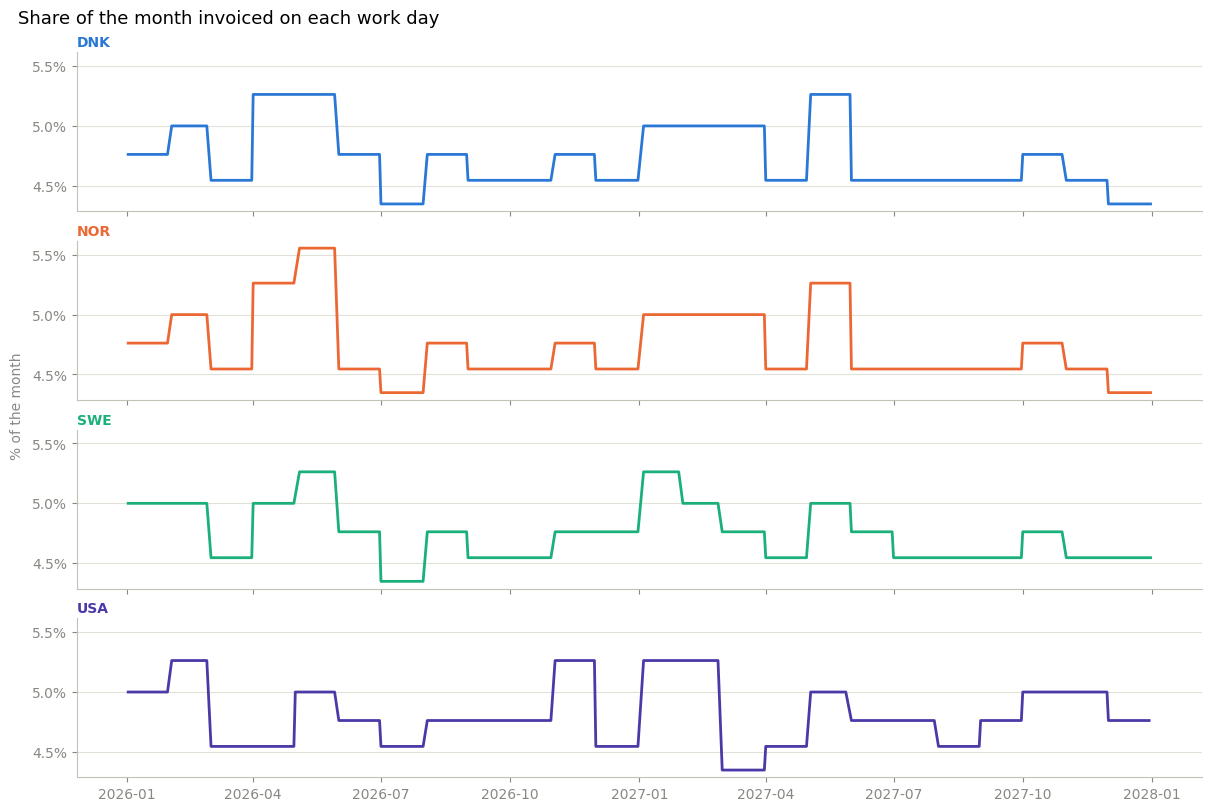

In [7]:
def tint(colour, strength=0.45):
    """A washed-out version of a palette colour, for the duty half of a stream pair.

    Same hue, lighter: duty reads as part of the stream it sits on rather than as a
    fifth unrelated thing, which a new colour from the palette would.
    """
    channels = (int(colour[position:position + 2], 16) for position in (1, 3, 5))
    return "#" + "".join(f"{round(c + (255 - c) * strength):02x}" for c in channels)


def style(ax, title, colour):
    """Shared panel styling: recessive grid and axes, the panel's name as its title."""
    ax.set_title(title, loc="left", fontsize=10, color=colour, fontweight="bold", pad=4)
    ax.yaxis.set_major_formatter(lambda v, _: f"{abs(v):.1f}%")  # abs: cash out is drawn below zero
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(RULE)
    ax.tick_params(colors=MUTED)


by_country = list(invoiced.groupby("country"))
fig, axes = plt.subplots(len(by_country), 1, figsize=(12, 2 * len(by_country)),
                         sharex=True, sharey=True, constrained_layout=True)

for ax, colour, (country, rows) in zip(axes, PALETTE, by_country):
    ax.plot(rows["invoice_date"], rows["pct_of_month"] * 100, color=colour, linewidth=2)
    style(ax, label(country), colour)

fig.suptitle("Share of the month invoiced on each work day", fontsize=13, x=0.01, ha="left")
fig.supylabel("% of the month", fontsize=10, color=MUTED)
plt.show()

## 5. Payment terms

A term is `(anchor, days)`:

- `invoice` - counted from the invoice date itself (`Net +30 days`).
- `month_end` - counted from the last day of the invoice month
  (`Current Month +30 days`), so every invoice in a month falls due on the
  same day.

Due dates are **nominal** days, not work days: a due date can and does land on a
weekend or a bank holiday. Only invoicing is restricted to work days.

`PAYMENT_TERMS` is global - `Net +30 days` means the same arithmetic everywhere.
What differs is the **mix**: the share of invoicing sitting on each term. There is
one mix per stream, and each is a table with one column per country.

To add a term, add a line to `PAYMENT_TERMS` and a row to the mixes. A new kind of
anchor needs one extra branch in `due_date()`.

In [8]:
def due_date(invoice_date, term):
    """When one invoice falls due. Nominal days: this can land on a weekend or holiday."""
    anchor, days = PAYMENT_TERMS[term]
    # MonthEnd(0) leaves a date that is already month end alone, and rolls the rest forward.
    start = invoice_date if anchor == "invoice" else invoice_date + pd.offsets.MonthEnd(0)
    return start + pd.Timedelta(days=days)

### The customer mix - how our customers pay us

In [9]:
require_all_countries(CUSTOMER_MIX.columns, "customer term mix")
CUSTOMER_MIX

,Denmark,Norway,Sweden,United States
Cash,5,5,5,5
Net +7 days,5,5,5,0
Net +14 days,20,20,15,5
Net +21 days,5,5,5,5
Net +30 days,40,40,40,45
Net +45 days,5,5,10,15
Net +60 days,5,5,5,15
Current Month +14 days,5,5,5,0
Current Month +21 days,0,0,0,0
Current Month +30 days,10,10,10,10


### The provider mix - how we pay for COGS

Our customers' terms are irrelevant on this side; what matters is the terms each
provider gives us. This comes in two pieces:

- **`PROVIDERS`** is global - a provider and the term it invoices us on. Defined
  once, because a provider's terms do not change depending on who is buying.
- **`PROVIDER_MIX`** is per country - how COGS spend is split between them, one
  column per country, the same shape as `CUSTOMER_MIX`.

The courier is carried all the way through rather than rolled up onto its term,
because section 8 sets the delay per courier - and because two couriers sharing a
term would otherwise become one at exactly the point it mattered. The rolled-up
table is still worked out below, as the thing to hold beside `CUSTOMER_MIX`: the
two shapes side by side are what say how differently we know the two sides.

In [10]:
require_all_countries(PROVIDER_MIX.columns, "provider mix")

# A provider with no term is a provider with no due date, so it would carry its spend into
# the model and never date it.
unknown = sorted(set(PROVIDER_MIX.index) - set(PROVIDERS))
if unknown:
    raise KeyError(f"No payment term defined for provider(s): {unknown}")

# The same mix rolled up onto terms. Nothing reads it - the pipeline keeps the courier - but
# it is the shape the customer side comes in, and it is worth being able to see the two
# beside each other. Two providers sharing a term simply add together here.
PROVIDER_TERM_MIX = PROVIDER_MIX.groupby(PROVIDER_MIX.index.map(PROVIDERS)).sum()
PROVIDER_TERM_MIX

,Denmark,Norway,Sweden,United States
Net +45 days,80,80,80,80
Net +60 days,20,20,20,20


## 6. Duty

Duty is charged on the way in and paid on the way out. We pay it on imports, and we
shift it to the customer - but the two figures are not the same, so neither side can
be derived from the other.

That rules out treating duty as a rate. A rate applied to revenue can only ever produce
a duty line that is a fixed fraction of revenue, which is not what the numbers do. So
duty is **budgeted in its own right on each side**, and becomes two more streams:

| | service | duty |
|---|---|---|
| money in | `revenue` | `revenue_duty` |
| money out | `cogs` | `cogs_duty` |

`Revenue Total` is `revenue + revenue_duty` and `COGS Total` is `cogs + cogs_duty`,
which is the way the figures already come.

**What duty is not is a separate clock.** Duty charged to a customer sits on the same
invoice as the service, so it collects on the customer's terms and runs as late as that
customer runs. Duty on the import belongs to the COGS it came with and is paid the same
way. So the two new streams need no new term mix and no new delay table - they point at
the ones already defined, and only the amounts differ.

That means duty costs almost nothing to add here: `STREAMS` gains two entries, which is
the extension section 7 was written for. It also means the old `DUTY_RATE` gross-up
disappears, and with it `cash_share` - every share is now a share of its own stream's
budget, and duty is just two of those streams.

The duty float is still visible, and worth looking for: duty out follows COGS terms and
duty in follows customer terms, so the gap between them is money being financed.

## 7. Four streams

The decomposition is identical for all four - spread the month over work days, split by
whoever pays, take the due date. What differs is the mix and how deep its index goes: a
customer is a payment term and nothing more, while a courier is a company, so the two
sides are split by different things and only one of them carries a name through. The same
function runs four times and each result is tagged with a `stream` column.

The two duty streams reuse their partner's mix outright, because duty rides the invoice
the service is on. That is the whole cost of adding them: two more entries in `STREAMS`,
pointing at tables that already exist.

One code path for all four. If any of them ever needs to diverge - a different invoicing
profile for providers, say - it is `STREAMS` that grows, not `distribute()`.

In [11]:
def apply_payment_terms(invoiced, mix, terms=None):
    """Split every invoiced day across whoever pays it, and date each split by when it is due.

    `mix` is indexed by the payer, and the two sides know their payers to different depths.
    A customer is a payment term and nothing more, so there the payer *is* the term. A
    courier is a company we buy from, so there the payer is the courier and `terms` says
    which term it invoices us on.

    The courier is kept as a column rather than rolled into its term, because the delay in
    section 8 is set per courier.
    """
    # Normalise each country's column, then reshape the table to one row per country/payer.
    weights = ((mix / mix.sum()).stack()
               .rename("weight").rename_axis(["payer", "country"]).reset_index())
    weights = weights[weights["weight"] > 0]  # a payer nobody uses is not a row worth carrying
    payments = invoiced.merge(weights, on="country")  # each invoiced day x that country's payers
    payments["pct_of_month"] *= payments["weight"]
    if terms:
        payments["provider"] = payments["payer"]
        payments["term"] = payments["payer"].map(terms)
    else:
        payments["provider"] = ""             # there is no customer dimension to name
        payments["term"] = payments["payer"]
    payments["due_date"] = [due_date(d, t)
                            for d, t in zip(payments["invoice_date"], payments["term"])]
    return payments.drop(columns=["weight", "payer"])


# Duty shares its partner's mix: it is on the same invoice, so it falls due the same day.
# The second half of each pair is how to read that mix's index - nothing on the customer
# side, because there the index is already the term, and PROVIDERS on the other, because
# there it is a courier and this is the term it invoices on.
STREAMS = {
    "revenue":      (CUSTOMER_MIX, None),
    "revenue_duty": (CUSTOMER_MIX, None),
    "cogs":         (PROVIDER_MIX, PROVIDERS),
    "cogs_duty":    (PROVIDER_MIX, PROVIDERS),
}

payments = pd.concat([apply_payment_terms(invoiced, mix, terms).assign(stream=stream)
                      for stream, (mix, terms) in STREAMS.items()], ignore_index=True)

payments.head()

,country,period,invoice_date,pct_of_month,provider,term,due_date,stream
0,Denmark,2026-01-01,2026-01-02,0.002381,,Cash,2026-01-02,revenue
1,Denmark,2026-01-01,2026-01-02,0.002381,,Net +7 days,2026-01-09,revenue
2,Denmark,2026-01-01,2026-01-02,0.009524,,Net +14 days,2026-01-16,revenue
3,Denmark,2026-01-01,2026-01-02,0.002381,,Net +21 days,2026-01-23,revenue
4,Denmark,2026-01-01,2026-01-02,0.019048,,Net +30 days,2026-02-01,revenue


In [12]:
# Each stream redistributes its own monthly budget, so every one of the four still adds
# back up to 100% of it.
(payments.groupby(["stream", "country", "period"])["pct_of_month"].sum()
         .groupby(["stream", "country"]).mean().round(4))

stream        country      
cogs          Denmark          1.0
              Norway           1.0
              Sweden           1.0
              United States    1.0
cogs_duty     Denmark          1.0
              Norway           1.0
              Sweden           1.0
              United States    1.0
revenue       Denmark          1.0
              Norway           1.0
              Sweden           1.0
              United States    1.0
revenue_duty  Denmark          1.0
              Norway           1.0
              Sweden           1.0
              United States    1.0
Name: pct_of_month, dtype: float64

## 8. Payment delays

The due date is when the money is *owed*. What actually happens is that it settles
late - and the two sides run late in different ways, so they are set on different
things. This is the section where that split shows.

**Money in.** A customer is a payment term and nothing more; there is no customer
dimension anywhere in this model. So `DELAY_CUSTOMER` is a term-by-country table, in
the same shape as the mixes, and a customer on 60-day terms running later than one on
14-day terms is a row of it.

**Money out.** A courier is a company we have a contract with, and one we argue with.
So `DELAY_PROVIDER` is a courier-by-country table, expanded here into one table per
courier of due month by country - and that is the version the workbook carries, on the
`COGS delay` sheet, where the figure for a month can be changed without this notebook
running again.

The month a provider delay is read off is the month the invoice falls **due**, not the
month the cost was budgeted in. *Anything due in March is running thirty days late* is
the sentence that gets said. It is also why `DUE_MONTHS` runs past the end of the
horizon: a December invoice on 60-day terms falls due the following February.

Duty is a case of its own on neither side. It rides the same invoice as the service it
belongs to, on the same term and from the same courier, so it reads the same rows.

This gives three dates per row, and it is worth keeping them apart:

- `due_date` - what the contract says.
- `expected_date` - due date plus the delay expected on it, still on nominal days.
- `payment_date` - that rolled onto a work day, in the next section.

**The provider side is a workbook figure, not a notebook one.** Section 15 writes `COGS
delay` as an input sheet, and makes the COGS rows on `Payment date cash` work their own
payment date out from it - so typing a figure there moves the cash. What is set here is
what that sheet is seeded with, and what every chart below is drawn at. Change a month
in the workbook and the two part company, on purpose.

**One limitation to be aware of.** A single average delay shifts a payment without
spreading it: a spike that was 20% on one day is still 20% on one day, just later. Real
delay statistics have a spread - some settle on time, a few run very late - and that
spread is what smooths a cash peak. If your statistics carry a distribution rather than
just a mean, this is the place to turn each delay into several weighted buckets, exactly
as the mixes do for terms.

> **Justo:** weakest part of the model. One average moves a spike, it doesn't flatten it, so
> the peaks in here are sharper than real life. Redo when we have proper delay stats.


In [13]:
def require_full_grid(table, what):
    """A gap in a delay table would leave a payment with no date at all."""
    require_all_countries(table.columns, what)
    missing = [term for term in PAYMENT_TERMS if term not in table.index]
    if missing:
        raise KeyError(f"No {what} defined for term(s): {missing}")


require_full_grid(DELAY_CUSTOMER, "customer payment delay")
require_all_countries(DELAY_PROVIDER.columns, "provider payment delay")

# Every month a COGS invoice can fall due in, which runs past the horizon: a December
# invoice on 60-day terms falls due the following February. Taken off the due dates
# themselves rather than off the horizon, so this cannot come out a month short.
DUE_MONTHS = sorted({f"{date:%Y-%m}" for date
                     in payments.loc[payments["stream"].isin(STREAMS_OUT), "due_date"]})

# One table per courier, a row per due month and a column per country - the shape the
# factoring settings are in, and the shape the COGS delay sheet is written from. Every
# month starts at its courier's figure, and DELAY_PROVIDER_BY_MONTH is where one of them
# is argued down.
DELAY_PROVIDER_MONTHLY = {
    provider: pd.DataFrame(
        [[DELAY_PROVIDER_BY_MONTH.get((provider, country, month),
                                      DELAY_PROVIDER.at[provider, country])
          for country in COUNTRIES] for month in DUE_MONTHS],
        index=DUE_MONTHS, columns=COUNTRIES)
    for provider in PROVIDER_MIX.index}

# A key nobody can read is the way this would go wrong quietly: it would not raise, the
# month would simply run at its courier's figure and the override would sit there looking
# as though it had been applied.
for key in DELAY_PROVIDER_BY_MONTH:
    provider, country, month = key
    if (provider not in PROVIDER_MIX.index or country not in COUNTRIES
            or month not in DUE_MONTHS):
        raise KeyError(f"Nothing in the model to delay for {key}")

# And a figure the workbook could not hold is one it would disagree with the moment
# anybody opened it, because the column it goes in will not accept it.
for provider, table in DELAY_PROVIDER_MONTHLY.items():
    outside = table[(table < 0) | (table > MAX_DELAY_DAYS)].stack()
    if not outside.empty:
        raise ValueError(f"{provider} delays outside 0-{MAX_DELAY_DAYS} days:\n{outside}")

DELAY_CUSTOMER

,Denmark,Norway,Sweden,United States
Cash,0,0,0,0
Net +7 days,2,2,2,4
Net +14 days,3,3,3,6
Net +21 days,3,3,4,7
Net +30 days,4,4,5,9
Net +45 days,5,5,6,11
Net +60 days,6,6,7,13
Current Month +14 days,3,3,4,6
Current Month +21 days,3,3,4,7
Current Month +30 days,4,4,5,9


In [14]:
def apply_delays(payments):
    """Shift each due date by the delay expected on it.

    The two sides are set on different things, so they are looked up on different things:
    the customer side on the term, which is the shape late-payment statistics come out in,
    and the provider side on the courier and the month the invoice falls due, which is the
    shape the conversation with a courier comes in.

    Duty is a case of its own on neither side. It rides the same invoice as the service it
    belongs to, on the same term and from the same courier, so it finds the same rows here
    without being named.
    """
    # Days as floats on both sides: one of the two merges below always misses, so the
    # column it fills is float whatever the table was, and pandas would rather not be asked
    # to guess whether the pair of them is really an integer.
    customer = (DELAY_CUSTOMER.stack().astype(float).rename("customer_days")
                .rename_axis(["term", "country"]).reset_index())
    provider = pd.concat(
        [table.stack().astype(float).rename("provider_days")
              .rename_axis(["due_month", "country"]).reset_index().assign(provider=name)
         for name, table in DELAY_PROVIDER_MONTHLY.items()], ignore_index=True)

    # The month the invoice falls due, which is what the provider side is set by - and the
    # same string the workbook builds for itself to look its own figure up on.
    out = payments.assign(due_month=payments["due_date"].dt.strftime("%Y-%m"))
    out = out.merge(customer, on=["term", "country"], how="left")
    out = out.merge(provider, on=["provider", "country", "due_month"], how="left")
    # A revenue row has no courier and a COGS row's term is not what its delay is set by,
    # so each side takes the one that was looked up for it.
    days = out["customer_days"].where(out["stream"].isin(STREAMS_IN), out["provider_days"])
    if days.isna().any():
        blank = out.loc[days.isna(), ["stream", "country", "term", "provider", "due_month"]]
        raise KeyError(f"No payment delay for:\n{blank.drop_duplicates()}")
    # Calendar days, like the terms themselves - the work-day roll comes after.
    out["expected_date"] = out["due_date"] + pd.to_timedelta(days, unit="D")
    return out.drop(columns=["customer_days", "provider_days"])


payments = apply_delays(payments)
payments[["stream", "country", "term", "provider", "due_date", "expected_date"]].head()

,stream,country,term,provider,due_date,expected_date
0,revenue,Denmark,Cash,,2026-01-02,2026-01-02
1,revenue,Denmark,Net +7 days,,2026-01-09,2026-01-11
2,revenue,Denmark,Net +14 days,,2026-01-16,2026-01-19
3,revenue,Denmark,Net +21 days,,2026-01-23,2026-01-26
4,revenue,Denmark,Net +30 days,,2026-02-01,2026-02-05


## 9. Back to work days: when the money actually moves

The money only moves on a work day, so an expected date landing on a weekend or a
bank holiday rolls **forward** to the next one.

That closes the loop: invoicing happens on work days, terms and delays are counted
in nominal days, and settlement lands back on work days.

Both streams roll on the country's own calendar. For a provider invoicing from
somewhere else that is an approximation - it is their calendar that would govern -
but it keeps one calendar per country, which is the simpler thing to maintain.

In [15]:
def to_work_day(country, date):
    """Roll a date forward to the next work day, leaving it alone if it already is one."""
    return CALENDARS[country].rollforward(date)


payments["payment_date"] = [to_work_day(country, date)
                            for country, date in zip(payments["country"], payments["expected_date"])]
payments = payments.sort_values(["stream", "country", "payment_date"]).reset_index(drop=True)
payments.head()

,country,period,invoice_date,pct_of_month,provider,term,due_date,stream,due_month,expected_date,payment_date
0,Denmark,2026-01-01,2026-01-02,0.009524,Provider 2,Net +60 days,2026-03-03,cogs,2026-03,2026-03-03,2026-03-03
1,Denmark,2026-01-01,2026-01-05,0.009524,Provider 2,Net +60 days,2026-03-06,cogs,2026-03,2026-03-06,2026-03-06
2,Denmark,2026-01-01,2026-01-06,0.009524,Provider 2,Net +60 days,2026-03-07,cogs,2026-03,2026-03-07,2026-03-09
3,Denmark,2026-01-01,2026-01-07,0.009524,Provider 2,Net +60 days,2026-03-08,cogs,2026-03,2026-03-08,2026-03-09
4,Denmark,2026-01-01,2026-01-08,0.009524,Provider 2,Net +60 days,2026-03-09,cogs,2026-03,2026-03-09,2026-03-09


## 10. Factoring

Some countries sell part of their invoicing to a bank, and those invoices settle on a clock
of their own that has nothing to do with the terms in section 5. The week's factored
invoices go out in one run on the Monday after the work. The bank pays out most of the face
value on the Thursday of that run week, whatever term the customer happens to be on - that
is the point of the arrangement, the money arrives on a schedule instead of when somebody
gets round to paying. The rest is held back until the customer has actually paid the bank,
and out of that held-back slice the bank takes its fee.

So one invoice can settle four different ways, and this section gives every row a leg to
say which. The row already carries a share of its stream's month; the leg says which of the
four routes that share travels, and a rate per country and month says how much goes down
each. The direct leg is what the customer still pays us on the old terms, and it is worth
one less the factored share. The advance is the factored share times whatever the bank
advances, and it lands on the Thursday. The retention is what is left of the factored share
once the bank has taken both its advance and its fee, and it keeps the payment date it
always had plus a day for the bank to pass it on. The fee is the factored share times the
bank's rate, on that same day, and it is money going out rather than in.

The four rates add to exactly one, whatever the three parameters are. That is why the fee
is a leg of its own rather than quietly netted off the retention: the shares still add up
to the budget, so the check in section 7 goes on meaning what it meant, and what is
actually received falls out as one less the fee without anybody having to assert it.

Duty is factored with the revenue it rides on. The bank buys the invoice and the duty is a
line on that invoice, so it is sold along with it - the same rule section 6 already applies
to terms and to delays.

The factored slice sits on the same term mix as everybody else. There is no customer
dimension in the model, so a set of factored customers is carried as a share of a country's
revenue rather than as a list of names. If those customers really are on different terms
that is a second mix, not a change to any of this.

The facility is set per country **and per month**. A bank facility is a bargain struck and
struck again rather than settled once, so the share sold, the advance and the fee are read
off the row for the month the invoice belongs to: a country can take a facility on halfway
through the horizon, give it up again, or keep it and sell less through it, and none of
those is a special case anywhere downstream.

What is still decided once for the whole horizon is whether a country carries the four legs
at all, because the rows are written when this notebook runs and only the rates on them
move afterwards. A country that factors in any month of the horizon carries them in all of
them; a month it does not factor in gets nought on three legs and the whole invoice back on
the direct one, which is the same answer as not having the rows. Only a country that never
factors at all can safely be left without them, and in option B not even that.

None of it touches the budget. Factoring is not invoicing - it changes when the money
arrives and how much of it survives the trip, not what was billed - so no P&L line and no
row on the budget sheet moves because of it.

> **Justo:** half the invoices sold now, 80 up front. Don't forget the retention - real money,
> just late. Fee gets its own line on purpose; it's the bank's, not a smaller sale.


In [16]:
def month_key(period):
    """How a month is spelled in the factoring tables: the year and the month, nothing else.

    Those tables are typed rather than generated, so their index is a month somebody can
    read and not a timestamp. This is the one place that turns one of the horizon's months
    into the row holding its figures.
    """
    return f"{period:%Y-%m}"


# The horizon, spelled the way every per-month table in this notebook is indexed - the
# factoring settings here, and the cost delays in section 11. Read from this rather than from
# a table's own index, so a table left with rows past the end of a horizon that has since been
# shortened contributes nothing rather than quietly extending it again.
MONTH_KEYS = [month_key(period) for period in periods]


def require_all_months(table, what):
    """Every month of the horizon needs its own row - a missing one has no figure to read.

    The country check beside it is the same idea one dimension over. Together they are what
    stops a horizon that grew, or a country that was added, from being answered off some
    other month's row instead of raising.
    """
    missing = [month for month in MONTH_KEYS if month not in table.index]
    if missing:
        raise KeyError(f"No {what} defined for: {missing}")


for config, what in ((FACTORING, "factoring flag"), (FACTORED_SHARE, "factored share"),
                     (ADVANCE_RATE, "advance rate"), (FACTORING_FEE, "factoring fee")):
    require_all_countries(config.columns, what)
    require_all_months(config, what)




def invoice_run(date):
    """The run that bills a day's work: the first Monday strictly after it.

    Strictly after, because a Monday's run covers the week up to it and not the day it
    goes out on. So a Monday's work waits seven days for the next run and a Friday's
    waits three.
    """
    return date + pd.Timedelta(days=7 - (date.weekday() - INVOICE_RUN_WEEKDAY) % 7)


def advance_date(country, date):
    """When the bank's share of one day's work lands.

    Counted from the nominal Monday rather than a rolled one. A bank holiday on the
    Monday delays the paperwork and not the money, and rolling the run first would push
    a whole week's advance out behind it for no reason. The Thursday itself still rolls,
    because nothing lands on a day the banks are shut.
    """
    return to_work_day(country, invoice_run(date) + pd.Timedelta(days=ADVANCE_OFFSET_DAYS))


def factors_ever(country):
    """Whether the bank buys anything of this country's in any month of the horizon.

    Which legs a country carries is a horizon-wide question even though the rates on them
    are monthly, because the rows are written once, when this notebook runs. A country
    taking a facility on in June needs its advance, retention and fee rows from January
    or June's money would have nowhere to land; the rate is what empties the months before
    it. Only a country answering No in every single month can safely have none at all.
    """
    return bool(FACTORING.loc[MONTH_KEYS, country].any())


# leg_rates() is asked the same question once per row of a table of sixty thousand, and
# there are only a few hundred distinct answers to it - four countries by twenty-four
# months by four streams. Each is worked out once and kept rather than read off four
# tables again every time. Keyed on all three, so no answer can outlive a change to any.
LEG_RATE_CACHE = {}


def leg_rates(country, period, stream):
    """What share of an invoice travels each leg. The four of them are the whole invoice.

    It takes the stream and not just the country, because only the streams the bank
    actually buys have four legs. Everything else keeps one, worth the whole invoice,
    whatever the facility says - and so does a stream in a month the country does not
    factor in. Both cases are the model exactly as it was before this section.

    And it takes the month, because a facility is not one bargain struck for the whole
    horizon. The share sold, the advance and the fee are read off the row for the month
    the invoice belongs to, so a country can start factoring, stop, or change what it
    sells partway through without any of it being a special case anywhere downstream.
    """
    cached = LEG_RATE_CACHE.get((country, period, stream))
    if cached is not None:
        return cached

    month = month_key(period)
    if stream not in FACTORED_STREAMS or not FACTORING.at[month, country]:
        rates = {"direct": 1.0, "advance": 0.0, "retention": 0.0, "fee": 0.0}
    else:
        factored = FACTORED_SHARE.at[month, country]
        advance, fee = ADVANCE_RATE.at[month, country], FACTORING_FEE.at[month, country]
        rates = {"direct":    1 - factored,
                 "advance":   factored * advance,
                 "retention": factored * (1 - advance - fee),
                 "fee":       factored * fee}
    LEG_RATE_CACHE[(country, period, stream)] = rates
    return rates


# A fee bigger than what the bank held back would make the retention negative, and a
# leg set that does not add to one invoice would quietly restate the budget. Every month
# as well as every country now: each of the ninety-six rows above can be edited on its
# own, and it is the edited one that will be wrong.
for country in COUNTRIES:
    for period in periods:
        for stream in STREAMS:
            rates = leg_rates(country, period, stream)
            if min(rates.values()) < 0:
                raise ValueError(f"The {stream} legs for {country} in {month_key(period)} "
                                 f"are not all payable: {rates}")
            if abs(sum(rates.values()) - 1) > 1e-12:
                raise ValueError(f"The {stream} legs for {country} in {month_key(period)} "
                                 f"do not add up to one invoice: {rates}")



# The revenue side, which is the only one with anything to show - and only the months in
# which something moved, since a facility left alone all the way through would otherwise
# print the same four numbers twenty-four times over. One row means constant throughout.
legs = pd.DataFrame({(label(country), LEG_LABELS[leg]):
                     [leg_rates(country, period, "revenue")[leg] for period in periods]
                     for country in COUNTRIES for leg in LEG_LABELS},
                    index=MONTH_KEYS)
legs[legs.ne(legs.shift()).any(axis=1)]

DNK                                                        NOR  \
        Direct Factoring advance Factoring retention Factoring fee Direct   
2026-01    0.5               0.4              0.0995        0.0005    1.0   

                                                               SWE  \
        Factoring advance Factoring retention Factoring fee Direct   
2026-01               0.0                 0.0           0.0    1.0   

                                                               USA  \
        Factoring advance Factoring retention Factoring fee Direct   
2026-01               0.0                 0.0           0.0    1.0   

                                                             
        Factoring advance Factoring retention Factoring fee  
2026-01               0.0                 0.0           0.0

### Splitting the streams into legs

Every row keeps its whole share of the month and gains a leg; the rate on that leg is
what decides how much of it travels that way. Nothing is subtracted here, which is what
lets the rates live in the workbook rather than in this notebook.

The advance is built from `invoiced` rather than from `payments`, before the split in
section 7 rather than after it. The bank buys the invoice, not the promise behind it, so
what it pays out does not depend on the term the customer is on - and a whole week of
work days ends up on one Thursday.

In [17]:
# The bank pays on its own clock rather than on the customer's, so these rows have no
# payment term to name. Kept as a value rather than left blank so it reads on the export.
ADVANCE_TERM = "Factored - no term"


def leg_flow(stream, leg):
    """Which side of the cash flow one leg lands on.

    The fee is the odd one out: it hangs off a revenue stream but it is money going out,
    so which side a row falls on cannot be read off its stream alone any more.
    """
    if leg == "fee":
        return "Out"
    return "In" if stream in STREAMS_IN else "Out"


def advance_leg(invoiced, countries):
    """What the bank pays out, taken off the invoiced days rather than the payment terms.

    One row per work day still, not one per Thursday: the two cash sheets group by their
    own date anyway, and keeping the day the work was done means these rows carry an
    invoice date like every other row on the export.
    """
    days = invoiced[invoiced["country"].isin(countries)]
    # Nominal, like every other date in the model before the work-day roll.
    settles = days["invoice_date"].map(invoice_run) + pd.Timedelta(days=ADVANCE_OFFSET_DAYS)
    dated = days.assign(
        # No term and no courier: this is the bank settling, on the revenue side.
        term=ADVANCE_TERM, provider="", leg="advance",
        # The bank settles on a schedule rather than when it gets round to it, so nothing
        # on this leg is ever owed late: the day it falls due is the day it lands.
        due_date=settles, expected_date=settles,
        payment_date=[advance_date(country, date)
                      for country, date in zip(days["country"], days["invoice_date"])])
    # Duty is on the same invoice, so the bank buys it on the same terms.
    return pd.concat([dated.assign(stream=stream) for stream in FACTORED_STREAMS],
                     ignore_index=True)


def apply_factoring(payments, invoiced):
    """Give every row a leg, and add the three that a factored invoice also settles in."""
    sold = payments["stream"].isin(FACTORED_STREAMS)
    if FACTORING_IS_A_NOTEBOOK_SETTING:
        # Whether the country factors at all, and not whether it factors in this row's
        # month. Dropping the rows for the months it does not would leave a country that
        # switches the facility on partway through with nowhere to put that money; the
        # rate on them is nought in those months, which comes to the same thing and keeps
        # the answer a workbook figure rather than a shape decided here.
        sold &= payments["country"].map(factors_ever)

    # The held-back slice keeps the term and the delay it always had. All that is added is
    # the day the bank takes to pass the money on once the customer has paid it.
    bank = pd.Timedelta(days=BANK_DELAY_DAYS)
    held = payments[sold]
    retention = held.assign(leg="retention", due_date=held["due_date"] + bank,
                            expected_date=held["expected_date"] + bank)
    retention["payment_date"] = [to_work_day(country, date) for country, date
                                 in zip(retention["country"], retention["expected_date"])]

    factoring = [country for country in COUNTRIES
                 if factors_ever(country) or not FACTORING_IS_A_NOTEBOOK_SETTING]
    return pd.concat([payments.assign(leg="direct"),
                      advance_leg(invoiced, factoring),
                      retention,
                      # Taken out of the retention on the day it is released, so the fee
                      # is the same rows over again under a different name.
                      retention.assign(leg="fee")], ignore_index=True)


payments = apply_factoring(payments, invoiced)
payments = payments.sort_values(["stream", "leg", "country", "payment_date"]).reset_index(drop=True)

# The legs of a stream still add up to that stream's month, because the rates for that
# month do. Getting one of them wrong is the way this section would go wrong quietly, so
# it is checked here rather than left to be noticed on a chart - and it is checked row by
# row, which is what catches a rate read off the wrong month as well as a wrong rate.
rated = payments["pct_of_month"] * [
    leg_rates(country, period, stream)[leg] for country, period, stream, leg
    in zip(payments["country"], payments["period"], payments["stream"], payments["leg"])]
totals = rated.groupby([payments["stream"], payments["country"], payments["period"]]).sum()
if not totals.round(9).eq(1).all():
    raise ValueError(f"Legs do not add up to the month:\n{totals[totals.round(9) != 1]}")

payments.groupby(["leg", "stream"]).size().unstack(fill_value=0)


stream,cogs,cogs_duty,revenue,revenue_duty
leg,,,,
advance,0,0,2021,2021
direct,4042,4042,17191,17191
fee,0,0,17191,17191
retention,0,0,17191,17191


## 11. When the costs move

Revenue and COGS reach cash through a payment term. Everything under them on the P&L does
not. A payroll run goes out on the last working day whatever anybody's terms say, rent on a
date in the lease, an IT bill in dribs across the month. So these lines get a rule instead
of a term.

Four rules cover what is there now. Month end puts all of it on the last working day of the
month. Mid month puts all of it on the 15th, or the next working day if the 15th is not one.
Spread puts it equally across the month's working days. And none means no cash effect at
all, which is what bad debt is: written off rather than paid out.

There was a fifth - one week of the month, with a week number typed beside each line to say
which. Nothing was ever set to it, so every line carried a number that decided nothing, and
the sheet asked a question nobody had to answer. It is gone, along with the column.

`COST_TIMING` holds one rule per line per country, in the same line-by-country shape the
mixes in section 5 use, so a country that pays its rent differently is one cell and not a
special case.

These come out at week grain rather than day grain, because that is what the cash flow
sheets read and because it is what makes the rule switchable in the workbook. A month is
cut into the weeks its working days touch, and each week carries five facts: how many of
the month's working days fall in it and how many the month has, whether the last working
day is in it, whether the mid-month day is, and which of the month's weeks it is out of how
many there are. Every one of the five rules is arithmetic over those five facts, so the
rule itself can be a dropdown in Excel with no new rows sitting behind it. The table is
small - four countries by twenty-four months by about five weeks - and it does not depend
on the cost line at all, so one copy of it serves all twelve.

A week that straddles two months appears once under each, holding only that month's days.
The month totals on the cash flow sheets are then real calendar months and tie to the
budget month the money came from, which matters most exactly where a straddling week is
most likely to hurt: the payroll on the last working day.

> **Justo:** `week` isn't used yet. It's there so a week-two cost has somewhere to go later.


In [18]:
require_all_countries(COST_TIMING.columns, "cost timing")

missing = [line for line in SCHEDULED_LINES if line not in COST_TIMING.index]
if missing:
    raise KeyError(f"No cash timing defined for cost line(s): {missing}")
unknown = sorted(set(COST_TIMING.to_numpy().ravel()) - set(TIMING_RULES))
if unknown:
    raise KeyError(f"Not one of the timing rules: {unknown}")




def mid_month_day(country, period):
    """The 15th, or the next work day if the 15th is not one."""
    return to_work_day(country, period + pd.Timedelta(days=MID_MONTH_DAY - 1))


def month_weeks(country, period):
    """One row per week a month's work days touch, and what the rules need to know of it.

    The facts are between them enough to work out every rule's share, which is what lets
    the rule be a dropdown in the workbook rather than a decision taken here: nothing
    downstream needs a different set of rows when the rule changes, only different weights
    on the rows that are already there.

    The two dates beside them are what a *delay* needs, which a share cannot answer. A
    share says which week of a month a cost lands in; a delay has to know the day, because
    it is counted in days and lands wherever it lands - usually in another month entirely.
    """
    days = work_days(country, period)
    mid, last = mid_month_day(country, period), days[-1]
    groups = list(days.isocalendar().groupby(["year", "week"]))
    return [{"country": country, "period": period,
             "week_key": f"{year}-W{week:02d}",
             "days": len(group), "month_days": len(days),
             "has_last": int(last in group.index),
             "has_mid": int(mid in group.index),
             # The day each rule would pay on, for this month and this week of it.
             "month_end": last, "mid_month": mid}
            for (year, week), group in groups]


COST_WEEKS = pd.DataFrame([week for country in COUNTRIES for period in periods
                           for week in month_weeks(country, period)])


COST_DELAY_MONTHLY = {
    line: pd.DataFrame(
        [[COST_DELAY_BY_MONTH.get((line, country, month), COST_DELAY.at[line, country])
          for country in COUNTRIES] for month in MONTH_KEYS],
        index=MONTH_KEYS, columns=COUNTRIES)
    for line in SCHEDULED_LINES}

# A key nobody can read is how this would go wrong quietly: the month would run at the line's
# usual figure and the override would sit there looking as though it had been applied.
for key in COST_DELAY_BY_MONTH:
    line, country, month = key
    if line not in SCHEDULED_LINES or country not in COUNTRIES or month not in MONTH_KEYS:
        raise KeyError(f"Nothing in the model to delay for {key}")

for line, table in COST_DELAY_MONTHLY.items():
    outside = table[(table < 0) | (table > MAX_COST_DELAY_DAYS)].stack()
    if not outside.empty:
        raise ValueError(f"{line} delays outside 0-{MAX_COST_DELAY_DAYS} days:\n{outside}")


def cost_base_date(rule, week):
    """The day a cost line pays on under its rule, before any delay is counted from it.

    A spread has no such day, and neither has a line that never reaches cash. Both are given
    the end of their month, which is the day a delayed spread piles up to and is simply
    unread for the other.
    """
    if rule == "mid_month":
        return week["mid_month"]
    return week["month_end"]


def rule_share(rule, week):
    """What share of a month's cost lands in one of its weeks, under one rule.

    Written out again in Excel against the same facts, so this and the workbook agree by
    construction rather than by anybody keeping them in step.
    """
    if rule == "none":
        return 0.0
    if rule == "month_end":
        return float(week["has_last"])
    if rule == "mid_month":
        return float(week["has_mid"])
    return week["days"] / week["month_days"]        # spread, the only one left


def cost_cash(weeks=COST_WEEKS, timing=COST_TIMING, delays=COST_DELAY_MONTHLY):
    """One row per country, cost line, month and week, and the share landing in it.

    A row with no delay on it is exactly what it was before this section knew what a delay
    was: its share comes off the rule, and it lands in its own week. A delayed one keeps the
    same rows and moves the money between them - all of it onto one row, dated by the day the
    rule would have paid plus the days it is late, rolled onto a work day like everything
    else in this model.

    The one rule that changes shape rather than just moving is the spread, which collapses
    onto the week its month ends in. There is no such thing as a dribble that is thirty days
    late; there is only a month's worth of dribble, paid at once, thirty days on.
    """
    rows = []
    for week in weeks.to_dict("records"):
        country, period = week["country"], week["period"]
        month = month_key(period)
        for line in SCHEDULED_LINES:
            rule = timing.at[line, country]
            delay = int(delays[line].at[month, country])
            share = rule_share(rule, week)
            if delay and rule == "spread":
                share = float(week["has_last"])
            base = cost_base_date(rule, week)
            paid = to_work_day(country, base + pd.Timedelta(days=delay))
            rows.append((country, period, line, rule, week["week_key"], share, delay,
                         base, paid, week["month_end"], week["mid_month"]))
    return pd.DataFrame(rows, columns=["country", "period", "line", "rule", "week_key",
                                       "share", "delay", "base_date", "paid_date",
                                       "month_end", "mid_month"])


costs = cost_cash()

# A line pays its month once over, or not at all where the rule says it never reaches cash.
# Anything in between means a rule is dropping money on the floor.
totals = costs.groupby(["country", "period", "line"])["share"].sum().round(9)
paid = costs.groupby(["country", "period", "line"])["rule"].first() != "none"
if not totals.eq(paid.astype(float)).all():
    raise ValueError(f"A month's cost does not add up:\n{totals[totals.ne(paid.astype(float))]}")

costs.groupby(["rule", "line"]).size().unstack(fill_value=0).T

rule,mid_month,month_end,none,spread
line,,,,
mp_courier,0,465,0,0
mp_ff,0,465,0,0
sga_admin,0,0,0,465
sga_bad_debt,0,0,465,0
sga_external,0,465,0,0
sga_it,0,0,0,465
sga_rent,0,465,0,0
sga_sales,0,0,0,465
sga_sla,0,465,0,0


## 12. VAT

VAT has three sides and a cash forecast needs all three. There is the VAT we charge our
customers and collect. There is the VAT our suppliers charge us and we pay. And there is
the settlement with the government, which is the difference between the two, handed over on
that country's own schedule. Miss any one of the three and the cash flow is wrong.

**None of it touches the P&L.** VAT is not revenue and it is not a cost - it is somebody
else's money passing through the bank account. The eight P&L sheets, the four budget streams
and every share in this model are unchanged by this section. The only thing VAT adds is
*when* that money passes through, which is the whole reason to model it.

### It moves with the invoice, not with the payment

This is the part that matters. VAT falls due on the **invoice**, so a customer invoiced in
March who pays in May is VAT we owe the government on March's settlement - before their money
has arrived. Checked against each authority rather than assumed, and it is the same rule in
all three:

| | the rule | source |
|---|---|---|
| Denmark | the tax point is delivery, but the *invoice date* is the tax point where invoicing happens at or shortly after it - ML § 23, stk. 2 | [info.skat.dk D.A.7.2.4](https://info.skat.dk/data.aspx?oid=2060294) |
| Norway | output VAT is reported in the term the sales document is **issued** | [Skatteetaten](https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/vat-return/) |
| Sweden | accrual is the main rule; the cash method is open only below SEK 3m of turnover, far under this business | [Skatteverket](https://www.skatteverket.se/servicelankar/otherlanguages/englishengelska/businessesandemployers/nonswedishbusinesseswithoperationsinsweden/reportingvat.4.676f4884175c97df419ad5.html) |

**But it floats both ways, and that is the half worth adding.** Input VAT is deductible when
the *supplier's* invoice is dated, not when we pay it - so on the 45- and 60-day provider
terms in section 5 we reclaim VAT weeks before that money leaves. The drag on the receivable
side is real, and so is a pull the other way on the payable side, and what reaches the bank
account is the **net** of the two. So this section keeps VAT collected, VAT paid and the
settlement as three separate lines rather than one, because the netting is the answer and an
answer you cannot see the working of is not worth much.

### Why this costs almost nothing to build

Section 3 spreads each month's budget across **that month's own work days**, so every invoice
date in this model already sits inside the month it was budgeted in. The accrual base for a
settlement period is therefore just the P&L months the period covers - there is no day-level
VAT to work out, and nothing is added to the forty-five thousand row payment sheet.

The same is true of the collection side. Since the bank buys a factored invoice at face value
and the VAT is on the face of it, all four legs carry VAT in the same proportion they carry
everything else - so the VAT on sales is the revenue lines already on a cash flow sheet times
the rate, and not a column on a sheet nobody wants to grow.

### The rates and the schedules

All three VAT countries in scope are on a 25% standard rate. What differs is the clock, and
it differs a lot: Denmark on quarterly settlement does not pay January's VAT until 1 June.

| country | rate | the schedule as seeded | deadline | exception |
|---|---|---|---|---|
| Denmark | 25% | monthly, above DKK 50m | 25th of the following month | June's return runs to 17 August |
| Norway | 25% | bi-monthly, at any size | one month and ten days after the term | term 3, May-June, runs to 31 August |
| Sweden | 25% | monthly, above SEK 40m | 26th of the following month | December runs to 27 January |
| United States | - | no VAT at all | - | - |

The alternatives each country's turnover thresholds allow - Danish quarterly and half-yearly,
Swedish quarterly and the low-turnover 12th, Norwegian annual - are all written out in
`VAT_SCHEDULES` with their sources, so a country crossing a threshold is a one-word edit to
`VAT_FREQUENCY` rather than a rebuild. Every deadline rolls **forward** onto a work day,
which is what all three authorities do and what `to_work_day()` has been doing since
section 9.

### The United States

The United States has no VAT, and that is not the same as a rate of nought. It taxes at the
point of sale, state by state, on a different base and a different return - and a stand-alone
freight or courier service is untaxed in most states. So `VAT_RATE` holds `None` for it and
no settlement is written. Its cash flow sheets still carry the three VAT rows, sitting at
nothing, exactly the way they carry the factoring rows for a country with no facility: twelve
sheets, one layout.

Sales tax is a real tax and a real cash flow, and if it should be in here it wants its own
section rather than this one bent around it.

### Duty, on both sides, carries none

Neither duty stream carries VAT, for two entirely different reasons.

**Duty we recharge** is a disbursement - duty paid in the customer's own name sits outside the
taxable amount rather than zero-rated inside it, which is the ordinary treatment for a
forwarder clearing goods as agent. Invoice it in our own name and that changes.

**Duty we pay on the import** is the interesting one, and the answer is cleaner than it
looks: **zero, on the same date, with no gap between the credit and the debit.** Under
postponed import VAT accounting the import VAT is declared *and* deducted on the same return
for the same period, so the two cancel inside one number before any money moves. Nothing is
paid at the border and nothing is refunded separately - there is no lag to model, because
neither entry is a payment. Sweden
[says so outright](https://www.skatteverket.se/foretag/moms/kopavarorochtjanster/inkopfranlanderutanforeu/kopavarorfranlanderutanforeuimport.4.361dc8c15312eff6fd37208.html),
[Norway](https://www.skatteetaten.no/en/business-and-organisation/vat-and-duties/vat/foreign/import/calculating-and-reporting-vat-on-goods-imports/)
has the importer work it out and enter it on the return rather than pay it at the border, and
[Denmark](https://info.skat.dk/data.aspx?oid=2085655) reports it on the return and deducts it
under ML § 37, stk. 2, nr. 3.

Two things would break that netting, and neither is the case here. Import VAT that is not
fully deductible leaves a real payment on that period's settlement. And a customs agent has
no deduction at all for import VAT on a customer's goods - which is exactly why the
[disbursement rules](https://info.skat.dk/data.aspx?oid=2153745) exist.

### The cost side, where some of it carries VAT and some does not

`VAT_ON_COST` is a line-by-country table in the same shape as `COST_TIMING`: the share of each
scheduled line a supplier charges VAT on top of. Nought on manpower and staff cost, because
employment is not a supply and there is no VAT on a payroll run. Nought on bad debt, which
never reaches cash at all. One on the rest.

`VAT_RECLAIMED` sits beside it and answers a **different question**: how much of that VAT we
actually get back at the next settlement. The two part company more often than one table would
let you say. Deduction on passenger cars is denied outright in all three countries, and so is
representation - and VAT that is charged and cannot be deducted is paid out and never returns,
which makes it a real cost rather than a float. Both are seeded at one, which is right for a
courier fleet of vans and an ordinary office, and the two lines to revisit are named in the
comments beside the table.

### When we are owed rather than owing

A period where we paid more VAT than we charged is a period the government owes us. That is
one signed settlement line rather than two: it goes negative, which lowers cash out and lifts
the net. What it does not do is land on the same day, because money coming back arrives more
slowly than money going out - so a refund is dated **deadline plus a repayment lag**, 21 days
in Denmark and three weeks in Norway. Counted from the deadline rather than from the filing
date, which is the conservative reading: a business owed money files early.

> **Justo:** Norway term 3 is why I wanted this. Invoice 1 May, VAT sits until 31 August.
>
> I had it as a one-way drag. It isn't - we reclaim on purchase invoices we haven't paid yet
> either. Only the net matters, hence three rows and not one.
>
> Note to self: 10th of the month in Denmark is A-skat, not moms. Moms is the 25th.


In [19]:
# The three sides of VAT reach cash on two clocks, and only one of them is new here. What we
# collect and what we pay ride the invoices they sit on, which sections 7 to 11 have already
# dated - so those need nothing from this cell. What settles with the government does: one
# payment per country per settlement period, worked out from the months that period covers
# and dated by that country's own deadline.

if not FACTORING_BUYS_GROSS_OF_VAT:
    raise NotImplementedError(
        "VAT on sales is worked out from the revenue lines already on a cash flow sheet, "
        "which is only right while the bank buys the invoice at its face value. Buying net "
        "of VAT puts the VAT on the customer's clock rather than the bank's, and that needs "
        "a VAT column on a forty-five thousand row sheet rather than a flag here.")


def has_vat(country):
    """Whether this country has a VAT at all.

    A different question from whether its rate is nought, and the reason the rate is None
    rather than 0.0 for a country without one: nothing downstream should write a settlement
    worth nothing on a schedule that does not exist.
    """
    return VAT_RATE[country] is not None


VAT_COUNTRIES = [country for country in COUNTRIES if has_vat(country)]

require_all_countries(VAT_RATE, "VAT rate")
require_all_countries(VAT_FREQUENCY, "VAT settlement frequency")
require_all_countries(VAT_REFUND_DAYS, "VAT refund lag")
require_all_countries(VAT_ON_COST.columns, "VAT charged on cost")
require_all_countries(VAT_RECLAIMED.columns, "VAT reclaimed on cost")

# A country half set up is how this would go wrong quietly. A rate with no schedule would
# charge VAT it never settles, which reads as a business that keeps the government's money;
# a schedule with no rate would settle nothing, punctually.
for country in COUNTRIES:
    frequency = VAT_FREQUENCY[country]
    if has_vat(country) and not frequency:
        raise KeyError(f"{country} has a VAT rate but no settlement frequency")
    if frequency and not has_vat(country):
        raise KeyError(f"{country} has a settlement frequency but no VAT rate")
    if frequency and (country, frequency) not in VAT_SCHEDULES:
        written = sorted(name for name, _ in
                         ((f, c) for c, f in VAT_SCHEDULES if c == country))
        raise KeyError(f"No VAT schedule written for {country} on {frequency!r}. "
                       f"What is written for it: {written}")

# The two cost tables are shares, and a share outside nought to one is not one.
for table, what in ((VAT_ON_COST, "VAT charged on cost"),
                    (VAT_RECLAIMED, "VAT reclaimed on cost")):
    missing = [line for line in SCHEDULED_LINES if line not in table.index]
    if missing:
        raise KeyError(f"No {what} defined for cost line(s): {missing}")
    outside = table[(table < 0) | (table > 1)].stack()
    if not outside.empty:
        raise ValueError(f"{what} is a share, and these are not:\n{outside}")




# What a settlement period is called. A monthly one is spelled the way MONTH_KEYS already
# spells a month, so a settlement and a budget month read side by side. The rest take the
# letter their own paperwork uses: T for a Norwegian term, Q for a quarter, H for a half.
VAT_PERIOD_MARK = {2: "T", 3: "Q", 6: "H"}


def vat_period_label(months, year, index):
    """`2026-03`, `2026-T2`, `2026-Q1`, `2026-H1`, or `2026` for a whole year."""
    if months == 1:
        return f"{year}-{index:02d}"
    if months == 12:
        return str(year)
    return f"{year}-{VAT_PERIOD_MARK[months]}{index}"


def vat_due_date(country, schedule, last_month):
    """The day a period's return and its money both fall due, rolled onto a work day.

    Filing and payment share a deadline in all three countries in scope, so one date does for
    both. It is counted from the month the period *ends* in, which is the shape all three
    authorities state their rule in, and the two kinds of exception are applied in the order
    they are keyed on: the period's own last month first, then the month the deadline lands
    in - which is Sweden's January and August rule and cannot be known until the rest is.

    Rolled forward, like every date in this model since section 9, and for the same reason
    each authority rolls it: nothing settles on a day the banks are shut.
    """
    months_on, day = schedule["exceptions"].get(last_month.month, schedule["due"])
    deadline = last_month + pd.DateOffset(months=months_on)
    day = schedule.get("by_deadline_month", {}).get(deadline.month, day)
    # A rule asking for the 31st of a thirty-day month would raise rather than settle.
    return to_work_day(country, deadline.replace(day=min(day, deadline.days_in_month)))


def vat_calendar_rows(country):
    """One row per settlement period this country files over the horizon.

    Periods are cut from the **calendar** and not from the horizon: a Norwegian term is
    January and February whether or not the forecast happens to start in January. So a
    horizon that starts or ends part-way through a period gets a period holding only the
    months actually in it, and `months` says how many that is. A short period at either end
    is a real thing rather than a mistake, and it is named here instead of quietly filled in
    with months nobody budgeted.
    """
    schedule = VAT_SCHEDULES[(country, VAT_FREQUENCY[country])]
    length = schedule["months"]
    if 12 % length:
        raise ValueError(
            f"A {length}-month settlement period does not divide a year, so one of them "
            f"would straddle a year end. The workbook finds a period's months by matching "
            f"one year and a range of months, which cannot say that.")

    grouped = {}
    for period in periods:
        grouped.setdefault((period.year, (period.month - 1) // length + 1), []).append(period)

    rows = []
    for (year, index), months in grouped.items():
        last = max(months)
        period_end = last + pd.offsets.MonthEnd(0)
        due = vat_due_date(country, schedule, last)
        rows.append({
            "country": country, "code": label(country),
            "period": vat_period_label(length, year, index),
            "first_month": month_key(min(months)), "last_month": month_key(last),
            "months": len(months), "whole_period": len(months) == length,
            "rate": VAT_RATE[country], "due_date": due,
            # Money owed back arrives more slowly than money owed out, so a period we are in
            # credit on lands later than one we are in debit on. Rolled as well: a repayment
            # does not arrive on a day the banks are shut either.
            "refund_date": to_work_day(
                country, due + pd.Timedelta(days=VAT_REFUND_DAYS[country])),
            # What the float actually comes to, which is the whole reason for this section.
            # The two brackets it: an invoice on the last day of the period waits the first
            # figure, and one on the first day of it waits the second.
            "days_after_period": (due - period_end).days,
            "days_from_period_start": (due - min(months)).days,
            # Kept for the coverage check below and dropped before the frame is shown.
            "keys": [month_key(month) for month in months],
        })
    return rows


vat_calendar = pd.DataFrame([row for country in VAT_COUNTRIES
                             for row in vat_calendar_rows(country)])

# Every month of the horizon settles once, in exactly one period. A month in two periods pays
# its VAT twice and a month in none never pays it at all, and neither of those shows up as
# anything but a number that looks slightly off - which is the kind of wrong worth raising on.
for country in VAT_COUNTRIES:
    settled = sorted(key for keys in vat_calendar.loc[vat_calendar["country"] == country,
                                                      "keys"] for key in keys)
    if settled != MONTH_KEYS:
        twice = sorted({key for key in settled if settled.count(key) > 1})
        never = sorted(set(MONTH_KEYS) - set(settled))
        raise ValueError(f"{country} does not settle its horizon exactly once over - "
                         f"settled twice: {twice}, never settled: {never}")

# And every date it produces has to be inside the years the calendars know about, or a
# deadline would fail to roll off a holiday it should have rolled off. A deadline counted in
# whole months is exactly the kind of date that lands on New Year's Day.
reach = vat_calendar["refund_date"].dt.year.max()
if reach > max(HOLIDAY_YEARS):
    raise ValueError(f"VAT dates reach {reach} and the bank holiday calendars stop at "
                     f"{max(HOLIDAY_YEARS)}. Widen HOLIDAY_HEADROOM_YEARS in section 3.")

vat_calendar = vat_calendar.drop(columns=["keys"])

# The first year of it, which is enough to see how differently the three clocks run -
# `vat_calendar` holds the whole horizon. The two day counts are the point: they bracket how
# long a month's VAT sits with us before it goes, and the spread between one country and
# another is money.
vat_calendar[vat_calendar["period"].str.startswith(str(periods.min().year))]


,country,code,period,first_month,last_month,months,whole_period,rate,due_date,refund_date,days_after_period,days_from_period_start
0,Denmark,DNK,2026-01,2026-01,2026-01,1,True,0.25,2026-02-25,2026-03-18,25,55
1,Denmark,DNK,2026-02,2026-02,2026-02,1,True,0.25,2026-03-25,2026-04-15,25,52
2,Denmark,DNK,2026-03,2026-03,2026-03,1,True,0.25,2026-04-27,2026-05-18,27,57
3,Denmark,DNK,2026-04,2026-04,2026-04,1,True,0.25,2026-05-26,2026-06-16,26,55
4,Denmark,DNK,2026-05,2026-05,2026-05,1,True,0.25,2026-06-25,2026-07-16,25,55
5,Denmark,DNK,2026-06,2026-06,2026-06,1,True,0.25,2026-08-17,2026-09-07,48,77
6,Denmark,DNK,2026-07,2026-07,2026-07,1,True,0.25,2026-08-25,2026-09-15,25,55
7,Denmark,DNK,2026-08,2026-08,2026-08,1,True,0.25,2026-09-25,2026-10-16,25,55
8,Denmark,DNK,2026-09,2026-09,2026-09,1,True,0.25,2026-10-26,2026-11-16,26,55
9,Denmark,DNK,2026-10,2026-10,2026-10,1,True,0.25,2026-11-25,2026-12-16,25,55


## 13. When the money moves

One invoice month at a time, because shares of different months cannot be added
together without the amounts behind them. Money in is drawn upwards and money out
downwards, and each side is **stacked**: the service first, the duty riding on it in the
lighter shade. The height of a stack is that side's total.

**The four halves are not to scale against each other.** Each is a share of its own
monthly budget, and those are four different numbers. The shapes are comparable; the
heights are not. Netting them into a cash position needs the amounts.

Revenue is spikier than COGS because customers sit across many terms while COGS sits on
just two, so COGS lands late and in two clean blocks. Duty follows its partner exactly -
same days, same spikes - so the pairs move together and only the size of the lighter
band changes.

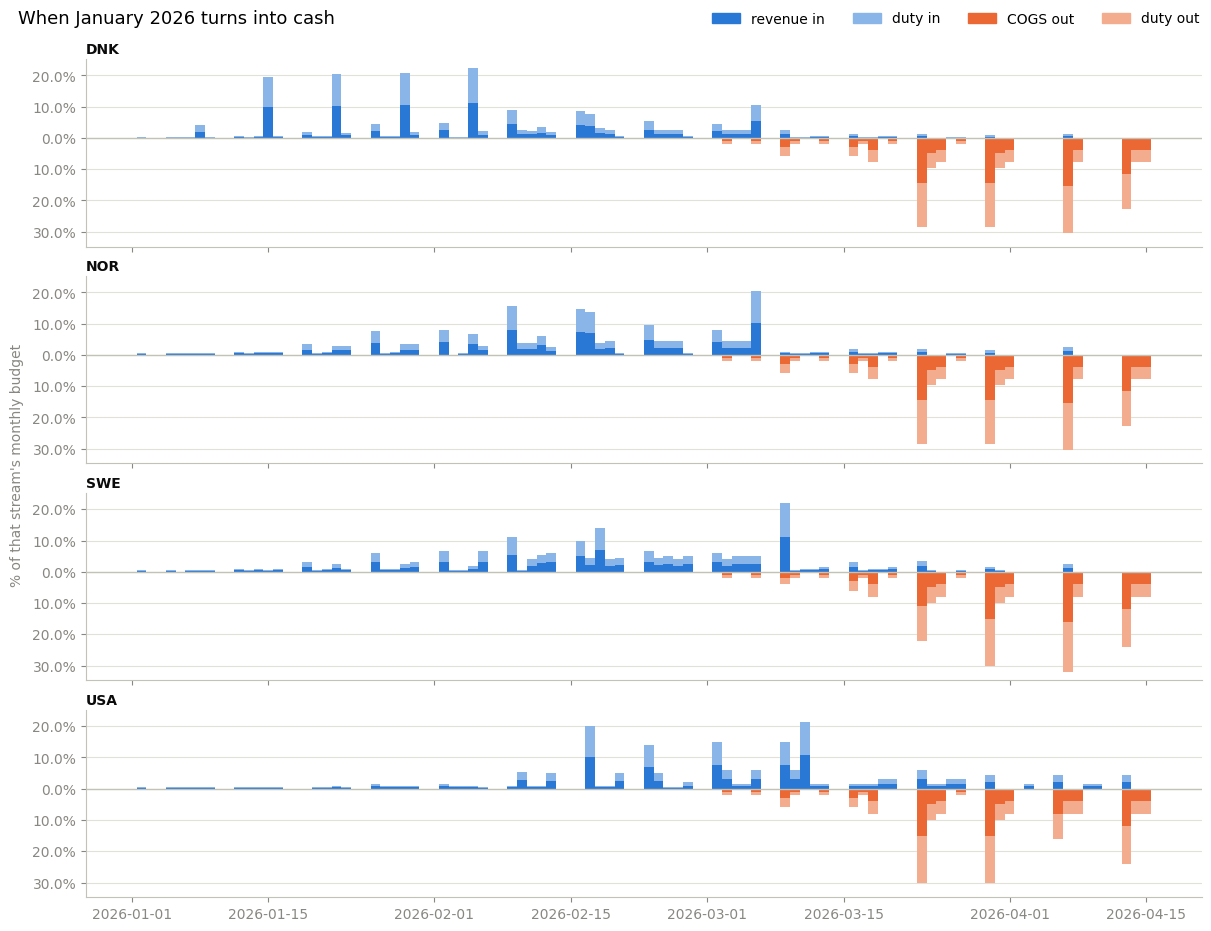

In [20]:
month = payments["period"].min()  # change this to look at another invoice month
subset = payments[payments["period"] == month].copy()

# What a row is actually worth once the rate its leg carries in this month is applied.
# Adding the raw shares across legs would count a factored invoice four times over. The
# fee goes in negative rather than becoming a stream of its own, so a revenue bar here is
# net of the bank's cut. The month is `month`: every row in the subset is one of its own.
subset["cash"] = [share * leg_rates(country, month, stream)[leg] * (-1 if leg == "fee" else 1)
                  for country, stream, leg, share
                  in zip(subset["country"], subset["stream"], subset["leg"],
                         subset["pct_of_month"])]

SIGN = {**{stream: 1 for stream in STREAMS_IN},      # cash in up, cash out down
        **{stream: -1 for stream in STREAMS_OUT}}
# Colour means side; the lighter half of each pair is the duty riding on it.
STREAM_COLOUR = {"revenue": PALETTE[0], "revenue_duty": tint(PALETTE[0]),
                 "cogs": PALETTE[1], "cogs_duty": tint(PALETTE[1])}
ORDER = list(STREAMS_IN) + list(STREAMS_OUT)

by_country = list(subset.groupby("country"))
fig, axes = plt.subplots(len(by_country), 1, figsize=(12, 2.3 * len(by_country)),
                         sharex=True, sharey=True, constrained_layout=True)

for ax, (country, rows) in zip(axes, by_country):
    # A common date index per country, so the duty bar can be stacked on the service one.
    landing = (rows.pivot_table(index="payment_date", columns="stream",
                                values="cash", aggfunc="sum")
                   .reindex(columns=ORDER).fillna(0) * 100)
    for side in (STREAMS_IN, STREAMS_OUT):
        bottom = 0
        for stream in side:
            values = landing[stream] * SIGN[stream]
            ax.bar(landing.index, values, bottom=bottom,
                   color=STREAM_COLOUR[stream], width=1.0)
            bottom = bottom + values
    ax.axhline(0, color=RULE, linewidth=1)
    style(ax, label(country), INK)  # colour is carrying the stream, so the title stays plain ink

handles = [plt.Rectangle((0, 0), 1, 1, color=STREAM_COLOUR[stream]) for stream in ORDER]
fig.legend(handles, ["revenue in", "duty in", "COGS out", "duty out"],
           loc="outside upper right", frameon=False, ncols=4)
fig.suptitle(f"When {month:%B %Y} turns into cash", fontsize=13, x=0.01, ha="left")
fig.supylabel("% of that stream's monthly budget", fontsize=10, color=MUTED)
plt.show()

## 14. Export

`with_labels()` swaps the full country name for its short code on the way out, so
the data keeps the spelled-out name and only what leaves the notebook is
abbreviated.

In [21]:
export = with_labels(payments)[
    ["stream", "leg", "country", "period", "invoice_date", "term",
     "due_date", "expected_date", "payment_date", "pct_of_month"]
]
export.head()

,stream,leg,country,period,invoice_date,term,due_date,expected_date,payment_date,pct_of_month
0,cogs,direct,DNK,2026-01-01,2026-01-02,Net +60 days,2026-03-03,2026-03-03,2026-03-03,0.009524
1,cogs,direct,DNK,2026-01-01,2026-01-05,Net +60 days,2026-03-06,2026-03-06,2026-03-06,0.009524
2,cogs,direct,DNK,2026-01-01,2026-01-06,Net +60 days,2026-03-07,2026-03-07,2026-03-09,0.009524
3,cogs,direct,DNK,2026-01-01,2026-01-07,Net +60 days,2026-03-08,2026-03-08,2026-03-09,0.009524
4,cogs,direct,DNK,2026-01-01,2026-01-08,Net +60 days,2026-03-09,2026-03-09,2026-03-09,0.009524


## 15. Excel export

One workbook, holding the budget, the metrics behind the forecast, and the two cash
tables worth looking at:

1. **Payment date cash** - revenue and duty after the delays and the work-day roll.
2. **Cost cash** - the cost lines, on the month rule each of them pays under.

Both become the cash flow model. Two earlier sheets used to sit beside them - the
invoicing profile and cash on its due date - and neither was read by a single formula,
so they are not written any more.

Built one sheet at a time, starting with the sheet the budget is typed on - because
everything else in the workbook now reads it.

In [22]:
from openpyxl import Workbook
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.descriptors import NumberFormatDescriptor
from openpyxl.chart.label import DataLabel, DataLabelList
from openpyxl.chart.shapes import GraphicalProperties
from openpyxl.descriptors.nested import NestedBool, NestedInteger
from openpyxl.chart.text import RichText
from openpyxl.drawing.text import (CharacterProperties, Paragraph, ParagraphProperties,
                                   RichTextProperties)
from openpyxl.styles import Alignment, Border, Font, Protection, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.datavalidation import DataValidation
from openpyxl.worksheet.table import Table, TableStyleInfo



# Same hue as the service it rides on, lighter, so a pair reads as one side of the flow.
STREAM_COLOURS = {"revenue": PALETTE[0], "revenue_duty": tint(PALETTE[0]),
                  "cogs": PALETTE[1], "cogs_duty": tint(PALETTE[1])}

# Everything the budget sheet carries a row for: the four traded streams, which reach cash
# through a payment term, and the twelve scheduled lines, which reach it on a rule. Past
# the budget they are the same thing - a name, a month and an amount - so anything looking
# an amount up reads this rather than one of the two halves.
CATEGORY_LABELS = {**STREAM_LABELS, **SCHEDULED_LINES}


def rgb(colour):
    """openpyxl wants bare hex; the palette is written the way matplotlib wants it."""
    return colour.lstrip("#").upper()


# The workbook borrows the palette the charts already use, so the two read as one document.
FACE = "Arial"
TITLE = Font(name=FACE, size=12, bold=True, color=rgb(INK))
HEADER = Font(name=FACE, size=10, bold=True, color=rgb(INK))
BODY = Font(name=FACE, size=10, color=rgb(INK))
ENTRY = Font(name=FACE, size=10, color=rgb(PALETTE[0]))  # blue is the convention for "type here"
NOTE = Font(name=FACE, size=9, italic=True, color=rgb(MUTED))

UNDERLINE = Border(bottom=Side(style="thin", color=rgb(RULE)))

# Row 1 and column A are margin: thin, and never written to. The title goes in row 2,
# row 3 takes a note where a sheet needs one, and the table starts its headers in row 4.
MARGIN_HEIGHT, MARGIN_WIDTH = 6, 2.5
TITLE_ROW, NOTE_ROW, HEADER_ROW = 2, 3, 4
FIRST_DATA_ROW = HEADER_ROW + 1


def new_sheet(book, name, widths):
    """A blank sheet in the house style. `widths` sizes the content columns, left to right from B.

    A sheet of the same name is replaced, so re-running a cell rewrites its sheet
    rather than leaving a second copy behind it.
    """
    if name in book.sheetnames:
        del book[name]
    sheet = book.create_sheet(name)
    sheet.sheet_view.showGridLines = False
    sheet.row_dimensions[1].height = MARGIN_HEIGHT
    sheet.column_dimensions["A"].width = MARGIN_WIDTH
    for offset, width in enumerate(widths):
        sheet.column_dimensions[get_column_letter(2 + offset)].width = width
    return sheet


def write_title(sheet, text):
    """The sheet's name, in its top-left corner."""
    sheet.cell(row=TITLE_ROW, column=2, value=text).font = TITLE


def write_note(sheet, text):
    """A line under the title, for something a sheet needs said before it is read."""
    sheet.cell(row=NOTE_ROW, column=2, value=text).font = NOTE


def cell_value(value):
    """Python natives only - openpyxl has nothing to do with a numpy scalar."""
    if value is pd.NaT:
        return None                # a date column that only some of the rows have a date in
    if isinstance(value, pd.Timestamp):
        return value.to_pydatetime()
    return value.item() if hasattr(value, "item") else value


def column_of(columns, header, first_column=2):
    """The sheet column letter that one of a table's columns ends up in."""
    return get_column_letter(first_column
                             + [name for name, _, _, _ in columns].index(header))


def write_table(sheet, table_name, columns, rows, font=BODY, first_column=2):
    """Headers, the rows under them, and a real Excel table over the two.

    `columns` is (header, width, number format, alignment) in order, and `rows` is an
    iterable of tuples in that same order. Being a named table rather than a loose
    block is what makes a sheet worth importing: a filter, a pivot or a query picks
    the range up whole, and keeps working when the number of rows changes.

    `first_column` puts a second table beside the first on the same sheet, sharing its
    header row. Only the one in the usual place freezes the panes - two of them would
    fight over where the split goes.
    """
    for offset, (header, _, _, align) in enumerate(columns):
        cell = sheet.cell(row=HEADER_ROW, column=first_column + offset, value=header)
        cell.font = HEADER
        cell.border = UNDERLINE
        cell.alignment = Alignment(horizontal=align)

    written = 0
    for written, values in enumerate(rows, start=1):
        for offset, (_, _, number_format, align) in enumerate(columns):
            cell = sheet.cell(row=HEADER_ROW + written, column=first_column + offset,
                              value=cell_value(values[offset]))
            cell.font = font
            cell.number_format = number_format
            cell.alignment = Alignment(horizontal=align)

    first_letter = get_column_letter(first_column)
    last_column = get_column_letter(first_column - 1 + len(columns))
    table = Table(displayName=table_name,
                  ref=f"{first_letter}{HEADER_ROW}:{last_column}{HEADER_ROW + written}")
    # No banding: the point of the table here is the named range, not the decoration.
    table.tableStyleInfo = TableStyleInfo(name="TableStyleLight1", showRowStripes=False)
    sheet.add_table(table)
    if first_column == 2:
        sheet.freeze_panes = f"B{FIRST_DATA_ROW}"
    return written


def add_dropdown(sheet, column, choices, first_row, last_row):
    """A list dropdown down one column, so a value gets picked instead of typed and mistyped."""
    allowed = [str(choice) for choice in choices]
    rule = DataValidation(type="list", formula1='"' + ",".join(allowed) + '"',
                          allow_blank=True, showErrorMessage=True)
    rule.errorTitle, rule.error = "Not one of the options", "Pick one of: " + ", ".join(allowed)
    sheet.add_data_validation(rule)
    rule.add(f"{column}{first_row}:{column}{last_row}")


def add_number_range(sheet, column, low, high, first_row, last_row, last_column=None):
    """Whole numbers between two bounds, down one column - or across a block of them.

    The same idea as the dropdown above, where the answer is a number rather than one of a
    short list. It is here to keep out a figure the sheets were not sized for, not to have
    an opinion about what a sensible one is.

    `last_column` covers a rectangle instead, which is one rule where a sheet laying its
    months out across would otherwise carry two dozen identical ones.
    """
    rule = DataValidation(type="whole", operator="between", formula1=str(low),
                          formula2=str(high), allow_blank=True, showErrorMessage=True)
    rule.errorTitle = "Outside the range"
    rule.error = f"A whole number from {low} to {high}."
    sheet.add_data_validation(rule)
    rule.add(f"{column}{first_row}:{last_column or column}{last_row}")

In [23]:
# One panel per country, stacked down the right of the table - the same decision the
# charts in sections 4 and 10 make, and for the same reason. A country is the level at
# which a percentage means something: every figure here is a share of one country's
# budget, so four of them on one pair of axes would either be four series fighting over
# the same space or, worse, one series adding four things that cannot be added. That
# holds whatever currency they are in; every budget here is in DKK, and a share of one
# country's budget still means nothing beside a share of another's.
#
# Each panel carries the small block of numbers it reads, summed out of the table with
# SUMIFS. A chart needs a compact rectangle and these tables run to thousands of rows.



# Panels start below the frozen rows. A chart anchored inside them is pinned to the
# pane and sits over the table for the whole of the scroll, rather than moving with
# the numbers it belongs to.
PANEL_FIRST_ROW = FIRST_DATA_ROW + 1


class HiddenLabel(DataLabel):
    """One data label switched off.

    openpyxl models `delete` on the label *list*, where it hides every label at once,
    and not on the individual label - so the one element that suppresses a single
    point is added back here. The alternative, a label with all its show flags off,
    leaves an empty text box behind rather than nothing.
    """

    # Both descriptors are redeclared, not just the new one: openpyxl works out which
    # fields are nested elements from the class's own namespace, so an inherited `idx`
    # would not be recognised as one and would fail to serialise.
    idx = NestedInteger()
    delete = NestedBool(allow_none=True)
    __elements__ = ("idx", "delete")

    def __init__(self, idx=0):
        self.delete = True
        super().__init__(idx=idx)


class LabelList(DataLabelList):
    """A label list whose number format is actually honoured.

    openpyxl writes `<numFmt formatCode="..."/>` and no `sourceLinked`, which Excel
    reads as "use the cell's own format" - so the format asked for here is ignored and
    the label comes out formatted like the cell behind it. Swapping in the descriptor
    the axes already use writes the attribute, and the format takes effect.
    """

    numFmt = NumberFormatDescriptor()
    __elements__ = DataLabelList.__elements__
    __nested__ = tuple(name for name in DataLabelList.__nested__ if name != "numFmt")


def label_every(weeks):
    """How many bars to step between labels, so a chart carries about TARGET_LABELS."""
    return max(1, round(len(weeks) / TARGET_LABELS))


def value_labels(values, number_format, step, scale=None, size=650):
    """Value labels turned on their side, thinned twice over.

    A hundred weeks across, a label on every bar is a wall of text. Turning them
    upright costs a tenth of the width; printing only every `step`-th bar - the same
    ones the axis names - thins it again; and any bar shorter than LABEL_FLOOR of the
    tallest is left bare, because a number floating over a sliver of a bar is the
    untidiest thing on a chart. `scale` sets what it is measured against, so every
    series in a panel is judged by the same yardstick.
    """
    labels = LabelList()
    labels.showVal = True
    for hide in ("showSerName", "showCatName", "showLegendKey", "showPercent", "showBubbleSize"):
        setattr(labels, hide, False)
    labels.numFmt = number_format
    shape = GraphicalProperties(noFill=True)
    shape.line.noFill = True          # nothing drawn round the number
    labels.spPr = shape
    small = CharacterProperties(sz=size)
    labels.txPr = RichText(bodyPr=RichTextProperties(rot=LABEL_ROTATION, vertOverflow="overflow"),
                           p=[Paragraph(pPr=ParagraphProperties(defRPr=small), endParaRPr=small)])

    reach = scale if scale is not None else max((abs(value) for value in values), default=0)
    floor = reach * LABEL_FLOOR
    labels.dLbl = [HiddenLabel(idx=index) for index, value in enumerate(values)
                   if index % step or abs(value) <= floor]
    return labels


def week_chart(title, y_title, number_format, step):
    """A long, low column chart of something by ISO week, in the house style."""
    chart = BarChart()
    chart.type, chart.grouping, chart.overlap = "col", "stacked", 100
    chart.title = title
    chart.width, chart.height = CHART_WIDTH, CHART_HEIGHT
    chart.x_axis.title, chart.y_axis.title = "ISO week", y_title
    chart.y_axis.numFmt = number_format
    # No gridlines. There is no visible scale to read them against, so they were ruling
    # off empty space; the value labels on the bars carry the numbers instead.
    chart.y_axis.majorGridlines = None
    chart.x_axis.tickLblPos = "low"    # labels under the plot, clear of the bars below zero
    chart.x_axis.tickLblSkip = chart.x_axis.tickMarkSkip = step
    return chart


def add_week_panels(sheet, columns, row_count, weeks, panels, measure, chart_title,
                    y_title, net=None):
    """A stack of small charts, one per panel, each beside the numbers it is drawn from.

    `panels` is (panel name, series, net values), and each series is
    (label, {table column: value to match}, colour, sign, values). A sign of -1 draws
    that series below zero, which is how money out is told from money in. Series are
    stacked, so a service and the duty riding on it make one bar whose height is the
    total for that side.

    The values ride along with the criteria only so the labels can be thinned. The
    cells themselves are always SUMIFS, so the charts stay live.

    `net` is (measure column, chart title, axis title) and adds a second chart under
    each panel's first, collapsing the series to one signed line. It takes a measure of
    its own on purpose: netting money in against money out is only meaningful in money.
    The shares are shares of four different budgets, so their signed sum means nothing.
    """
    def table_range(header):
        letter = column_of(columns, header)
        return f"${letter}${FIRST_DATA_ROW}:${letter}${FIRST_DATA_ROW + row_count - 1}"

    def criteria_of(criteria):
        return "".join(f',{table_range(header)},"{value}"' for header, value in criteria.items())

    measure_range, week_range = table_range(measure), table_range("Week key")
    start = 2 + len(columns) + CHART_GAP
    week_letter = get_column_letter(start)
    widest = max(len(series) for _, series, _ in panels)
    net_column = start + 1 + widest if net else None
    last_column = net_column or start + widest
    step = label_every(weeks)

    # Tall enough for the numbers or for the charts beside them, whichever needs more room.
    block_height = max(len(weeks) + 1, CHART_ROWS * (2 if net else 1)) + PANEL_GAP

    for index, (name, series, net_values) in enumerate(panels):
        top = index * block_height + PANEL_FIRST_ROW
        headers = ["Week", *(label for label, *_ in series)] + (["Net"] if net else [])
        for offset, header in enumerate(headers):
            cell = sheet.cell(row=top, column=start + offset, value=header)
            cell.font, cell.border = HEADER, UNDERLINE
            cell.alignment = Alignment(horizontal="center" if offset == 0 else "right")

        for position, week in enumerate(weeks):
            row = top + 1 + position
            cell = sheet.cell(row=row, column=start, value=week)
            cell.font, cell.number_format = BODY, "@"
            cell.alignment = Alignment(horizontal="center")
            for offset, (_, criteria, _, sign, _) in enumerate(series):
                cell = sheet.cell(row=row, column=start + 1 + offset)
                cell.value = (f"={'-' if sign < 0 else ''}SUMIFS({measure_range},"
                              f"{week_range},${week_letter}{row}{criteria_of(criteria)})")
                cell.font, cell.number_format = BODY, "0.0%"
            if net:
                # Its own SUMIFS over the money column rather than a sum of the cells
                # above, which are shares and must not be added across streams.
                net_range = table_range(net[0])
                terms = "".join(
                    f"{'-' if sign < 0 else '+'}SUMIFS({net_range},{week_range},"
                    f"${week_letter}{row}{criteria_of(criteria)})"
                    for _, criteria, _, sign, _ in series)
                cell = sheet.cell(row=row, column=net_column)
                cell.value = "=" + terms.lstrip("+")
                cell.font, cell.number_format = BODY, "#,##0"

        last = top + len(weeks)
        # One yardstick for the whole panel, so a short bar stays bare even where its
        # own series happens to be short everywhere.
        scale = max((abs(value) for _, _, _, _, values in series for value in values),
                    default=0)
        chart = week_chart(f"{name} - {chart_title}", y_title, "0%;0%", step)
        chart.add_data(Reference(sheet, min_col=start + 1, max_col=start + len(series),
                                 min_row=top, max_row=last), titles_from_data=True)
        chart.set_categories(Reference(sheet, min_col=start, min_row=top + 1, max_row=last))
        for plotted, (_, _, colour, _, values) in zip(chart.series, series):
            plotted.graphicalProperties.solidFill = rgb(colour)
            plotted.graphicalProperties.line.noFill = True   # no outline; the fill carries it
            # Whole percents: a decimal place doubles the width of every label to say
            # something the eye cannot pick out of a bar this size anyway.
            plotted.dLbls = value_labels(values, "0%", step, scale=scale)
        if len(series) == 1:
            chart.legend = None              # a legend naming one thing says nothing
        sheet.add_chart(chart, f"{get_column_letter(last_column + 2)}{top}")

        if net:
            _, net_title, net_y_title = net
            below = week_chart(f"{name} - {net_title}", net_y_title, "#,##0;(#,##0)", step)
            below.legend = None
            below.add_data(Reference(sheet, min_col=net_column, min_row=top, max_row=last),
                           titles_from_data=True)
            below.set_categories(Reference(sheet, min_col=start, min_row=top + 1, max_row=last))
            plotted = below.series[0]
            plotted.graphicalProperties.solidFill = rgb(PALETTE[2])
            plotted.graphicalProperties.line.noFill = True
            # Thousands: the trailing comma in the format divides by 1000, so a net of
            # 917,717 prints as 918k and fits between two bars.
            plotted.dLbls = value_labels(net_values, '#,##0,"k"', step)
            sheet.add_chart(below, f"{get_column_letter(last_column + 2)}{top + CHART_ROWS}")

    for column in range(start, last_column + 1):
        sheet.column_dimensions[get_column_letter(column)].width = 13


### The budget sheets: profit and loss, month by month

The sheet the budget is actually kept on, laid out the way it is kept: twelve months
across, the profit and loss down the side, and the year in the last column. **One per
country per year** - four countries and two years, so eight of them, `P&L DNK 2026`
through `P&L USA 2027`.

This is the input the rest of the workbook now hangs off. Type a figure here and the
budget sheet below picks it up, and every cash row that reads the budget moves with it.

**Costs go in negative.** COGS, manpower and SG&A alike. That is why every subtotal here
is an addition and never a subtraction: gross profit is revenue *plus* a negative cost,
and EBITDA is gross profit 2 *plus* a negative SG&A. Type a cost in as a positive and the
sheet reports it as income without complaining.

**The header is three rows.** Row 4 is the year, merged across the twelve months. Row 5
says whether a column is an actual or a budget - only the first year has anything closed
on it, and the same rule sets the `Actuals/Budget` column on the budget sheet. Row 6
carries the month names, with the unit sitting in the corner where a heading for the
label column would go. Every sheet is kept in **DKK thousands**, whichever country it is
for, so the workbook has one reporting currency and the eight of them add up. What it does
not hold is the rate a country's budget was translated at - that happens before a figure
is typed here.

**Column O is a hidden spacer.** It is what keeps `Total` in column P out of the month
block: a `SUM` over January to December stops at N and cannot reach the total, so the
total column can never end up inside its own sum.

**Six rows carry nothing and are hidden** - Depreciation, Amortization, EBIT, Financial
Income, Financial Expenses and Net Profit before tax. They are written out all the same,
blanks and all, because taking them out would move every row under them somewhere else -
and a budget pasted in from outside has to land line for line. `PL_SHOW_UNUSED` unhides
them.

The blank rows between blocks are part of the layout rather than padding left over from
building it, so they are written out as blanks and everything below them is numbered
around them.

**Every row is declared once**, in `PL_ROWS`: an id, the label that shows in column B,
what kind of row it is, and - for the derived ones - which rows it reads. The formulas are
built from those ids, so `Gross Profit 1 - Courier` is written as "revenue courier plus
COGS courier" and the row numbers are worked out from the layout afterwards. Move a block
or insert a line and the formulas follow it; not one cell address is typed in here.

A contiguous run of rows comes out as `SUM(top:bottom)` - the shape expected under a block
of costs - and anything else as its terms added one by one, so `Gross Profit 1 - Courier`
reads `=C9+C16` and `Revenue total` reads `=SUM(C9:C11)`.

### The figures on them

All eight arrive pre-filled. Every typed line is a fraction of that month's courier
revenue, seasonally shaped and jittered, which lands the sheets at roughly a 26% gross
margin and an 8% EBITDA margin - close enough to a P&L to read like one, and not close
enough to anything to be believed. Replace the numbers.

The seed is the sheet itself, `country-year`, rather than one generator running through
all eight in order. So a figure depends only on which sheet it is on: add a country, or
build the years the other way round, and nothing already in the workbook moves.

One thing worth flagging: the block is headed *Ratios (excl. Duty)* and the two gross
margins are - but both EBITDA margins divide by `Revenue total`, which includes duty. That
is how it was specified, so that is how it is built.

In [24]:
import random

PL_SHEET_PREFIX = "P&L"            # a tab is "P&L DNK 2026"; the full title goes in B2
PL_TITLE = "Profit and Loss, Month by month"
PL_MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
             "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# The horizon, declared here because this is where the budget is typed. The budget input
# sheet below reads both of these rather than keeping a second copy of them. The years are
# taken from the horizon rather than listed again - one P&L per country per year, and no
# second list that can fall behind START and HORIZON_MONTHS.
BUDGET_YEARS = tuple(range(periods.min().year, periods.max().year + 1))


# B holds the labels, C to N the twelve months, O is a spacer that stays hidden, and P is
# the year. The spacer is what keeps the total out of the month block: a SUM across the
# months stops at N, so the total column can never be caught inside its own sum.
PL_LABEL_COLUMN = 2
PL_FIRST_MONTH_COLUMN = 3
PL_SPACER_COLUMN = PL_FIRST_MONTH_COLUMN + len(PL_MONTHS)
PL_TOTAL_COLUMN = PL_SPACER_COLUMN + 1

PL_YEAR_ROW, PL_BASIS_ROW, PL_HEADER_ROW = 4, 5, 6
PL_FIRST_ROW = PL_HEADER_ROW + 2   # row 7 is left clear, so the first line lands on row 8
PL_WIDTHS = [34] + [11] * len(PL_MONTHS) + [2, 12]

# The rows that carry no figures are hidden, the way they are on the sheet this copies.
# They are written out all the same, because taking them out would move everything under
# them onto a different row. Set this True to see them.
PL_SHOW_UNUSED = False

# A dash for zero, so an empty line reads as empty rather than as a nought, and negatives
# in brackets, which is how a cost is read on a P&L.
PL_MONEY = '#,##0;(#,##0);"-"'
PL_PERCENT = '0.0%;(0.0%);"-"'

YEAR_FONT = Font(name=FACE, size=11, bold=True, color=rgb(INK))
TOP_RULE = Border(top=Side(style="thin", color=rgb(RULE)))

# id, label, kind, what it reads. The ids are what the formulas are written in terms of,
# so nothing below has to know a row number - the layout works them out.
#
#   title  - a heading, nothing beside it     input  - typed in, in blue
#   calc   - a formula, plain                 total  - a formula, ruled and bold
#   ratio  - (numerator, denominator)         blank  - a spacer row, deliberately empty
#   unused - carries no figures, and is hidden; the row below it is still where it was
#   gap    - a spacer inside a hidden block, hidden with it
#
# Costs are entered negative, which is why every subtotal here is an addition.
PL_ROWS = [
    ("revenue",       "Revenue",                      "title", None),
    ("rev_courier",   "Courier",                      "input", None),
    ("rev_ff",        "Freight Forward segment",      "input", None),
    ("rev_duty",      "Duty",                         "input", None),
    ("rev_total",     "Revenue total",                "total", ("rev_courier", "rev_ff",
                                                                "rev_duty")),
    ("rev_ex_duty",   "Revenue total ex. duty",       "total", ("rev_courier", "rev_ff")),
    (None,            "",                             "blank", None),

    ("cogs",          "Cost of Goods sold",           "title", None),
    ("cogs_courier",  "Courier",                      "input", None),
    ("cogs_ff",       "Freight forward segment",      "input", None),
    ("cogs_duty",     "Duty",                         "input", None),
    ("cogs_total",    "Cost of Goods sold",           "total", ("cogs_courier", "cogs_ff",
                                                                "cogs_duty")),
    (None,            "",                             "blank", None),

    ("gp1",           "Gross Profit 1",               "title", None),
    ("gp1_courier",   "Courier",                      "calc",  ("rev_courier", "cogs_courier")),
    ("gp1_ff",        "Freight Forward segment",      "calc",  ("rev_ff", "cogs_ff")),
    ("gp1_duty",      "Duty",                         "calc",  ("rev_duty", "cogs_duty")),
    ("gp1_total",     "Gross Profit 1 total",         "total", ("gp1_courier", "gp1_ff",
                                                                "gp1_duty")),
    (None,            "",                             "blank", None),

    ("manpower",      "Manpower",                     "title", None),
    ("mp_courier",    "Courier segment",              "input", None),
    ("mp_ff",         "Freight Forward segment",      "input", None),
    ("mp_total",      "Manpower total",               "total", ("mp_courier", "mp_ff")),
    (None,            "",                             "blank", None),

    ("gp2",           "Gross Profit 2",               "title", None),
    ("gp2_courier",   "Courier segment",              "calc",  ("gp1_courier", "mp_courier")),
    ("gp2_ff",        "Freight Forward segment",      "calc",  ("gp1_ff", "mp_ff")),
    # Nothing is charged to duty between the two, so this is GP1's duty carried down.
    ("gp2_duty",      "Duty",                         "calc",  ("gp1_duty",)),
    ("gp2_total",     "Gross Profit 2 total",         "total", ("gp2_courier", "gp2_ff",
                                                                "gp2_duty")),
    (None,            "",                             "blank", None),

    ("sga",           "SG&A",                         "title", None),
    ("sga_staff",     "Staff cost",                   "input", None),
    ("sga_vehicle",   "Vehicle",                      "input", None),
    ("sga_rent",      "Rent",                         "input", None),
    ("sga_it",        "IT",                           "input", None),
    ("sga_sales",     "Sales & Marketing",            "input", None),
    ("sga_travel",    "Travel & Rep",                 "input", None),
    ("sga_admin",     "Admin & Misc",                 "input", None),
    ("sga_bad_debt",  "Bad debt",                     "input", None),
    ("sga_sla",       "SLA",                          "input", None),
    ("sga_external",  "External Assistance",          "input", None),
    ("sga_total",     "Total SG&A",                   "total", ("sga_staff", "sga_vehicle",
                                                                "sga_rent", "sga_it",
                                                                "sga_sales", "sga_travel",
                                                                "sga_admin", "sga_bad_debt",
                                                                "sga_sla", "sga_external")),
    (None,            "",                             "blank", None),

    ("ebitda",        "EBITDA",                       "total", ("gp2_total", "sga_total")),
    (None,            "",                             "blank", None),

    ("oneoff",        "Normalized one-offs",            "input", None),
    ("oneoff_hard",   "Normalized one-offs Hardclose",  "input", None),
    ("oneoff_stream", "Normalized one-offs Streamline", "input", None),
    (None,            "",                               "blank", None),

    ("norm_ebitda",   "Normalized EBITDA",            "total", ("ebitda", "oneoff",
                                                                "oneoff_hard",
                                                                "oneoff_stream")),
    (None,            "",                             "blank", None),

    # Nothing is booked on these six, and they are hidden. They stay in the layout so
    # everything below them keeps the row it has always had, and so a budget pasted in
    # from the template outside lands line for line.
    ("depreciation",  "Depreciation",                 "unused", None),
    ("amortization",  "Amortization",                 "unused", None),
    (None,            "",                             "gap",    None),
    ("ebit",          "EBIT",                         "unused", None),
    (None,            "",                             "gap",    None),
    ("fin_income",    "Financial Income",             "unused", None),
    ("fin_expenses",  "Financial Expenses",           "unused", None),
    (None,            "",                             "gap",    None),
    ("npbt",          "Net Profit before tax",        "unused", None),
    (None,            "",                             "gap",    None),

    # The plain EBITDA, not the normalized one: the one-offs are taken out to judge the
    # business by, and they were still cash.
    ("cf_operating",  "Cash flow from oper. activ.",  "calc",  ("ebitda",)),
    ("cf_investment", "Cash flow investment",         "input", None),
    ("cf_financing",  "Cash flow Financing",          "input", None),
    ("cf_net",        "Net Cash Flow",                "total", ("cf_operating", "cf_investment",
                                                                "cf_financing")),
    (None,            "",                             "blank", None),

    ("ratios",        "Ratios (excl. Duty)",          "title", None),
    ("gm_courier",    "Gross Margin Courier",         "ratio", ("gp1_courier", "rev_courier")),
    ("gm_ff",         "Gross Margin Freight Forward", "ratio", ("gp1_ff", "rev_ff")),
    # Both EBITDA margins are measured against revenue *including* duty, unlike the two
    # gross margins above them and unlike what the heading on the block says.
    ("ebitda_margin", "EBITDA margin",                "ratio", ("ebitda", "rev_total")),
    ("norm_margin",   "Normalized EBITDA margin",     "ratio", ("norm_ebitda", "rev_total")),
]


def pl_row_numbers(rows, first_row):
    """Where each id ends up, once the blanks in the layout are counted in."""
    return {key: first_row + offset for offset, (key, *_) in enumerate(rows) if key}


PL_ROW_AT = pl_row_numbers(PL_ROWS, PL_FIRST_ROW)


def pl_sheet_name(country, year):
    """`P&L DNK 2026`.

    The budget sheet rebuilds this name in Excel out of a row's own country and year, so
    the three pieces and the spaces between them are load-bearing.
    """
    return f"{PL_SHEET_PREFIX} {label(country)} {year}"


def pl_sum(letter, keys):
    """Adding a set of rows up, in one column.

    A contiguous block goes out as SUM(top:bottom) - the shape expected under a block of
    costs - and anything else as its terms added one by one, because a SUM over a range
    that skips rows would be a lie about what is in it.
    """
    numbers = sorted(PL_ROW_AT[key] for key in keys)
    if len(numbers) > 1 and numbers == list(range(numbers[0], numbers[-1] + 1)):
        return f"=SUM({letter}{numbers[0]}:{letter}{numbers[-1]})"
    return "=" + "+".join(f"{letter}{number}" for number in numbers)


def pl_ratio(letter, rule):
    """One row over another, blank rather than #DIV/0! where the line below is empty."""
    numerator, denominator = rule
    return f'=IFERROR({letter}{PL_ROW_AT[numerator]}/{letter}{PL_ROW_AT[denominator]},"")'


# --- placeholder figures -------------------------------------------------------------
# Stand-ins, so eight sheets arrive looking like eight P&Ls rather than eight empty
# grids. Every typed line is a fraction of that month's courier revenue - the one figure
# the shape is hung off - and the four calculated blocks come out at roughly a 26% gross
# margin and an 8% EBITDA margin. Nobody should believe any of it. Replace the numbers.
PL_SEED = 20260101

# Years the P&L sheets are left empty. The layout, the formulas and every sheet that
# reads them are all still there - only the typed figures are nought, so a year can be
# planned later without anything downstream having to be rebuilt for it.
BUDGET_ZERO_YEARS = (2027,)

PL_BASE = {              # a plausible month of courier revenue, in DKK thousands
    "Denmark": 4_000,
    "Norway": 3_200,
    "Sweden": 5_100,
    "United States": 8_600,
}
require_all_countries(PL_BASE, "P&L base revenue")

# January to December, so a row is not a wall of one number.
PL_SEASONALITY = [0.95, 0.92, 1.05, 1.00, 1.03, 1.08, 0.80, 0.78, 1.10, 1.12, 1.06, 0.90]
PL_JITTER = 0.08         # how far a month wanders off its seasonal shape

# Every typed row, as a fraction of that month's courier revenue and the sign it carries.
# The two duty lines are deliberately not equal, because a duty recharged and a duty paid
# that always matched would not need two budget lines in the first place.
PL_SHAPE = {
    "rev_courier":   (1.000, +1),
    "rev_ff":        (0.550, +1),
    "rev_duty":      (0.350, +1),
    "cogs_courier":  (0.700, -1),
    "cogs_ff":       (0.440, -1),
    "cogs_duty":     (0.330, -1),
    "mp_courier":    (0.090, -1),
    "mp_ff":         (0.050, -1),
    "sga_staff":     (0.060, -1),
    "sga_vehicle":   (0.012, -1),
    "sga_rent":      (0.018, -1),
    "sga_it":        (0.010, -1),
    "sga_sales":     (0.008, -1),
    "sga_travel":    (0.005, -1),
    "sga_admin":     (0.007, -1),
    "sga_bad_debt":  (0.003, -1),
    "sga_sla":       (0.004, -1),
    "sga_external":  (0.006, -1),
    "oneoff":        (0.004, +1),
    "oneoff_hard":   (0.003, +1),
    "oneoff_stream": (0.002, +1),
    "cf_investment": (0.020, -1),
    "cf_financing":  (0.010, +1),
}


def pl_amounts(country, year):
    """The typed figures for one sheet: a number per typed row and month.

    Seeded off the sheet itself rather than off one generator running through all eight,
    so a figure depends only on which sheet it is on. Add a country, or build the years in
    another order, and nothing already in the workbook moves.

    A year in BUDGET_ZERO_YEARS comes back empty instead. The sheet is still written and
    every formula on it still works - there is simply nothing typed on it yet.
    """
    if year in BUDGET_ZERO_YEARS:
        return {key: [0] * len(PL_MONTHS) for key in PL_SHAPE}
    rng = random.Random(f"{PL_SEED}-{country}-{year}")
    base = PL_BASE[country]
    return {key: [sign * round(base * PL_SEASONALITY[month] * fraction
                               * rng.uniform(1 - PL_JITTER, 1 + PL_JITTER))
                  for month in range(len(PL_MONTHS))]
            for key, (fraction, sign) in PL_SHAPE.items()}


# --- what the budget sheet reads off a P&L -------------------------------------------
# Which lines each budget stream is, and the signs that turn them into positive amounts:
# money out is signed downstream, by the charts and the net column, not here. COGS is the
# cost line with the duty taken back out of it, because duty is budgeted as a stream of
# its own and would otherwise be counted twice.
PL_TO_BUDGET = {
    "Revenue":      (("rev_ex_duty", 1),),
    "Revenue duty": (("rev_duty", 1),),
    "COGS":         (("cogs_total", -1), ("cogs_duty", 1)),
    "COGS duty":    (("cogs_duty", -1),),
}


def pl_budget_amounts(country, year):
    """The four stream budgets off one P&L, in the units the rest of the workbook uses.

    The same four lines the budget sheet pulls out in Excel, worked out here in pandas so
    the net chart knows which of its labels will sit over a bar too short to carry one.
    Both sides read PL_TO_BUDGET, so the two cannot drift apart.
    """
    figures = pl_amounts(country, year)
    lines = {
        "rev_ex_duty": [a + b for a, b in zip(figures["rev_courier"], figures["rev_ff"])],
        "rev_duty": figures["rev_duty"],
        "cogs_total": [a + b + c for a, b, c in zip(figures["cogs_courier"],
                                                    figures["cogs_ff"],
                                                    figures["cogs_duty"])],
        "cogs_duty": figures["cogs_duty"],
    }
    amounts = {stream: [sum(sign * lines[key][month] for key, sign in terms) * PL_UNIT_SCALE
                        for month in range(len(PL_MONTHS))]
               for stream, terms in PL_TO_BUDGET.items()}
    # The scheduled lines need no rule of their own: each is one input row on the P&L,
    # entered negative like every other cost, and turned positive here the way the four
    # above already are.
    amounts.update({name: [-figure * PL_UNIT_SCALE for figure in figures[key]]
                    for key, name in SCHEDULED_LINES.items()})
    return amounts


def pl_budget_formula(row, columns):
    """One budget row's amount, read off the P&L for that country and year.

    Nested IFs on the stream rather than a different formula per row, so an amount follows
    an edit: change the Year, Month, Country or Stream on a row and it re-points itself,
    the same way the Key column beside it already does. INDIRECT builds the sheet name out
    of the row - `'P&L DNK 2026'` - and ADDRESS turns the month number into that sheet's
    column, month 1 being column C.

    The cost of that is the one thing worth knowing about this formula. An address built
    out of text is not a reference, so it does not follow a row inserted by hand on a P&L
    sheet the way `='P&L DNK 2026'!C13` would - it keeps pointing at row 13 whatever ends
    up there. The layout is written by this notebook, so that is a trade worth making, but
    insert a row up there in Excel and every one of these comes back one line short.

    Anything the four branches do not recognise falls through to "", and multiplying that
    is an error the IFERROR catches - so an unrecognised stream, and a country and year
    with no P&L sheet behind them, both come out as zero rather than as #REF!.
    """
    year, month = column_of(columns, "Year"), column_of(columns, "Month")
    country, stream = column_of(columns, "Country"), column_of(columns, "Stream")
    sheet = f'"\'{PL_SHEET_PREFIX} "&${country}{row}&" "&${year}{row}&"\'!"'
    column = f"${month}{row}+{PL_FIRST_MONTH_COLUMN - 1}"

    def line(key):
        return f"INDIRECT({sheet}&ADDRESS({PL_ROW_AT[key]},{column}))"

    branches = "".join(
        f'IF(${stream}{row}="{name}",'
        + "".join(f"{'+' if sign > 0 else '-'}{line(key)}" for key, sign in terms).lstrip("+")
        + ","
        for name, terms in PL_TO_BUDGET.items())
    # Everything else is a single input row read straight off a lookup, so the branches
    # stay four rather than sixteen and adding a cost line is a row on a table instead of
    # another level of nesting on two thousand formulas.
    fallback = (f"-INDIRECT({sheet}&ADDRESS("
                f"SUMIFS({COST_LINE_TABLE}[Row],{COST_LINE_TABLE}[Line],${stream}{row}),"
                f"{column}))")
    return f'=IFERROR(({branches}{fallback}{")" * len(PL_TO_BUDGET)})*{PL_UNIT_SCALE},0)'


# --- the sheet ------------------------------------------------------------------------
def write_profit_and_loss(book, country, year):
    """One country's P&L for one year: twelve months across, the year on the end."""
    figures = pl_amounts(country, year)
    sheet = new_sheet(book, pl_sheet_name(country, year), PL_WIDTHS)
    write_title(sheet, PL_TITLE)

    first = PL_FIRST_MONTH_COLUMN
    months = [get_column_letter(first + offset) for offset in range(len(PL_MONTHS))]
    total_letter = get_column_letter(PL_TOTAL_COLUMN)
    # Only the first year has anything closed on it, and the same rule sets the
    # Actuals/Budget column on the budget sheet.
    closed = FIRST_BUDGET_MONTH - 1 if year == BUDGET_YEARS[0] else 0

    # The year, once, over the months it covers.
    sheet.merge_cells(start_row=PL_YEAR_ROW, start_column=first,
                      end_row=PL_YEAR_ROW, end_column=first + len(PL_MONTHS) - 1)
    stamp = sheet.cell(row=PL_YEAR_ROW, column=first, value=year)
    stamp.font, stamp.number_format = YEAR_FONT, "0"
    stamp.alignment = Alignment(horizontal="center")

    for offset, month in enumerate(PL_MONTHS):
        basis = sheet.cell(row=PL_BASIS_ROW, column=first + offset,
                           value="Actual" if offset < closed else "Budget")
        basis.font = NOTE
        basis.alignment = Alignment(horizontal="center")
        head = sheet.cell(row=PL_HEADER_ROW, column=first + offset, value=month)
        head.font, head.border = HEADER, UNDERLINE
        head.alignment = Alignment(horizontal="center")

    # The unit sits where a heading for the label column would, and carries the currency
    # with it. The year column is headed on the far side of the hidden spacer.
    unit = sheet.cell(row=PL_HEADER_ROW, column=PL_LABEL_COLUMN, value=PL_UNIT)
    unit.font, unit.border = HEADER, UNDERLINE
    total = sheet.cell(row=PL_HEADER_ROW, column=PL_TOTAL_COLUMN, value="Total")
    total.font, total.border = HEADER, UNDERLINE
    total.alignment = Alignment(horizontal="center")
    sheet.column_dimensions[get_column_letter(PL_SPACER_COLUMN)].hidden = True

    for offset, (key, text, kind, rule) in enumerate(PL_ROWS):
        row = PL_FIRST_ROW + offset
        if kind in ("unused", "gap") and not PL_SHOW_UNUSED:
            sheet.row_dimensions[row].hidden = True
        if kind in ("blank", "gap"):
            continue                       # a spacer in the layout, left as one

        name = sheet.cell(row=row, column=PL_LABEL_COLUMN, value=text)
        name.font = HEADER if kind in ("title", "total") else BODY
        if kind == "title":
            continue                       # a heading carries no figures

        typed = kind in ("input", "unused")
        money = kind != "ratio"
        number_format = PL_MONEY if money else PL_PERCENT
        for position, letter in enumerate(months):
            cell = sheet[f"{letter}{row}"]
            if typed:
                if kind == "input":        # `unused` is typed too, and stays empty
                    cell.value = figures[key][position]
                cell.font = ENTRY          # blue, the convention for a figure that is keyed in
            else:
                cell.value = pl_sum(letter, rule) if money else pl_ratio(letter, rule)
                cell.font = HEADER if kind == "total" else BODY
            cell.number_format = number_format
            cell.alignment = Alignment(horizontal="right")
            if kind == "total":
                cell.border = TOP_RULE

        # The year. An amount adds across the twelve months, including the typed rows,
        # which is the one place a typed row carries a formula. A ratio is worked out from
        # the year's own totals rather than averaged over the months, because an average of
        # twelve margins is not the margin on the year.
        cell = sheet[f"{total_letter}{row}"]
        cell.value = (f"=SUM({months[0]}{row}:{months[-1]}{row})" if money
                      else pl_ratio(total_letter, rule))
        cell.font = HEADER if kind == "total" else BODY
        cell.number_format = number_format
        cell.alignment = Alignment(horizontal="right")
        if kind == "total":
            cell.border = TOP_RULE

    # The labels and the whole header block stay put while the months scroll.
    sheet.freeze_panes = f"{months[0]}{PL_FIRST_ROW}"
    return sheet

### The budget sheet

Everything above is a percentage, which is what let the model be built without any
amounts at all. This is where the amounts come in, to be multiplied through the shares.

**Four streams, four budgets.** The model runs the service and the duty on it as separate
decompositions on each side, each a share of *its own* monthly budget, so it needs four
figures per country and month:

| stream | is | read off the P&L as |
|---|---|---|
| `Revenue` | the service, excluding duty | `Revenue total ex. duty` |
| `Revenue duty` | the duty recharged to the customer | `Duty`, under Revenue |
| `COGS` | freight, courier and forwarding, excluding duty | `Cost of Goods sold` less its `Duty` |
| `COGS duty` | the duty paid on the import | `Duty`, under Cost of Goods sold |

`Revenue Total` and `COGS Total` are then sums of their pair - which is why they are not
columns here. Storing a total beside its parts means one of the three can disagree with
the other two, and a long table gets its totals from a pivot for free.

That shape matches the three result sheets exactly: `Key` plus `Stream`, long rather than
wide. Applying the amounts is a join on those two columns rather than a reshape.

### It is not typed on any more

`Amount` used to be a column of figures keyed in here. It is now a **formula reading the
P&L** for that row's country and year, which is the whole point of the exercise: the
budget is kept once, on the human-readable sheet, and this one only reshapes it into the
long form the model wants.

```
=IFERROR((IF($F5="Revenue",      INDIRECT("'P&L "&$E5&" "&$C5&"'!"&ADDRESS(13,$D5+2)),
          IF($F5="Revenue duty", INDIRECT(... ADDRESS(11, ...)),
          IF($F5="COGS",        -INDIRECT(... ADDRESS(19, ...))+INDIRECT(... ADDRESS(18, ...)),
          IF($F5="COGS duty",   -INDIRECT(... ADDRESS(18, ...)),
          "")))))*1000, 0)
```

Three things are going on in there.

**It follows an edit.** Nested `IF`s on the stream rather than a different formula per
row, so changing the Year, Month, Country or Stream on a row re-points it - the same way
the `Key` column beside it already does. `INDIRECT` builds the sheet name out of the row
itself, `'P&L DNK 2026'`, and `ADDRESS` turns the month number into that sheet's column,
month 1 being column C.

**The signs flip.** Costs are negative on a P&L and the budget holds positive magnitudes,
because the sign that says *money out* is applied downstream by the charts and the net
column. So the two cost streams come across negated. `COGS` is the cost line with its duty
taken back out, because duty is a stream in its own right and would otherwise be counted
twice - the `19-18` in the formula.

**The scale changes.** The P&L is in thousands and everything else here is in whole units,
which is the `*1000`. That is also why the net chart's `k` formatting still reads right.

**What it costs.** An address built out of text is not a reference, so it does not follow
a row inserted by hand on a P&L sheet the way `='P&L DNK 2026'!C13` would - it keeps
pointing at row 13 whatever ends up there. The P&L layout is written by this notebook, so
that is a trade worth making. But insert a row up there in Excel and every one of these
comes back one line short. The `IFERROR` turns an unrecognised stream, or a country and
year with no P&L behind them, into a zero rather than a `#REF!`.

`Key` is `Year-Month-Country`, also a **formula** rather than a typed value, so it follows
an edited row and a row added to the table gets one without anybody having to remember.
Month is zero-padded inside the key so keys sort in date order, even though the `Month`
column itself is a plain 1-12. Stream stays out of the key and on its own column, exactly
as it is on the result sheets.

Month, Country, Stream and Actuals/Budget are all dropdowns, which is why the sheet needs
no legend: the valid values are in the cells rather than written out above them. The four
dimensions are the only blue on the sheet now - `Key` and `Amount` are both black, because
neither is typed here.

It arrives covering the whole horizon: both years, all twelve months, four countries and
four streams, 384 rows, actuals to April of the first year and budget from May.

**On formulas and blank cells.** openpyxl writes a formula as text with no cached result,
so a workbook it has just written has nothing for Excel to show until something
recalculates it - which is why the key column came out empty the first time. Setting
`fullCalcOnLoad` makes Excel recalculate the whole workbook as it opens the file, so every
formula in here fills itself in on the way in. Worth knowing if you ever read this file
with pandas *without* opening it in Excel first: the formula columns come back as `NaN`,
because there is still nothing cached for them - and that now includes every amount.

In [25]:
def placeholder_budget():
    """A row per country, year, month and stream, and what the P&L behind it is worth.

    Key and Amount are both left to the sheet's own formulas. The amounts worked out here
    are the same four lines in pandas, and exist only so the net chart can tell which of
    its labels would sit over a bar too short to carry one.

    The whole horizon is written out, closed months included. A missing row and a zero row
    look identical on a chart and nothing like each other in a lookup: the row that is not
    there returns nothing and drops silently out of the model, while the zero says the
    month is known about and waiting to be filled in.
    """
    rows = []
    for year in BUDGET_YEARS:
        for country in COUNTRIES:
            amounts = pl_budget_amounts(country, year)
            for month in range(1, 13):
                # The same rule that sets Actual or Budget across the top of each P&L.
                settled = year == BUDGET_YEARS[0] and month < FIRST_BUDGET_MONTH
                for stream in CATEGORY_LABELS.values():
                    rows.append((None, year, month, label(country), stream,
                                 amounts[stream][month - 1],
                                 "Actuals" if settled else "Budget"))
    return rows


def budget_lookup():
    """The amounts, keyed the way the sheets are.

    Only used to work out what the net chart will hold, so its labels can be thinned. The
    sheet itself always looks the amount up in Excel.
    """
    return {(f"{year}-{month:02d}-{country}", stream): amount
            for _, year, month, country, stream, amount, _ in placeholder_budget()}


# --- the sheet ----------------------------------------------------------------------
# Long, and in the same column order as the result sheets, so applying the amounts is a
# join on Key and Stream rather than a reshape first.
BUDGET_TABLE = "BudgetInput"   # the three result sheets look their amounts up in this table
#                 header,        width, number format, alignment
BUDGET_COLUMNS = [
    ("Key",            18, "@",     "left"),
    ("Year",            8, "0",     "center"),
    ("Month",           8, "0",     "center"),
    ("Country",        10, "@",     "center"),
    ("Stream",         24, "@",     "left"),
    ("Amount",         14, "#,##0", "right"),
    ("Actuals/Budget", 16, "@",     "left"),
]
SPARE_ROWS = 100           # how far past the data the dropdowns reach, for rows added by hand


def write_budget_input(book):
    """The bridge sheet: one row per country, month and stream, and what it is worth."""
    rows = placeholder_budget()
    sheet = new_sheet(book, "Budget input", [width for _, width, _, _ in BUDGET_COLUMNS])
    write_title(sheet, "Budget input")
    # Blue, because the four dimensions are picked here. Key and Amount are set back to
    # black below - both are formulas, and neither is typed on this sheet any more.
    write_table(sheet, BUDGET_TABLE, BUDGET_COLUMNS, rows, font=ENTRY)

    key, year = column_of(BUDGET_COLUMNS, "Key"), column_of(BUDGET_COLUMNS, "Year")
    month, country = column_of(BUDGET_COLUMNS, "Month"), column_of(BUDGET_COLUMNS, "Country")
    stream, kind = column_of(BUDGET_COLUMNS, "Stream"), column_of(BUDGET_COLUMNS, "Actuals/Budget")
    amount = column_of(BUDGET_COLUMNS, "Amount")

    last_row = FIRST_DATA_ROW + len(rows) - 1
    for row in range(FIRST_DATA_ROW, last_row + 1):
        cell = sheet[f"{key}{row}"]
        # Zero-padded month inside the key so keys sort in date order; the Month column
        # itself stays a plain 1-12. Stream is left out of the key and stays its own
        # column, exactly as it is on the result sheets.
        cell.value = f'={year}{row}&"-"&TEXT({month}{row},"00")&"-"&{country}{row}'
        cell.font = BODY   # a formula, not an input

        cell = sheet[f"{amount}{row}"]
        # Read off the P&L for this row's country and year rather than typed here, so the
        # budget is kept in one place and this sheet only reshapes it.
        cell.value = pl_budget_formula(row, BUDGET_COLUMNS)
        cell.font = BODY

    add_dropdown(sheet, month, range(1, 13), FIRST_DATA_ROW, last_row + SPARE_ROWS)
    add_dropdown(sheet, country, COUNTRY_LABELS.values(), FIRST_DATA_ROW, last_row + SPARE_ROWS)
    add_dropdown(sheet, stream, CATEGORY_LABELS.values(), FIRST_DATA_ROW, last_row + SPARE_ROWS)
    add_dropdown(sheet, kind, ("Actuals", "Budget"), FIRST_DATA_ROW, last_row + SPARE_ROWS)
    return sheet

### The factoring sheet

Two blocks side by side, sharing a header row. On the left is what the facility says in one
country in one month - how much of that month's invoicing the bank buys, what it advances
against it, and what it charges. Those are typed, and they are the numbers worth arguing
about with a bank. Four countries over twenty-four months is ninety-six rows of them, and
changing one changes that month alone. On the right is what they work out to per leg: one
row for every country, month, stream and leg the notebook wrote, with a rate against each.
Every rate is a formula reading the block on the left, so changing one advance from 90% to
85% moves that month's rows on both cash sheets without this notebook running again.

Both blocks carry `Key`, the year, month and country in one string, which is the same key
the budget sheet and the cash sheets are built on. The rate rows carry `Rate key` as well -
that key with the stream and the leg on the end - because it is the single thing a cash row
matches on. Building it as a column costs a thousand formulas here and saves four SUMIFS
conditions on every one of tens of thousands of cash rows.

The right-hand block is generated from the same rule the legs themselves are, so a lookup
coming from a cash sheet can never fail to find its row. Effective share is what makes the
Factoring column load-bearing: it is nought whenever the answer there is No, which hands
the whole invoice back to the direct leg and leaves anything typed beside it inert - one
month at a time, so a facility that lapses for a quarter is three Nos and nothing else.

In [26]:
FACTORING_SHEET = "Factoring"
FACTORING_TABLE = "FactoringInput"
RATE_TABLE = "FactoringRates"

#                     header,        width, number format, alignment
# Year, Month and Country are the three dimensions the facility is set on, and Key is the
# three of them in one string - the same key the budget sheet and the two cash sheets are
# built on, so one table can be found from another on a single criterion.
FACTORING_COLUMNS = [
    ("Key",               14, "@",     "left"),
    ("Year",               8, "0",     "center"),
    ("Month",              8, "0",     "center"),
    ("Country",           10, "@",     "center"),
    ("Factoring",         11, "@",     "center"),
    ("Factored share",    15, "0.0%",  "right"),
    ("Advance rate",      14, "0.0%",  "right"),
    ("Fee rate",          11, "0.00%", "right"),
    ("Effective share",   16, "0.0%",  "right"),
]
RATE_COLUMNS = [
    # Key with the stream and the leg on the end: everything it takes to tell one rate
    # from another, in the one column the cash sheets match on.
    ("Rate key",          46, "@",      "left"),
    ("Key",               14, "@",      "left"),
    ("Year",               8, "0",      "center"),
    ("Month",              8, "0",      "center"),
    ("Country",           10, "@",      "center"),
    ("Stream",            14, "@",      "left"),
    ("Leg",               19, "@",      "left"),
    ("Rate",              12, "0.000%", "right"),
]
RATE_FIRST_COLUMN = 2 + len(FACTORING_COLUMNS) + 1     # a blank column between the blocks


def factoring_legs():
    """Every country, month, stream and leg the notebook wrote a row for.

    Generated from the same rule apply_factoring() runs on, so the rate table covers the
    cash sheets exactly - no row on them can look up a rate that is not here, and no rate
    here sits unread.

    Every month of the horizon, whatever the facility says in each of them, for the same
    reason factors_ever() decides the country: the rows are fixed when this notebook runs
    and the rate is what varies. A month answering No gets its four legs with nought on
    three of them, which is the whole invoice back on the direct leg.
    """
    for country in COUNTRIES:
        factored = factors_ever(country) or not FACTORING_IS_A_NOTEBOOK_SETTING
        for period in periods:
            for stream in STREAM_LABELS:
                legs = LEG_LABELS if stream in FACTORED_STREAMS and factored else ("direct",)
                for leg in legs:
                    yield country, period, stream, leg


def write_factoring(book):
    """What the facility costs in each country and month, and the rate that puts on each leg."""
    gap = [MARGIN_WIDTH]
    widths = ([width for _, width, _, _ in FACTORING_COLUMNS] + gap
              + [width for _, width, _, _ in RATE_COLUMNS])
    sheet = new_sheet(book, FACTORING_SHEET, widths)
    write_title(sheet, FACTORING_SHEET)

    inputs = [(None,                                  # Key, a formula below
               period.year, period.month, label(country),
               "Yes" if FACTORING.at[month_key(period), country] else "No",
               FACTORED_SHARE.at[month_key(period), country],
               ADVANCE_RATE.at[month_key(period), country],
               FACTORING_FEE.at[month_key(period), country],
               None)                                  # Effective share, a formula below
              for country in COUNTRIES for period in periods]
    written = write_table(sheet, FACTORING_TABLE, FACTORING_COLUMNS, inputs, font=ENTRY)

    key = column_of(FACTORING_COLUMNS, "Key")
    year, month = column_of(FACTORING_COLUMNS, "Year"), column_of(FACTORING_COLUMNS, "Month")
    country_column = column_of(FACTORING_COLUMNS, "Country")
    switch = column_of(FACTORING_COLUMNS, "Factoring")
    share = column_of(FACTORING_COLUMNS, "Factored share")
    effective = column_of(FACTORING_COLUMNS, "Effective share")
    last_row = FIRST_DATA_ROW + written - 1
    for row in range(FIRST_DATA_ROW, last_row + 1):
        cell = sheet[f"{key}{row}"]
        # Zero-padded month inside the key so keys sort in date order, exactly as the
        # budget sheet builds its own; the Month column itself stays a plain 1-12.
        cell.value = f'={year}{row}&"-"&TEXT({month}{row},"00")&"-"&{country_column}{row}'
        cell.font = BODY                              # a formula, not an input

        cell = sheet[f"{effective}{row}"]
        # Nought when the answer is No, which is what makes turning a month off safe:
        # the direct leg goes back to the whole invoice and nothing typed beside it counts.
        cell.value = f'=IF(${switch}{row}="Yes",${share}{row},0)'
        cell.font = BODY                              # worked out, not typed
    if FACTORING_IS_A_NOTEBOOK_SETTING:
        # Set in the notebook, so it is shown the way every other derived figure is shown
        # and not in the blue that means type here.
        for row in range(FIRST_DATA_ROW, last_row + 1):
            sheet[f"{switch}{row}"].font = BODY
    else:
        add_dropdown(sheet, switch, ("Yes", "No"), FIRST_DATA_ROW, last_row + SPARE_ROWS)

    legs = list(factoring_legs())
    rates = [(None,                                   # Rate key, a formula below
              None,                                   # Key, a formula below
              period.year, period.month, label(country),
              STREAM_LABELS[stream], LEG_LABELS[leg],
              None)                                   # Rate, a formula below
             for country, period, stream, leg in legs]
    write_table(sheet, RATE_TABLE, RATE_COLUMNS, rates, first_column=RATE_FIRST_COLUMN)

    def rate_letter(header):
        return column_of(RATE_COLUMNS, header, RATE_FIRST_COLUMN)

    rate_key, row_key = rate_letter("Rate key"), rate_letter("Key")
    rate_year, rate_month = rate_letter("Year"), rate_letter("Month")
    rate_country, rate_stream = rate_letter("Country"), rate_letter("Stream")
    rate_leg, rate_column = rate_letter("Leg"), rate_letter("Rate")

    def parameter(header, row):
        """One of the typed figures, picked off the block on the left by month and country."""
        return (f"SUMIFS({FACTORING_TABLE}[{header}],{FACTORING_TABLE}[Key],"
                f"${row_key}{row})")

    for offset, (_, _, stream, leg) in enumerate(legs):
        row = FIRST_DATA_ROW + offset
        sheet[f"{row_key}{row}"] = (
            f'={rate_year}{row}&"-"&TEXT({rate_month}{row},"00")&"-"&{rate_country}{row}')
        # The one thing a cash sheet matches on. Built here rather than asked for as three
        # SUMIFS conditions because those sheets have tens of thousands of rows and each of
        # them puts this question to this table once.
        sheet[f"{rate_key}{row}"] = (f'=${row_key}{row}&"|"&${rate_stream}{row}'
                                     f'&"|"&${rate_leg}{row}')

        factored = parameter("Effective share", row)
        advance, fee = parameter("Advance rate", row), parameter("Fee rate", row)
        if stream not in FACTORED_STREAMS:
            formula = "=1"                            # nothing on the COGS side is sold
        elif leg == "direct":
            formula = f"=1-{factored}"
        elif leg == "advance":
            formula = f"={factored}*{advance}"
        elif leg == "retention":
            # What is left of the held-back slice once the bank has taken its fee out.
            formula = f"={factored}*(1-{advance}-{fee})"
        else:
            formula = f"={factored}*{fee}"
        sheet[f"{rate_column}{row}"] = formula
    return sheet


### The COGS delay sheet

The one input in this workbook that moves a **date** rather than a weight.

Everything else anybody types here re-weights a row that is already dated: the factoring
legs share out an invoice, the cost timing rules pick which week of a month a cost lands
in. Both leave the calendar alone. A delay does not - it takes a row and moves it into
another week - and the dates on `Payment date cash` are written by this notebook, so a
figure typed on a sheet could never have moved them.

So the COGS rows on that sheet do not carry a payment date at all. They carry their **due
date**, which no delay can move, and work the rest out for themselves:

```
Delay days   = SUMIFS(CogsDelay[Delay days], on the row's own key)
Payment date = WORKDAY(due date + delay - 1, 1, that country's holidays)
Week, Week key, Cash week, Cash key = all off the payment date
```

`WORKDAY` counting one day on from the day before is how you say *roll forward to a work
day, and leave it where it is if it already is one* - the same sentence `to_work_day()` is
in pandas. It rolls against the `Holidays` block on the right of this sheet, which is
written straight out of the same `HOLIDAYS` object the pandas calendars are built from.
That shared origin is the whole reason the two agree; neither is a typed-out copy of the
other.

**Plain `WORKDAY`, and the ISO week by arithmetic.** The convenient forms - `WORKDAY.INTL`
and `ISOWEEKNUM` - were both added to Excel after 2007, and have to be written into the
file as `_xlfn.WORKDAY.INTL` and `_xlfn.ISOWEEKNUM`. Get that wrong and every cell reads
`#NAME?`. The two used here are in the original function set, and `WORKDAY`'s built-in
Saturday-Sunday weekend is exactly the week the model already runs on.

One row per courier, country and due month, and `Delay days` is the only thing on it worth
typing. The rows must not be deleted: a month missing from the table is a `SUMIFS` that
finds nothing, and nothing reads as paid on time.

In [27]:
COGS_DELAY_SHEET = "COGS delay"
COGS_DELAY_TABLE = "CogsDelay"
HOLIDAY_TABLE = "Holidays"

#                     header,      width, number format, alignment
COGS_DELAY_COLUMNS = [
    ("Delay key",        26, "@", "left"),
    ("Year",              8, "0", "center"),
    ("Month",             8, "0", "center"),
    ("Country",          10, "@", "center"),
    ("Provider",         14, "@", "left"),
    ("Delay days",       12, "0", "center"),
]
# One column of dates per country, rather than a country column beside a date column:
# WORKDAY wants a range it can read whole, and a range is what a column is.
HOLIDAY_COLUMNS = [(label(country), 12, "yyyy-mm-dd", "center") for country in COUNTRIES]

# --- where the slicers sit ---------------------------------------------------------------
# Four buttons rather than four header dropdowns. Two hundred rows is more than anybody
# scrolls, and the way this sheet gets used is "Norway, Provider 1, March - change that one
# number", which is four clicks with these and a lot of squinting without them.
#
# Beside the table rather than under it, because a control two hundred rows below the thing
# it filters is a control nobody will find. The calendars move out to make room; they are
# reference data and nobody reads them.
SLICER_FIELDS = ("Year", "Month", "Country", "Provider")
SLICER_BUTTONS = {"Year": 3, "Month": 3, "Country": 2, "Provider": 1}   # columns of buttons
SLICER_ACROSS = 2                        # slicers side by side before the next band
SLICER_BOX_COLUMNS, SLICER_BOX_ROWS = 4, 8
SLICER_COLUMN_WIDTH = 9
SLICER_FIRST_COLUMN = 2 + len(COGS_DELAY_COLUMNS) + 1
SLICER_AREA_WIDTH = SLICER_ACROSS * (SLICER_BOX_COLUMNS + 1) - 1
HOLIDAY_FIRST_COLUMN = SLICER_FIRST_COLUMN + SLICER_AREA_WIDTH + 1


def slicer_boxes(fields, first_column):
    """Where each slicer sits: (first column, first row, last column, last row).

    Counted from nought, which is how a drawing anchor counts, and not from one, which is
    how the rest of this section does. Bands of `SLICER_ACROSS`, starting beside the table
    the slicers belong to, which is why where they start is asked for rather than assumed.
    """
    boxes = {}
    for index, field in enumerate(fields):
        across, down = index % SLICER_ACROSS, index // SLICER_ACROSS
        left = first_column - 1 + across * (SLICER_BOX_COLUMNS + 1)
        top = HEADER_ROW - 1 + down * (SLICER_BOX_ROWS + 1)
        boxes[field] = (left, top, left + SLICER_BOX_COLUMNS, top + SLICER_BOX_ROWS)
    return boxes


def delay_key(country, provider, month):
    """One courier's delay in one country in one due month.

    The month is the one the invoice falls *due* in, which is why this is not the `Key`
    the rest of the workbook is built on - that one is the month the budget is in.
    """
    return f"{label(country)}|{provider}|{month}"


def holiday_column(code):
    """The range WORKDAY rolls one country's dates against.

    Taken by code rather than by name, because the sheet that asks for it carries codes.
    """
    return f"{HOLIDAY_TABLE}[{code}]"


def write_cogs_delay(book):
    """How late we pay each courier, by the month its invoice falls due."""
    widths = ([width for _, width, _, _ in COGS_DELAY_COLUMNS] + [MARGIN_WIDTH]
              + [SLICER_COLUMN_WIDTH] * SLICER_AREA_WIDTH + [MARGIN_WIDTH]
              + [width for _, width, _, _ in HOLIDAY_COLUMNS])
    sheet = new_sheet(book, COGS_DELAY_SHEET, widths)
    write_title(sheet, COGS_DELAY_SHEET)
    write_note(sheet, "Days we run late paying each courier, by the month its invoice "
                      "falls due. Use the slicers beside the table to find a row, then "
                      "type over Delay days and the COGS on the cash flow sheets moves "
                      "with it. Do not delete rows - a month missing here reads as paid "
                      "on time. The block on the far right is the bank holidays those "
                      "dates are rolled against, and is not typed.")

    rows = [(None,                                 # Delay key, a formula below
             int(month[:4]), int(month[5:]), label(country), provider,
             int(DELAY_PROVIDER_MONTHLY[provider].at[month, country]))
            for country in COUNTRIES for provider in PROVIDER_MIX.index
            for month in DUE_MONTHS]
    written = write_table(sheet, COGS_DELAY_TABLE, COGS_DELAY_COLUMNS, rows, font=ENTRY)

    key = column_of(COGS_DELAY_COLUMNS, "Delay key")
    year = column_of(COGS_DELAY_COLUMNS, "Year")
    month = column_of(COGS_DELAY_COLUMNS, "Month")
    country_column = column_of(COGS_DELAY_COLUMNS, "Country")
    provider_column = column_of(COGS_DELAY_COLUMNS, "Provider")
    last_row = FIRST_DATA_ROW + written - 1
    for row in range(FIRST_DATA_ROW, last_row + 1):
        cell = sheet[f"{key}{row}"]
        # Built out of the four cells beside it rather than written as a string, so the key
        # cannot drift from them. Zero-padded month, like every other key in the workbook.
        cell.value = (f'={country_column}{row}&"|"&{provider_column}{row}&"|"'
                      f'&{year}{row}&"-"&TEXT({month}{row},"00")')
        cell.font = BODY                           # a formula, not an input
    # Named by the notebook: which couriers there are, and which months an invoice can fall
    # due in, are decided where the model is and not here.
    for header in ("Year", "Month", "Country", "Provider"):
        letter = column_of(COGS_DELAY_COLUMNS, header)
        for row in range(FIRST_DATA_ROW, last_row + 1):
            sheet[f"{letter}{row}"].font = BODY
    add_number_range(sheet, column_of(COGS_DELAY_COLUMNS, "Delay days"),
                     0, MAX_DELAY_DAYS, FIRST_DATA_ROW, last_row)

    # A table has to be a rectangle, and the four calendars are different lengths. The short
    # ones repeat their own first date rather than trailing off into blanks: a holiday named
    # twice is one WORKDAY has already skipped, and an empty cell in that argument is not
    # worth relying on.
    calendars = [HOLIDAYS[country] for country in COUNTRIES]
    depth = max(len(dates) for dates in calendars)
    write_table(sheet, HOLIDAY_TABLE, HOLIDAY_COLUMNS,
                [tuple(dates[index] if index < len(dates) else dates[0]
                       for dates in calendars) for index in range(depth)],
                first_column=HOLIDAY_FIRST_COLUMN)
    return sheet

### The slicers on it

`openpyxl` has never heard of slicers. It does not write them, and it drops them out of any
file it reads that has them - so a slicer added by hand in Excel would last exactly until
the next time this notebook ran. They have to be written here or not at all.

An `.xlsx` is a zip of XML parts, so that is what `add_slicers()` does: saves the workbook
the ordinary way, opens the result back up as the zip it is, and adds the seven things Excel
wants before it will draw a slicer over a table.

| part | what it says |
|---|---|
| `xl/slicerCaches/slicerCacheN.xml` | one per field - which table, and which of its columns |
| `xl/slicers/slicer1.xml` | the four slicers on this sheet, and how each lays its buttons out |
| `xl/drawings/drawingN.xml` | where each one sits, anchored between two cells |
| the sheet's `extLst` | that this sheet has slicers on it |
| the workbook's `extLst` | that these caches exist |
| the workbook's `definedNames` | a name per cache, valued `#N/A` |
| `[Content_Types].xml` | what kind of part each new file is |

Every one of those is a thing Excel refuses the file over rather than complains about, and
four of them are not guessable:

- **A table slicer is a different kind of thing from a PivotTable slicer at every uri.** The
  cache list on the workbook is `{46BE...}` and not the `{BBE1...}` a PivotTable uses; the
  list on the worksheet is `{3A4C...}` and not `{A876...}`. Get the second one wrong and
  there is no error at all - Excel reads a uri it does not recognise, skips the block, and
  opens a workbook with no slicers on it.
- **The namespaces do not follow the uris.** `x15:slicerCaches` holds `x14:slicerCache`
  children, and the `x15` worksheet extension holds an `x14:slicerList`: the newer namespace
  added the list, and what goes in it is what the older one already defined. Inside a slicer
  cache it goes the other way - `extLst` is the part's own namespace and the `ext` in it is
  the ordinary spreadsheet one.
- **Each cache needs a workbook name**, `Slicer_Year` and so on, valued `#N/A`. Nothing
  evaluates it. Without it the file is repaired on open and the slicers are thrown away.
- `<drawing>` goes between `pageMargins` and `tableParts` in the sheet. The schema fixes that
  order and Excel enforces it.

The drawing wraps each slicer in `mc:AlternateContent` gated on the 2013 namespace, so a
reader too old to draw one gets a box saying as much instead of failing. A slicer over a
*table* is Excel 2013 even though the element inside the gate is the 2010 one.

None of this was worked out from a specification. Excel is on this machine, so it was asked:
a throwaway workbook with two slicers on a table, built over COM, and the parts it wrote read
back out and copied.

Nothing about the numbers changes. A slicer hides rows, and every figure that reads this
table reads it with `SUMIFS`, which does not care whether a row is hidden.

In [28]:
import re
import zipfile

# The namespaces and the extension uris Excel identifies each of these parts by. Written out
# rather than shortened, because a typo in one of them is a file Excel offers to repair.
MAIN_NS = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
DRAWING_NS = "http://schemas.openxmlformats.org/drawingml/2006/spreadsheetDrawing"
SHAPE_NS = "http://schemas.openxmlformats.org/drawingml/2006/main"
COMPAT_NS = "http://schemas.openxmlformats.org/markup-compatibility/2006"
RELATION_NS = "http://schemas.openxmlformats.org/officeDocument/2006/relationships"
SLICER_NS = "http://schemas.microsoft.com/office/spreadsheetml/2009/9/main"
SLICER_TABLE_NS = "http://schemas.microsoft.com/office/spreadsheetml/2010/11/main"
SLICER_SHAPE_NS = "http://schemas.microsoft.com/office/drawing/2010/slicer"
# What the drawing asks a reader to understand before it tries to draw one of these. A
# slicer over a *table* is Excel 2013, so that is the version gate, even though the element
# inside it is the 2010 one a slicer has always been.
SLICER_2013_NS = "http://schemas.microsoft.com/office/drawing/2012/slicer"

# Each of these says which kind of extension the block under it is, and a slicer over a
# table is a different kind from a slicer over a PivotTable at every single one of them. Get
# one wrong and Excel either repairs the part or - worse, because it is silent - reads the
# uri, does not recognise it, and skips the block.
TABLE_SLICER_EXT = "{2F2917AC-EB37-4324-AD4E-5DD8C200BD13}"     # on a slicer cache
WORKBOOK_SLICER_EXT = "{46BE6895-7355-4a93-B00E-2C351335B9C9}"  # on the workbook
SHEET_SLICER_EXT = "{3A4CF648-6AED-40f4-86FF-DC5316D8AED3}"     # on a worksheet

SLICER_REL = "http://schemas.microsoft.com/office/2007/relationships/slicer"
CACHE_REL = "http://schemas.microsoft.com/office/2007/relationships/slicerCache"
DRAWING_REL = RELATION_NS + "/drawing"

DRAWING_TYPE = "application/vnd.openxmlformats-officedocument.drawing+xml"
SLICER_TYPE = "application/vnd.ms-excel.slicer+xml"
CACHE_TYPE = "application/vnd.ms-excel.slicerCache+xml"

BUTTON_HEIGHT = 257175                  # one row of buttons, in EMU - Excel's own default


def slicer_cache_xml(name, source, table_id, column_id):
    """Which table column one slicer takes its values from.

    A table slicer says so with an extension rather than the `<data>` block a PivotTable
    slicer carries, and it names the column by the id the table gave it - not by its name
    and not by where it sits.

    `extLst` belongs to this part's own namespace and the `ext` inside it does not: that
    element is the ordinary spreadsheet one, so it has to be written with a prefix here,
    where the default namespace is the slicer's.
    """
    return ('<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
            f'<slicerCacheDefinition xmlns="{SLICER_NS}" name="{name}" sourceName="{source}">'
            f'<extLst><x:ext xmlns:x="{MAIN_NS}" xmlns:x15="{SLICER_TABLE_NS}"'
            f' uri="{TABLE_SLICER_EXT}">'
            f'<x15:tableSlicerCache tableId="{table_id}" column="{column_id}"/>'
            '</x:ext></extLst></slicerCacheDefinition>')


def slicer_name(table_name, field):
    """What one slicer is called, which has to be unique in the whole workbook.

    The field on its own is not enough the moment two tables are sliced on a column of the
    same name - and both sheets here have a Country and a Month. The cache carries the same
    name with `Slicer_` on the front, because that is also a workbook name, and a workbook
    name cannot hold a space.
    """
    return f"{table_name}_{field}".replace(" ", "")


def slicers_xml(table_name, fields, buttons):
    """The slicers on one sheet, and how each lays its buttons out.

    The caption is the plain field name, so what the workbook has to spell uniquely is not
    what anybody has to read.
    """
    return ('<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
            f'<slicers xmlns="{SLICER_NS}">'
            + "".join(f'<slicer name="{slicer_name(table_name, field)}"'
                      f' cache="Slicer_{slicer_name(table_name, field)}"'
                      f' caption="{field}"'
                      f' columnCount="{buttons[field]}" rowHeight="{BUTTON_HEIGHT}"/>'
                      for field in fields)
            + "</slicers>")


def slicer_frame_xml(shape_id, name, box):
    """Where one slicer sits, as the drawing that holds its place.

    Wrapped in `mc:AlternateContent` so a reader too old to draw one gets a box saying as
    much, rather than an element it cannot make sense of. The gate is the 2013 namespace
    and not the 2010 one, because a slicer over a table is what needs the newer of them:
    Excel 2010 knows perfectly well what a slicer is and still could not render this.
    """
    left, top, right, bottom = box
    return ('<xdr:twoCellAnchor editAs="oneCell">'
            f'<xdr:from><xdr:col>{left}</xdr:col><xdr:colOff>0</xdr:colOff>'
            f'<xdr:row>{top}</xdr:row><xdr:rowOff>0</xdr:rowOff></xdr:from>'
            f'<xdr:to><xdr:col>{right}</xdr:col><xdr:colOff>0</xdr:colOff>'
            f'<xdr:row>{bottom}</xdr:row><xdr:rowOff>0</xdr:rowOff></xdr:to>'
            f'<mc:AlternateContent xmlns:mc="{COMPAT_NS}">'
            f'<mc:Choice xmlns:sle15="{SLICER_2013_NS}" Requires="sle15">'
            '<xdr:graphicFrame macro="">'
            f'<xdr:nvGraphicFramePr><xdr:cNvPr id="{shape_id}" name="{name}"/>'
            '<xdr:cNvGraphicFramePr/></xdr:nvGraphicFramePr>'
            '<xdr:xfrm><a:off x="0" y="0"/><a:ext cx="0" cy="0"/></xdr:xfrm>'
            f'<a:graphic><a:graphicData uri="{SLICER_SHAPE_NS}">'
            f'<sle:slicer xmlns:sle="{SLICER_SHAPE_NS}" name="{name}"/>'
            '</a:graphicData></a:graphic>'
            '</xdr:graphicFrame></mc:Choice>'
            '<mc:Fallback><xdr:sp macro="" textlink="">'
            '<xdr:nvSpPr><xdr:cNvPr id="0" name=""/>'
            '<xdr:cNvSpPr><a:spLocks noTextEdit="1"/></xdr:cNvSpPr></xdr:nvSpPr>'
            '<xdr:spPr><a:xfrm><a:off x="0" y="0"/><a:ext cx="0" cy="0"/></a:xfrm>'
            '<a:prstGeom prst="rect"><a:avLst/></a:prstGeom>'
            '<a:solidFill><a:prstClr val="white"/></a:solidFill></xdr:spPr>'
            '<xdr:txBody><a:bodyPr vertOverflow="clip" horzOverflow="clip"/><a:lstStyle/>'
            f'<a:p><a:r><a:rPr lang="en-GB" sz="1100"/><a:t>{name}: a slicer, which needs '
            'Excel 2013 or later to show.</a:t></a:r></a:p></xdr:txBody></xdr:sp>'
            '</mc:Fallback></mc:AlternateContent><xdr:clientData/></xdr:twoCellAnchor>')


def slicer_drawing_xml(frames):
    """The drawing part the sheet points at, holding one frame per slicer."""
    return ('<?xml version="1.0" encoding="UTF-8" standalone="yes"?>'
            f'<xdr:wsDr xmlns:xdr="{DRAWING_NS}" xmlns:a="{SHAPE_NS}">'
            + "".join(frames) + "</xdr:wsDr>")


def relationship(rels, identifier):
    """Where one relationship points, whatever order its attributes came out in."""
    for element in re.findall(r"<Relationship [^>]*/>", rels):
        if f'Id="{identifier}"' in element:
            return re.search(r'Target="([^"]+)"', element).group(1).lstrip("/")
    raise KeyError(f"No relationship {identifier} in this part")


def next_relationship(rels):
    """The first rId nobody in this part is already using."""
    used = [int(number) for number in re.findall(r'Id="rId(\d+)"', rels)]
    return f"rId{max(used, default=0) + 1}"


def with_relationship(rels, identifier, kind, target):
    """One more relationship, on the end."""
    return rels.replace("</Relationships>",
                        f'<Relationship Type="{kind}" Target="{target}" Id="{identifier}"/>'
                        "</Relationships>")


def add_slicers(path, sheet_name, table_name, fields, boxes, buttons):
    """Put slicers over one table's columns, in a workbook openpyxl has already saved.

    Everything but where they go is read back out of the file rather than passed in: which
    part the sheet is, which table sits on it, and what id that table gave each column. So
    this cannot be told a column that is not there, or go on describing a layout the sheet
    has since stopped having.
    """
    with zipfile.ZipFile(path) as book:
        parts = {item.filename: book.read(item.filename) for item in book.infolist()}

    def read(name):
        return parts[name].decode("utf-8")

    def write(name, value):
        parts[name] = value.encode("utf-8")

    # --- which part is the sheet, and which part is its table
    workbook, workbook_rels = read("xl/workbook.xml"), read("xl/_rels/workbook.xml.rels")
    sheet_rel = re.search(rf'name="{re.escape(sheet_name)}"[^>]*r:id="(rId\d+)"',
                          workbook).group(1)
    sheet_part = relationship(workbook_rels, sheet_rel)
    sheet_rels_part = f"xl/worksheets/_rels/{sheet_part.split('/')[-1]}.rels"
    sheet, sheet_rels = read(sheet_part), read(sheet_rels_part)

    table_part = next(target for target in
                      (re.search(r'Target="([^"]+)"', element).group(1).lstrip("/")
                       for element in re.findall(r"<Relationship [^>]*/>", sheet_rels))
                      if "/tables/" in target
                      and f'displayName="{table_name}"' in read(target))
    table = read(table_part)
    table_id = re.search(r'<table [^>]*id="(\d+)"', table).group(1)
    column_ids = dict((name, number) for number, name
                      in re.findall(r'<tableColumn id="(\d+)"[^>]*name="([^"]+)"', table))
    missing = [field for field in fields if field not in column_ids]
    if missing:
        raise KeyError(f"{table_name} has no column(s) {missing} to slice on")

    # --- a cache per field, each one a part of the workbook
    # Numbered on from whatever is already in the file, because a second sheet asking for
    # slicers must not write over the first sheet's caches.
    def spare(pattern):
        return 1 + sum(1 for name in parts if re.fullmatch(pattern, name))

    caches = []
    for number, field in enumerate(fields, start=spare(r"xl/slicerCaches/slicerCache\d+[.]xml")):
        cache_part = f"xl/slicerCaches/slicerCache{number}.xml"
        write(cache_part, slicer_cache_xml(f"Slicer_{slicer_name(table_name, field)}",
                                           field, table_id, column_ids[field]))
        identifier = next_relationship(workbook_rels)
        workbook_rels = with_relationship(workbook_rels, identifier, CACHE_REL,
                                          "/" + cache_part)
        caches.append((cache_part, identifier))
    # A workbook name per cache, which Excel refuses the file without. The value is #N/A
    # because there is nothing for a formula to evaluate here - the name exists to be a
    # name, and it is how the rest of the workbook refers to a cache at all.
    named = "".join(f'<definedName name="Slicer_{slicer_name(table_name, field)}">'
                    "#N/A</definedName>" for field in sorted(fields))
    # A workbook with no names of its own carries the element empty, and there are two
    # spellings of that: openpyxl writes through lxml where it is installed and through
    # xml.etree where it is not, and the second puts a space before the slash. Matched on a
    # pattern rather than on a literal, because which of the two a machine writes is not
    # something this notebook gets a say in - and a literal that misses reads as "no element
    # here", which is the one wrong thing to conclude.
    empty = re.search(r"<definedNames\s*/>", workbook)
    if empty:
        workbook = workbook.replace(empty.group(0), f"<definedNames>{named}</definedNames>")
    elif "<definedNames>" in workbook:
        workbook = workbook.replace("<definedNames>", f"<definedNames>{named}")
    else:
        # Nothing to extend, so build it where the schema puts it: after the sheets and
        # before calcPr, which is always there because of fullCalcOnLoad.
        block = f"<definedNames>{named}</definedNames>"
        workbook = (workbook.replace("<calcPr", block + "<calcPr", 1)
                    if "<calcPr" in workbook
                    else workbook.replace("</sheets>", "</sheets>" + block, 1))

    # An x15 block holding x14 elements, which looks like a mistake and is not: the newer
    # namespace only added the list, and what goes in it is the entry the older one already
    # defined. openpyxl leaves `r` undeclared on the workbook root, so it is declared here.
    entries = "".join(f'<x14:slicerCache r:id="{identifier}"/>' for _, identifier in caches)
    if "<x15:slicerCaches" in workbook:
        # A second sheet's caches join the list the first sheet started. One extLst, one
        # list inside it: two of either is a file Excel repairs.
        workbook = workbook.replace("</x15:slicerCaches>", entries + "</x15:slicerCaches>")
    else:
        block = (f'<ext xmlns:x15="{SLICER_TABLE_NS}" uri="{WORKBOOK_SLICER_EXT}">'
                 f'<x15:slicerCaches xmlns:x14="{SLICER_NS}" xmlns:r="{RELATION_NS}">'
                 + entries + "</x15:slicerCaches></ext>")
        workbook = (workbook.replace("</extLst></workbook>", block + "</extLst></workbook>")
                    if "</extLst></workbook>" in workbook
                    else workbook.replace("</workbook>", f"<extLst>{block}</extLst></workbook>"))

    # --- the slicers, and the drawing that places them
    # Hoisted out of the f-string: this version of Python will not take a backslash
    # inside one, and the pattern needs one.
    number = spare(r"xl/slicers/slicer\d+[.]xml")
    slicer_part = f"xl/slicers/slicer{number}.xml"
    write(slicer_part, slicers_xml(table_name, fields, buttons))
    slicer_id = next_relationship(sheet_rels)
    sheet_rels = with_relationship(sheet_rels, slicer_id, SLICER_REL, "/" + slicer_part)

    number = spare(r"xl/drawings/drawing\d+[.]xml")
    drawing_part = f"xl/drawings/drawing{number}.xml"
    write(drawing_part, slicer_drawing_xml(
        [slicer_frame_xml(number, slicer_name(table_name, field), boxes[field])
         for number, field in enumerate(fields, start=2)]))
    drawing_id = next_relationship(sheet_rels)
    sheet_rels = with_relationship(sheet_rels, drawing_id, DRAWING_REL, "/" + drawing_part)

    # --- and the two places the sheet has to admit to them
    if "<drawing " in sheet:
        raise ValueError(f"{sheet_name} already has a drawing, which this does not merge with")
    # Between pageMargins and tableParts. The schema fixes that order and Excel enforces it.
    sheet = sheet.replace("<tableParts",
                          f'<drawing xmlns:r="{RELATION_NS}" r:id="{drawing_id}"/><tableParts')
    sheet = sheet.replace(
        "</worksheet>",
        f'<extLst><ext xmlns:x15="{SLICER_TABLE_NS}" uri="{SHEET_SLICER_EXT}">'
        f'<x14:slicerList xmlns:x14="{SLICER_NS}">'
        f'<x14:slicer xmlns:r="{RELATION_NS}" r:id="{slicer_id}"/>'
        "</x14:slicerList></ext></extLst></worksheet>")

    types = read("[Content_Types].xml").replace(
        "</Types>",
        f'<Override PartName="/{drawing_part}" ContentType="{DRAWING_TYPE}"/>'
        f'<Override PartName="/{slicer_part}" ContentType="{SLICER_TYPE}"/>'
        + "".join(f'<Override PartName="/{cache}" ContentType="{CACHE_TYPE}"/>'
                  for cache, _ in caches)
        + "</Types>")

    write("xl/workbook.xml", workbook)
    write("xl/_rels/workbook.xml.rels", workbook_rels)
    write(sheet_part, sheet)
    write(sheet_rels_part, sheet_rels)
    write("[Content_Types].xml", types)
    with zipfile.ZipFile(path, "w", zipfile.ZIP_DEFLATED) as book:
        for name, blob in parts.items():
            book.writestr(name, blob)
    return [field for field in fields]

### The cost timing sheet, and the costs it dates

Cost timing is where the rules from section 11 are set, one row per country and cost line,
each with a dropdown carrying the five of them. Change one and the cash moves, without this
notebook running again. Beside it sits the row each cost line is budgeted on, which is what
lets the budget sheet read sixteen lines off a P&L instead of four without growing sixteen
nested IFs to do it. The sheet itself is written a section down, because the same row also
carries the month-by-month delays and those are defined there.

Cost cash is the result: one row per country, cost line, month and week. Its share of the
month is a formula rather than a number - it reads the rule off Cost timing and the facts
off the week block beside it, and works out the same share section 11 works out in
pandas. The two agree because they are the same arithmetic written twice against the same
facts.

The week block is the small one, four countries by twenty-four months by about five weeks,
and it does not depend on the cost line, so one copy serves all twelve. Every rule left
resolves to a column on it outright - month end, mid month and spread are one fact each -
so the share is a lookup and a choice between three, and nothing more.

The budget sheet now carries all sixteen lines rather than four. Nothing else about it
changes: the amount is still read off the P&L for that row's country and year, and the
result sheets still look it up on Key and Stream.

In [29]:
COST_TIMING_SHEET = "Cost timing"
TIMING_TABLE = "CostTiming"
COST_LINE_TABLE = "CostLines"     # the budget formula reads the P&L row numbers off this

missing = [line for line in SCHEDULED_LINES if line not in PL_ROW_AT]
if missing:
    raise KeyError(f"No P&L row for scheduled cost line(s): {missing}")

#                  header,        width, number format, alignment
TIMING_COLUMNS = [
    ("Key",           24, "@", "left"),
    ("Country",       10, "@", "center"),
    ("Cost line",     24, "@", "left"),
    ("Timing",        30, "@", "left"),
]
COST_LINE_COLUMNS = [
    ("Line",          24, "@", "left"),
    ("Row",            8, "0", "center"),
]

def timing_key(country, name):
    """One country's setting for one cost line. Written both sides, so a lookup is exact."""
    return f"{label(country)}|{name}"


# --- the costs, dated ------------------------------------------------------------------
COST_CASH_SHEET = "Cost cash"
COST_CASH_TABLE = "CostCash"
WEEK_FACT_TABLE = "CostWeeks"

# `Scheduled week` is where the rule puts this row and `Cash week` is where the money
# actually lands. They are the same until somebody types a delay against the line, which is
# the whole point of having both.
COST_CASH_COLUMNS = [
    ("Key",            18, "@",          "left"),
    ("Year",            8, "0",          "center"),
    ("Month",           8, "0",          "center"),
    ("Country",        10, "@",          "center"),
    ("Stream",         24, "@",          "left"),
    ("Leg",            10, "@",          "left"),
    ("Flow",            7, "@",          "center"),
    ("Timing key",     24, "@",          "left"),
    ("Timing",         30, "@",          "left"),
    ("Month key",      12, "@",          "center"),
    ("Delay days",     11, "0",          "center"),
    ("Month end",      12, "yyyy-mm-dd", "center"),
    ("Mid month",      12, "yyyy-mm-dd", "center"),
    ("Base date",      12, "yyyy-mm-dd", "center"),
    ("Payment date",   14, "yyyy-mm-dd", "center"),
    ("ISO Thursday",   13, "yyyy-mm-dd", "center"),
    ("ISO week",       10, "0",          "center"),
    ("Scheduled week", 15, "@",          "center"),
    ("Cash week",      14, "@",          "center"),
    ("Cash key",       38, "@",          "left"),
    ("Week lookup",    20, "@",          "left"),
    ("Share of month", 15, "0.000%",     "right"),
    ("Cash amount",    16, "#,##0",      "right"),
]
WEEK_FACT_COLUMNS = [
    ("Key",            20, "@",      "left"),
    ("Country",        10, "@",      "center"),
    ("Cash week",      14, "@",      "center"),
    ("Week key",       11, "@",      "center"),
    ("Days",            8, "0",      "center"),
    ("Month days",     11, "0",      "center"),
    ("Month end",      11, "0",      "center"),
    ("Mid month",      11, "0",      "center"),
    ("Spread",         11, "0.000%", "right"),
]
WEEK_FACT_FIRST_COLUMN = 2 + len(COST_CASH_COLUMNS) + 1


def cash_week_of(date):
    """The column one payment lands in: its ISO week, and the ISO year that week belongs to.

    A week is one column and one column only. It was two for a while, with the calendar month
    on the front, so a week straddling a month end was a column under each and every month
    total was a real calendar month that tied to the budget month behind it. That is a good
    property and it was not worth what it cost: on a sheet whose columns are weeks, the same
    week number appeared twice across the top, which is the first thing anybody reading it
    asked about. The month is now a label over a run of whole weeks and nothing more, and a
    month total is the weeks under that label rather than the days in that month.

    Taken off the ISO year and not the calendar one, because a week starting in December can
    belong to the January after it - and the two halves of such a week are now one column, so
    something has to say which year holds it.
    """
    iso = date.isocalendar()
    return f"{iso[0]}-W{iso[1]:02d}"


def month_week_of(period, week_key):
    """One week *of a month*, which is not the same thing as the week cash lands in.

    A cost's share is always a share of a month, so the facts that spread it - how many of
    that month's work days this week holds, whether the month ends inside it - belong to the
    pair and not to the week alone. A straddling week therefore still has two of these, one
    per month, even though it now has only one column on the cash flow sheets.

    This is the one place the old month-on-the-front key survives, and it survives because
    here it was never about laying columns out.
    """
    return f"{period.year}-{period.month:02d}-{week_key.split('-')[-1]}"


def week_fact_key(country, month_week):
    """A country's own copy of one week of one month: the calendars differ, so the facts do."""
    return f"{label(country)}|{month_week}"


def cost_share_formula(row):
    """One week's share of a month's cost, worked out from the rule and the week facts.

    The same four rules section 11 runs in pandas, against the same three facts. Excel stops
    at the first branch that matches, so a month-end line never touches the spread column
    and the sheet is cheaper than the nesting makes it look.

    The facts are always this row's *own* week, whatever the delay says. The delay moves
    where the money lands, not which row of the month is carrying it.
    """
    rule = column_of(COST_CASH_COLUMNS, "Timing")
    key = column_of(COST_CASH_COLUMNS, "Week lookup")
    days = column_of(COST_CASH_COLUMNS, "Delay days")

    def fact(header):
        return (f"SUMIFS({WEEK_FACT_TABLE}[{header}],{WEEK_FACT_TABLE}[Key],"
                f"${key}{row})")

    # The last branch is a nought rather than the spread, so a rule this does not recognise
    # pays nothing and shows up, instead of quietly dribbling across the month.
    scheduled = (f'IF(${rule}{row}="{TIMING_RULES["none"]}",0,'
                 f'IF(${rule}{row}="{TIMING_RULES["month_end"]}",{fact("Month end")},'
                 f'IF(${rule}{row}="{TIMING_RULES["mid_month"]}",{fact("Mid month")},'
                 f'IF(${rule}{row}="{TIMING_RULES["spread"]}",{fact("Spread")},0))))')
    # There is no such thing as a dribble that is thirty days late. A delayed spread is a
    # month's worth of dribble paid at once, so it rides the week its month ends in - the
    # same row a month-end line would have used, and dated the same way.
    return (f'=IF(AND(${days}{row}>0,${rule}{row}="{TIMING_RULES["spread"]}"),'
            f'{fact("Month end")},{scheduled})')


def write_cost_cash(book):
    """Every scheduled cost, at the week grain the cash flow sheets read it in."""
    widths = ([width for _, width, _, _ in COST_CASH_COLUMNS] + [MARGIN_WIDTH]
              + [width for _, width, _, _ in WEEK_FACT_COLUMNS])
    sheet = new_sheet(book, COST_CASH_SHEET, widths)
    write_title(sheet, COST_CASH_SHEET)
    write_note(sheet, "One row per country, cost line, month and week. The share is read "
                      "off Cost timing and the week block on the right; the day it "
                      "lands on is that rule's date plus whatever the delays on Cost "
                      "timing say, rolled onto a work day.")

    rows = []
    for cost in costs.itertuples():
        name = SCHEDULED_LINES[cost.line]
        # Where the rule schedules this row. It stays a literal: the delay moves the money
        # to another week, it does not move which week the rule picked.
        # Two weeks on purpose. The month-week is what the spread facts are keyed on; the
        # plain ISO week is what a cash flow sheet joins on.
        month_week = month_week_of(cost.period, cost.week_key)
        rows.append((f"{cost.period.year}-{cost.period.month:02d}-{label(cost.country)}",
                     cost.period.year, cost.period.month, label(cost.country), name,
                     LEG_LABELS["direct"], "Out",
                     timing_key(cost.country, name), None,        # Timing below
                     month_key(cost.period), None,                # and the delay below that
                     cost.month_end, cost.mid_month,
                     None, None, None, None,                       # the four dates below
                     cost.week_key, None, None,                    # and where it lands
                     week_fact_key(cost.country, month_week),
                     None, None))                                  # share and amount below
    written = write_table(sheet, COST_CASH_TABLE, COST_CASH_COLUMNS, rows)

    def at(header):
        return column_of(COST_CASH_COLUMNS, header)

    timing, rule = at("Timing key"), at("Timing")
    month, days = at("Month key"), at("Delay days")
    ends, mid = at("Month end"), at("Mid month")
    base, paid = at("Base date"), at("Payment date")
    thursday, iso = at("ISO Thursday"), at("ISO week")
    scheduled, cash_week = at("Scheduled week"), at("Cash week")
    cash_key, country, stream = at("Cash key"), at("Country"), at("Stream")

    for offset, cost in enumerate(costs.itertuples()):
        row = FIRST_DATA_ROW + offset
        sheet[f"{rule}{row}"] = (f"=INDEX({TIMING_TABLE}[Timing],MATCH(${timing}{row},"
                                 f"{TIMING_TABLE}[Key],0))")
        # How late this line runs in this month. The one thing on the row that is anybody's
        # to change, and it is changed on another sheet - the same row the rule came off,
        # in the column for this month.
        sheet[f"{days}{row}"] = cost_delay_formula(row, timing, month)
        # Which of the two dates the rule means. A spread has neither of its own, so it
        # takes the month end - the day a delayed one is treated as having piled up to.
        sheet[f"{base}{row}"] = (
            f'=IF(${rule}{row}="{TIMING_RULES["mid_month"]}",${mid}{row},${ends}{row})')
        # The same sentence the COGS rows use: roll forward, and stay put if it already is a
        # work day. At no delay at all this comes back as the base date itself.
        sheet[f"{paid}{row}"] = (f"=WORKDAY(${base}{row}+${days}{row}-1,1,"
                                 f"{holiday_column(label(cost.country))})")
        sheet[f"{thursday}{row}"] = f"=${paid}{row}-WEEKDAY(${paid}{row},3)+3"
        sheet[f"{iso}{row}"] = (f"=INT((${thursday}{row}-DATE(YEAR(${thursday}{row}),1,1))"
                                f"/7)+1")
        # Undelayed, a row lands in the week the rule scheduled it in - which is also the
        # only answer that is right for a spread, because a spread has no single day.
        sheet[f"{cash_week}{row}"] = (
            f'=IF(${days}{row}=0,${scheduled}{row},'
            f'TEXT(YEAR(${thursday}{row}),"0000")&"-W"&TEXT(${iso}{row},"00"))')
        sheet[f"{cash_key}{row}"] = (f'=${country}{row}&"|"&${stream}{row}&"|"'
                                     f'&${cash_week}{row}')
        sheet[f"{at('Share of month')}{row}"] = cost_share_formula(row)
    write_amounts(sheet, COST_CASH_COLUMNS, written, "Cash amount")

    facts = [(week_fact_key(week["country"], month_week_of(week["period"], week["week_key"])),
              label(week["country"]),
              month_week_of(week["period"], week["week_key"]), week["week_key"],
              week["days"], week["month_days"], week["has_last"], week["has_mid"],
              week["days"] / week["month_days"])
             for week in COST_WEEKS.to_dict("records")]
    write_table(sheet, WEEK_FACT_TABLE, WEEK_FACT_COLUMNS, facts,
                first_column=WEEK_FACT_FIRST_COLUMN)
    return sheet

### The delays on that same row - a column per month

Every scheduled cost already knows *where in its month* it pays. This is what says whether it
pays that month at all.

The rule and the delay answer different questions. `Cost timing` is policy - rent goes out at
month end, IT dribbles across - and it changes about never. The delay is the exception to it:
the month the rent waited because the money was not there. So the rule is one figure per line
and country, and the delay is one per line, country **and month**, because which month was
tight is not something this notebook could know.

**Which makes it a column, not a second table.** These were two tabs, and both of them were
the same twelve lines being asked one question - *when does this money leave*. So the months
go across instead: one row per country and cost line, carrying the rule it pays on and then
twenty-four columns of days late. Nothing to filter and nothing to click, because forty-eight
rows fit on a screen. The panes split at the first month rather than at column B, so what a
row *is* - the country, the line, its rule - stays put while two years of months scroll past
it.

It is the one input block in the workbook that is not the long form, and the only reason is
that it is small enough not to need one. `COGS delay` is two hundred rows and keeps its
slicers.

A delay is counted in days from the day the rule would have paid, and lands wherever it lands
- usually in another month, which is exactly what makes it worth modelling. April then carries
March's rent as well as its own, and the cash flow sheet shows the double-up.

**A delayed spread stops being a spread.** There is no such thing as a dribble that is thirty
days late. A spread line with a delay on it pays its whole month at once, on the day the delay
reaches, counted from the end of the month it piled up over.

`Cost cash` reads a row's delay the same way it reads its rule - off the country-and-line key
it already carries - and then picks the column by the month's own name in the header. One
`INDEX` and two `MATCH`es where the rest of the workbook uses a `SUMIFS`, because a figure in
a grid is found by two coordinates rather than by one key.


In [30]:
# One column per month of the horizon. The rule is one figure per line and country, and the
# delay is one per line, country and month - so the months go across rather than down, and a
# cost line stays one row. Forty-eight of them fit on a screen, which is what makes this the
# one input block in the workbook with nothing to filter: no slicers, because there is
# nothing to find. The long form the COGS delay sheet uses is two hundred rows and needs them.
DELAY_COLUMNS = [(month, 9, "0", "center") for month in MONTH_KEYS]
TIMING_SHEET_COLUMNS = TIMING_COLUMNS + DELAY_COLUMNS

FIRST_DELAY_COLUMN = 2 + len(TIMING_COLUMNS)
COST_LINE_FIRST_COLUMN = 2 + len(TIMING_SHEET_COLUMNS) + 1


def cost_delay_formula(row, key_column, month_column):
    """How many days late this line runs in this month, off the timing sheet.

    Two MATCHes rather than the SUMIFS the rest of the workbook keys on: that block is one
    row per line and country with a column per month, so the row is found on the key the
    rule was already found on, and the column on the month's own name in the header.
    """
    return (f"=INDEX({TIMING_TABLE}[#Data],"
            f"MATCH(${key_column}{row},{TIMING_TABLE}[Key],0),"
            f"MATCH(${month_column}{row},{TIMING_TABLE}[#Headers],0))")


def write_cost_timing(book):
    """Everything about when one cost line's money leaves, on one row.

    The rule it normally pays on, the week that rule takes, and then a column per month for
    the days it actually ran late in each. They were two sheets and then two tables, and
    they are the same twelve lines answering one question, so they are one table now.
    """
    widths = ([width for _, width, _, _ in TIMING_SHEET_COLUMNS] + [MARGIN_WIDTH]
              + [width for _, width, _, _ in COST_LINE_COLUMNS])
    sheet = new_sheet(book, COST_TIMING_SHEET, widths)
    write_title(sheet, COST_TIMING_SHEET)
    write_note(sheet, "One row per country and cost line, and everything about when its "
                      "money leaves is on it. Timing is the rule it normally pays on; the "
                      "months across are the days it actually ran late in each, counted "
                      "from the day the rule would have paid. Nought is paid on time; "
                      "anything else pushes that month's cost "
                      "out, usually into the month after, and a delayed spread pays its "
                      "whole month at once rather than dribbling. The block on the right is "
                      "which P&L row each line is budgeted on, and is not typed.")

    rows = [(timing_key(country, SCHEDULED_LINES[line]), label(country),
             SCHEDULED_LINES[line], TIMING_RULES[COST_TIMING.at[line, country]])
            + tuple(int(COST_DELAY_MONTHLY[line].at[month, country])
                    for month in MONTH_KEYS)
            for country in COUNTRIES for line in SCHEDULED_LINES]
    written = write_table(sheet, TIMING_TABLE, TIMING_SHEET_COLUMNS, rows, font=ENTRY)

    last_row = FIRST_DATA_ROW + written - 1
    for header in ("Key", "Country", "Cost line"):
        letter = column_of(TIMING_SHEET_COLUMNS, header)
        for row in range(FIRST_DATA_ROW, last_row + 1):
            sheet[f"{letter}{row}"].font = BODY      # named by the notebook, not picked here
    add_dropdown(sheet, column_of(TIMING_SHEET_COLUMNS, "Timing"), TIMING_RULES.values(),
                 FIRST_DATA_ROW, last_row)
    # One rule over the whole block of months, rather than two dozen identical ones.
    first_month = get_column_letter(FIRST_DELAY_COLUMN)
    last_month = get_column_letter(FIRST_DELAY_COLUMN + len(DELAY_COLUMNS) - 1)
    add_number_range(sheet, first_month, 0, MAX_COST_DELAY_DAYS, FIRST_DATA_ROW, last_row,
                     last_month)

    # Split at the first month rather than at column B, which is what write_table left it
    # at: what a row *is* - the country, the line and the rule it pays on - has to stay on
    # screen while two years of months scroll past it.
    sheet.freeze_panes = f"{first_month}{FIRST_DATA_ROW}"

    write_table(sheet, COST_LINE_TABLE, COST_LINE_COLUMNS,
                [(name, PL_ROW_AT[line]) for line, name in SCHEDULED_LINES.items()],
                first_column=COST_LINE_FIRST_COLUMN)
    return sheet


### The VAT sheets

Two of them, both written by this notebook and both sitting with the data - one is what the
model was told about VAT, the other is what it makes of it.

**`VAT`, the first**, is the rules: the rate and the settlement clock per country, and what
carries VAT line by line. It is a record of what this notebook was told, not an input like
`Cost timing` - these are rules rather than figures anybody flexes month to month, so they are
set in the notebook and shown here, and nothing on the sheet is blue. It sat in `Inputs` for
a while and read as somewhere a decision got made, which it is not.

**`VAT cash`, the second**, is the answer, and it is two blocks. `VatAccrual` is one row per
country, month and budget line: what that line is worth, what share of it reaches a VAT
return, and the VAT that comes to. `VatSettlement` sits beside it, one row per country per
settlement period, and adds those rows up into the one payment that period makes.

**Every figure on both blocks is a formula.** The amounts come off `Budget input` on the same
`Key` and `Stream` the three result sheets already use, so a figure typed on a P&L moves the
settlement exactly the way it moves everything else. The rates and the shares come off the
`VAT` sheet by lookup rather than being baked into the formula, so the number on the sheet
explains the number in the cell.

**A row per line rather than one enormous formula.** A settlement could have been written as
one cell adding up sixteen `SUMIFS` calls. Splitting it into a long table instead costs
fifteen hundred rows nobody has to read and buys a sheet where you can see which line
contributed what - the same trade the three result sheets make, and the same reason the
assumptions sheet is long rather than wide.

**Why the accrual is monthly and not daily.** Section 3 spreads a month's budget over that
month's own work days, so every invoice in this model is dated inside the month it was
budgeted in. The months a settlement period covers are therefore the whole of its accrual,
and `VatAccrual` needs one row per month rather than one per invoice.

**What is deliberately not here: the factoring fee.** Factoring is a taxable service and its
fee carries VAT in principle. But the bank invoices that fee when it releases the retention,
which is a date this model tracks as cash and not as an accrual - and at roughly a tenth of a
percent of revenue it sits well under every placeholder in this notebook. So
`VAT_ON_FACTORING_FEE` is nought, the fee appears on `VatLines` carrying nothing, and this
paragraph is here so that it reads as a decision rather than an oversight.

**The settlement dates itself.** A period we owe on lands on the deadline; a period we are
owed on lands on the repayment date instead, which is later. That is one `IF` on the sign of
the net, and the week key the cash flow sheets find the row on is built from whichever date
won - so a refund turns up in the right week without needing a second row to live on.

> **Justo:** touch section 12, re-run the tie-out. Collected less paid less settled = 0. It
> caught two factoring bugs that looked fine on screen.


In [31]:
VAT_SHEET = "VAT"
VAT_CASH_SHEET = "VAT cash"
VAT_COUNTRY_TABLE = "VatCountries"
VAT_LINE_TABLE = "VatLines"
VAT_ACCRUAL_TABLE = "VatAccrual"
VAT_SETTLEMENT_TABLE = "VatSettlement"

# What the settlement is called on a cash flow sheet, and so the middle of the key it is
# found on: `DNK|VAT settlement|2026-04-W17`.
VAT_SETTLEMENT_LINE = "VAT settlement"

# Which side of a VAT return a line lands on. Written both sides, so the settlement can add
# up one side of the accrual table without knowing which lines are on it.
VAT_COLLECTED, VAT_PAID = "Collected", "Paid"

# Every budget line, and what it does on a VAT return. The four traded streams and the twelve
# scheduled lines are exactly what `Budget input` carries a row for, which is what lets the
# accrual read its amounts off one lookup. The factoring fee is here for completeness and
# carries nothing - see the note above.
VAT_LINE_SIDE = {STREAM_LABELS["revenue"]: VAT_COLLECTED,
                 STREAM_LABELS["revenue_duty"]: VAT_COLLECTED,
                 STREAM_LABELS["cogs"]: VAT_PAID,
                 STREAM_LABELS["cogs_duty"]: VAT_PAID,
                 **{name: VAT_PAID for name in SCHEDULED_LINES.values()},
                 LEG_LABELS["fee"]: VAT_PAID}


def vat_line_shares(country, line):
    """What share of one budget line carries VAT, and what share of that reaches the return.

    Read off the settings rather than restated here, so the sheet cannot end up describing a
    different rule than the model ran on. A country with no VAT at all charges nothing on
    anything, which is the plain truth rather than a rate of nought applied to everything.
    """
    if not has_vat(country):
        return 0.0, 0.0
    if line == STREAM_LABELS["revenue_duty"]:
        return float(VAT_ON_DUTY["revenue_duty"]), 1.0
    if line == STREAM_LABELS["cogs_duty"]:
        return float(VAT_ON_DUTY["cogs_duty"]), 1.0
    if line in (STREAM_LABELS["revenue"], STREAM_LABELS["cogs"]):
        # The service on each side, which carries VAT at the country's rate. This is the one
        # pair with no setting behind it: it is what "VAT goes on top of the invoice amounts
        # in and out" means, and a reverse-charged purchase would be the reason to add one.
        return 1.0, 1.0
    if line == LEG_LABELS["fee"]:
        return VAT_ON_FACTORING_FEE, VAT_FEE_RECLAIMED
    key = next(key for key, name in SCHEDULED_LINES.items() if name == line)
    return float(VAT_ON_COST.at[key, country]), float(VAT_RECLAIMED.at[key, country])


def vat_line_key(country, line):
    """One country's treatment of one line: `DNK|Rent`. Written both sides, so a lookup is exact."""
    return f"{label(country)}|{line}"


def vat_settlement_key(country, period):
    """One country's settlement period: `DNK|2026-03`. What the accrual rows are added up on."""
    return f"{label(country)}|{period}"


# Which settlement period each month of the horizon falls in, per country. Month keys are
# `YYYY-MM` and sort as strings, so a month sits in the period whose first and last month
# bracket it - and section 12 has already raised if any month fell in two of them or none.
VAT_PERIOD_OF = {(row.country, month): row.period
                 for row in vat_calendar.itertuples()
                 for month in MONTH_KEYS if row.first_month <= month <= row.last_month}


# --- the rules sheet -------------------------------------------------------------------
def ordinal(number):
    """25 -> 25th. For writing a deadline out the way somebody would say it."""
    suffix = ("th" if 10 <= number % 100 <= 20
              else {1: "st", 2: "nd", 3: "rd"}.get(number % 10, "th"))
    return f"{number}{suffix}"


VAT_MONTH_ON = {1: "following month", 2: "second month after", 3: "third month after",
                6: "sixth month after", 12: "twelfth month after"}


def vat_due_sentence(months_on, day):
    """`the 25th of the following month` - the rule as the authority states it."""
    return f"the {ordinal(day)} of the {VAT_MONTH_ON[months_on]}"


def vat_exception_sentence(schedule):
    """The carve-outs, in a line. The two kinds read differently because they key differently."""
    parts = [f"a period ending in {PL_MONTHS[month - 1]} runs to "
             f"{vat_due_sentence(months_on, day)}"
             for month, (months_on, day) in sorted(schedule["exceptions"].items())]
    moved = schedule.get("by_deadline_month", {})
    for day in sorted(set(moved.values())):
        months = [PL_MONTHS[month - 1] for month, to in sorted(moved.items()) if to == day]
        parts.append(f"a deadline landing in {' or '.join(months)} moves to the {ordinal(day)}")
    return "; ".join(parts)


#                     header,        width, number format, alignment
VAT_COUNTRY_COLUMNS = [
    ("Country",          10, "@",    "center"),
    ("VAT",               7, "@",    "center"),
    ("Rate",             10, "0.0%", "right"),
    ("Settlement",       21, "@",    "left"),
    ("Months",            9, "0",    "center"),
    ("Return due",       36, "@",    "left"),
    ("Exceptions",       52, "@",    "left"),
    ("Refund lag",       12, "0",    "center"),
]
VAT_LINE_COLUMNS = [
    ("Key",              24, "@",  "left"),
    ("Country",          10, "@",  "center"),
    ("Line",             24, "@",  "left"),
    ("Side",             12, "@",  "center"),
    ("Charged",          11, "0%", "right"),
    ("Reclaimed",        12, "0%", "right"),
    ("On return",        12, "0%", "right"),
]
VAT_LINE_FIRST_COLUMN = 2 + len(VAT_COUNTRY_COLUMNS) + 1


def write_vat(book):
    """The rules: the rate and the clock per country, and what carries VAT line by line."""
    widths = ([width for _, width, _, _ in VAT_COUNTRY_COLUMNS] + [MARGIN_WIDTH]
              + [width for _, width, _, _ in VAT_LINE_COLUMNS])
    sheet = new_sheet(book, VAT_SHEET, widths)
    write_title(sheet, VAT_SHEET)
    write_note(sheet, "What each country charges and when it settles, and which budget lines "
                      "carry VAT. Rules rather than figures, so they are set in the notebook "
                      "and shown here - nothing on this sheet is typed, and editing it "
                      "changes nothing. The block on the right is read by VAT cash.")

    countries = []
    for country in COUNTRIES:
        if not has_vat(country):
            countries.append((label(country), "No", None, "None", None,
                              "no VAT - taxed at the point of sale instead", "", None))
            continue
        frequency = VAT_FREQUENCY[country]
        schedule = VAT_SCHEDULES[(country, frequency)]
        countries.append((label(country), "Yes", VAT_RATE[country], frequency,
                          schedule["months"], vat_due_sentence(*schedule["due"]),
                          vat_exception_sentence(schedule), VAT_REFUND_DAYS[country]))
    write_table(sheet, VAT_COUNTRY_TABLE, VAT_COUNTRY_COLUMNS, countries)

    lines = []
    for country in COUNTRIES:
        for line, side in VAT_LINE_SIDE.items():
            charged, reclaimed = vat_line_shares(country, line)
            lines.append((vat_line_key(country, line), label(country), line, side,
                          charged, reclaimed, None))     # On return, a formula below
    written = write_table(sheet, VAT_LINE_TABLE, VAT_LINE_COLUMNS, lines,
                          first_column=VAT_LINE_FIRST_COLUMN)

    charged = column_of(VAT_LINE_COLUMNS, "Charged", VAT_LINE_FIRST_COLUMN)
    reclaimed = column_of(VAT_LINE_COLUMNS, "Reclaimed", VAT_LINE_FIRST_COLUMN)
    on_return = column_of(VAT_LINE_COLUMNS, "On return", VAT_LINE_FIRST_COLUMN)
    for row in range(FIRST_DATA_ROW, FIRST_DATA_ROW + written):
        # The two questions multiplied: what carries VAT, and how much of that VAT nets on the
        # return. A cost charged VAT we cannot deduct is paid out and never comes back, and
        # this is the column where those two part company.
        sheet[f"{on_return}{row}"] = f"=${charged}{row}*${reclaimed}{row}"
    return sheet


# --- the accrual and the settlement ----------------------------------------------------
VAT_ACCRUAL_COLUMNS = [
    ("Key",              18, "@",     "left"),
    ("Year",              8, "0",     "center"),
    ("Month",             8, "0",     "center"),
    ("Country",          10, "@",     "center"),
    ("Stream",           24, "@",     "left"),
    ("Side",             12, "@",     "center"),
    ("Line key",         24, "@",     "left"),
    ("Period",           11, "@",     "center"),
    ("Settlement key",   18, "@",     "left"),
    ("Amount",           16, "#,##0", "right"),
    ("On return",        12, "0%",    "right"),
    ("Rate",             10, "0.0%",  "right"),
    ("VAT",              16, "#,##0", "right"),
]
VAT_SETTLEMENT_COLUMNS = [
    ("Cash key",         38, "@",          "left"),
    ("Country",          10, "@",          "center"),
    ("Period",           11, "@",          "center"),
    ("Months",           20, "@",          "center"),
    ("Settlement key",   18, "@",          "left"),
    ("VAT collected",    16, "#,##0",      "right"),
    ("VAT paid",         16, "#,##0",      "right"),
    ("Net",              16, "#,##0",      "right"),
    ("Due date",         13, "yyyy-mm-dd", "center"),
    ("Refund date",      13, "yyyy-mm-dd", "center"),
    ("Cash date",        13, "yyyy-mm-dd", "center"),
    ("ISO Thursday",     13, "yyyy-mm-dd", "center"),
    ("ISO week",         10, "0",          "center"),
    ("Cash week",        14, "@",          "center"),
]
VAT_SETTLEMENT_FIRST_COLUMN = 2 + len(VAT_ACCRUAL_COLUMNS) + 1


def write_vat_cash(book):
    """What each month accrues, and the one payment each settlement period makes of it."""
    widths = ([width for _, width, _, _ in VAT_ACCRUAL_COLUMNS] + [MARGIN_WIDTH]
              + [width for _, width, _, _ in VAT_SETTLEMENT_COLUMNS])
    sheet = new_sheet(book, VAT_CASH_SHEET, widths)
    write_title(sheet, VAT_CASH_SHEET)
    write_note(sheet, "One row per country, month and budget line on the left, and one row "
                      "per settlement period on the right. Every figure is a formula: the "
                      "amounts come off Budget input and the shares off the VAT sheet, so a "
                      "figure typed on a P&L moves the settlement with it.")

    # --- the accrual. One row per country, month and line - the same sixteen lines Budget
    # input carries, which is what makes the amount a single lookup rather than a reshape.
    accruals = [(f"{period.year}-{period.month:02d}-{label(country)}",
                 period.year, period.month, label(country), line,
                 VAT_LINE_SIDE[line], vat_line_key(country, line),
                 VAT_PERIOD_OF[(country, month_key(period))],
                 vat_settlement_key(country, VAT_PERIOD_OF[(country, month_key(period))]),
                 None, None, None, None)            # the four figures, all formulas below
                for country in VAT_COUNTRIES for period in periods
                for line in CATEGORY_LABELS.values()]
    written = write_table(sheet, VAT_ACCRUAL_TABLE, VAT_ACCRUAL_COLUMNS, accruals)

    def at(header):
        return column_of(VAT_ACCRUAL_COLUMNS, header)

    key, stream, country_column = at("Key"), at("Stream"), at("Country")
    line_key, amount = at("Line key"), at("Amount")
    on_return, rate, vat = at("On return"), at("Rate"), at("VAT")
    for row in range(FIRST_DATA_ROW, FIRST_DATA_ROW + written):
        # The same lookup the three result sheets use for their own amounts: Key and Stream
        # together pick exactly one budget row, so the SUMIFS is summing a single cell.
        sheet[f"{amount}{row}"] = (f"=SUMIFS({BUDGET_TABLE}[Amount],{BUDGET_TABLE}[Key],"
                                   f"${key}{row},{BUDGET_TABLE}[Stream],${stream}{row})")
        sheet[f"{on_return}{row}"] = (f"=SUMIFS({VAT_LINE_TABLE}[On return],"
                                      f"{VAT_LINE_TABLE}[Key],${line_key}{row})")
        sheet[f"{rate}{row}"] = (f"=SUMIFS({VAT_COUNTRY_TABLE}[Rate],"
                                 f"{VAT_COUNTRY_TABLE}[Country],${country_column}{row})")
        # Costs are positive magnitudes on Budget input - the sign that says money out is
        # applied downstream - so the VAT on a cost comes out positive here too, and the
        # settlement below subtracts one side from the other rather than adding them up.
        sheet[f"{vat}{row}"] = (f"=${amount}{row}*${on_return}{row}*${rate}{row}")

    # --- the settlement, one row per period, adding up the accrual rows that belong to it.
    settlements = [(None, row.code, row.period,                 # Cash key, a formula below
                    row.first_month if row.first_month == row.last_month
                    else f"{row.first_month} to {row.last_month}",
                    vat_settlement_key(row.country, row.period),
                    None, None, None,                           # collected, paid, net
                    row.due_date, row.refund_date,
                    None, None, None, None)                     # the dates it lands on
                   for row in vat_calendar.itertuples()]
    written = write_table(sheet, VAT_SETTLEMENT_TABLE, VAT_SETTLEMENT_COLUMNS, settlements,
                          first_column=VAT_SETTLEMENT_FIRST_COLUMN)

    def settled(header):
        return column_of(VAT_SETTLEMENT_COLUMNS, header, VAT_SETTLEMENT_FIRST_COLUMN)

    cash_key, code = settled("Cash key"), settled("Country")
    settle_key = settled("Settlement key")
    collected, paid, net = settled("VAT collected"), settled("VAT paid"), settled("Net")
    due, refund, when = settled("Due date"), settled("Refund date"), settled("Cash date")
    thursday, iso, week = settled("ISO Thursday"), settled("ISO week"), settled("Cash week")

    for row in range(FIRST_DATA_ROW, FIRST_DATA_ROW + written):
        for column, side in ((collected, VAT_COLLECTED), (paid, VAT_PAID)):
            sheet[f"{column}{row}"] = (
                f'=SUMIFS({VAT_ACCRUAL_TABLE}[VAT],{VAT_ACCRUAL_TABLE}[Settlement key],'
                f'${settle_key}{row},{VAT_ACCRUAL_TABLE}[Side],"{side}")')
        # What we charged less what we were charged. Positive is a payment out and negative
        # is a refund in, and the cash flow sheets carry the one signed line for both.
        sheet[f"{net}{row}"] = f"=${collected}{row}-${paid}{row}"
        # A period we owe on lands on the deadline. A period we are owed on lands later, on
        # the repayment date, because money coming back moves more slowly than money going.
        sheet[f"{when}{row}"] = f"=IF(${net}{row}<0,${refund}{row},${due}{row})"
        # The same two steps every other sheet in here takes to name a week: the Thursday
        # settles which week it is and which year that week belongs to, and those are the
        # whole of the name. No month on the front - a week is one column now.
        sheet[f"{thursday}{row}"] = f"=${when}{row}-WEEKDAY(${when}{row},3)+3"
        sheet[f"{iso}{row}"] = (f"=INT((${thursday}{row}-DATE(YEAR(${thursday}{row}),1,1))"
                                f"/7)+1")
        sheet[f"{week}{row}"] = (f'=TEXT(YEAR(${thursday}{row}),"0000")&"-W"'
                                 f'&TEXT(${iso}{row},"00")')
        # The one string a cash flow sheet finds this row on.
        sheet[f"{cash_key}{row}"] = (f'=${code}{row}&"|{VAT_SETTLEMENT_LINE}|"'
                                     f'&${week}{row}')
    return sheet

### The budget dashboard

It reads the P&L sheets, and nothing on it is typed except the four dropdowns. Change a
figure on a P&L and this follows, which is the point of putting it here rather than keeping
a second copy of the budget.

The top block is one P&L at a time, chosen by a country and a year, with a second country
and year beside it and the difference between the two. Under it is a matrix: every country
in its own column for the selected year, and a group total.

Both country dropdowns carry All as well as the four countries, which adds the four P&Ls
up. That is applied to money only. A ratio row is worked out from its own two lines on the
dashboard itself rather than pulled off a sheet, because the group's margin is not the sum
of four margins - and the same rule is what makes the comparison and the total columns
right without a special case.

The sheet name each figure comes from is rebuilt in Excel out of the two dropdowns, the way
the budget sheet already rebuilds it. So `pl_sheet_name()` and the spaces inside it are
load-bearing in a second place now.

In [32]:
ALL_COUNTRIES = "All"          # the extra option on both country dropdowns
DASHBOARD_SHEET = "Dashboard Budget"

# The two selections, then a caption, the Actual/Budget basis pulled off the chosen sheet,
# and the month headers. The line rows start two below, so the block reads with a gap.
DASH_SELECT_ROW, DASH_COMPARE_ROW = 5, 6
DASH_CAPTION_ROW, DASH_BASIS_ROW, DASH_HEADER_ROW = 9, 10, 11
DASH_FIRST_ROW = DASH_HEADER_ROW + 2

# B to P is the P&L's own geometry, so the two sheets read the same way. Q is a gap and
# the three columns after it are the comparison.
DASH_LABEL_COLUMN = PL_LABEL_COLUMN
DASH_FIRST_MONTH_COLUMN = PL_FIRST_MONTH_COLUMN
DASH_SPACER_COLUMN = PL_SPACER_COLUMN
DASH_TOTAL_COLUMN = PL_TOTAL_COLUMN
DASH_GAP_COLUMN = DASH_TOTAL_COLUMN + 1
DASH_COMPARE_COLUMN, DASH_VARIANCE_COLUMN, DASH_PERCENT_COLUMN = (DASH_GAP_COLUMN + 1,
                                                                  DASH_GAP_COLUMN + 2,
                                                                  DASH_GAP_COLUMN + 3)
DASH_WIDTHS = [34] + [11] * len(PL_MONTHS) + [2, 12, 2, 13, 13, 10]

# The matrix goes under the block rather than beside it, so neither one has to be scrolled
# past to reach the other. Its columns are its own: C to F are the countries, H the total.
# G is left blank between them and not hidden - it is May in the month block above.
MATRIX_TITLE_ROW = DASH_FIRST_ROW + len(PL_ROWS) + 2
MATRIX_HEADER_ROW = MATRIX_TITLE_ROW + 2
MATRIX_FIRST_ROW = MATRIX_HEADER_ROW + 2
MATRIX_FIRST_COLUMN = 3
MATRIX_TOTAL_COLUMN = MATRIX_FIRST_COLUMN + len(COUNTRIES) + 1

# Where every line ends up in each of the two blocks, worked out by the same function the
# P&L sheets use - so nothing below has to know a row number.
DASH_ROW_AT = pl_row_numbers(PL_ROWS, DASH_FIRST_ROW)
MATRIX_ROW_AT = pl_row_numbers(PL_ROWS, MATRIX_FIRST_ROW)

COUNTRY_CELL, YEAR_CELL = f"$C${DASH_SELECT_ROW}", f"$E${DASH_SELECT_ROW}"
COMPARE_COUNTRY_CELL, COMPARE_YEAR_CELL = (f"$C${DASH_COMPARE_ROW}",
                                           f"$E${DASH_COMPARE_ROW}")


def pl_lookup(country_ref, year_ref, row, column, prefix=PL_SHEET_PREFIX):
    """One cell off a sheet in a family, picked by whatever the dropdowns say.

    `country_ref` may be a cell holding a country code or the word All, or a code written
    in as a literal - the matrix uses the second form, one column per country. All adds
    the four sheets up, which is only ever right for money; a ratio is worked out from its
    own lines instead.

    `prefix` picks the family: the P&L sheets here, and the CF sheets on the cash
    dashboard, which is laid out the same way over the same countries and years.
    """
    address = f"ADDRESS({row},{column})"

    def off(sheet):
        return f"""INDIRECT("'{sheet}'!"&{address})"""

    one = off(f'{prefix} "&{country_ref}&" "&{year_ref}&"')
    if not country_ref.startswith("$"):
        return one                       # a literal country never means the group
    group = "+".join(off(f'{prefix} {label(country)} "&{year_ref}&"')
                     for country in COUNTRIES)
    return f'IF({country_ref}="{ALL_COUNTRIES}",{group},{one})'


def dash_ratio(letter, rule, rows):
    """One row over another, in whichever column it is asked for.

    Always worked out here rather than pulled, so a ratio is right under All as well as
    under one country - and so the comparison and total columns need no special case.
    """
    numerator, denominator = rule
    return f'=IFERROR({letter}{rows[numerator]}/{letter}{rows[denominator]},"")'


def write_dash_line(sheet, row, column, kind, formula, number_format):
    """One figure on a dashboard, in the house style for its kind of line."""
    cell = sheet.cell(row=row, column=column, value=formula)
    cell.font = Font(name=FACE, size=10, bold=kind == "total", color=rgb(INK))
    cell.number_format = number_format
    cell.alignment = Alignment(horizontal="right")
    if kind == "total":
        cell.border = TOP_RULE
    return cell


def write_dashboard(book):
    """A P&L pulled off whichever sheet the dropdowns name, and what it compares to."""
    sheet = new_sheet(book, DASHBOARD_SHEET, DASH_WIDTHS)
    write_title(sheet, DASHBOARD_SHEET)

    # --- the selections
    countries = list(COUNTRY_LABELS.values()) + [ALL_COUNTRIES]
    for row, caption, country, year in ((DASH_SELECT_ROW, "Country", label(COUNTRIES[0]),
                                         BUDGET_YEARS[0]),
                                        (DASH_COMPARE_ROW, "Compare with", ALL_COUNTRIES,
                                         BUDGET_YEARS[0])):
        sheet.cell(row=row, column=2, value=caption).font = HEADER
        sheet.cell(row=row, column=4, value="Year").font = HEADER
        for column, value in ((3, country), (5, year)):
            cell = sheet.cell(row=row, column=column, value=value)
            cell.font = ENTRY                     # blue: these two are the ones you touch
            cell.alignment = Alignment(horizontal="center")
            # The only cells left open once the sheet is protected below.
            cell.protection = Protection(locked=False)
    add_dropdown(sheet, "C", countries, DASH_SELECT_ROW, DASH_COMPARE_ROW)
    add_dropdown(sheet, "E", BUDGET_YEARS, DASH_SELECT_ROW, DASH_COMPARE_ROW)

    # --- what the block is showing, and whether each month is closed or still a budget
    caption = sheet.cell(row=DASH_CAPTION_ROW, column=DASH_LABEL_COLUMN,
                         value=f'={COUNTRY_CELL}&" "&{YEAR_CELL}&"  -  {PL_TITLE}"')
    caption.font = YEAR_FONT
    for offset in range(len(PL_MONTHS)):
        column = DASH_FIRST_MONTH_COLUMN + offset
        # Pinned to Denmark: the basis is the same on every sheet for a given year, and
        # taking it off the selection would blank the row whenever All is chosen.
        cell = sheet.cell(row=DASH_BASIS_ROW, column=column, value="=" + pl_lookup(
            f'"{label(COUNTRIES[0])}"', YEAR_CELL, PL_BASIS_ROW, column))
        cell.font, cell.alignment = NOTE, Alignment(horizontal="center")

    # --- the headers
    headers = [(DASH_LABEL_COLUMN, PL_UNIT)] + [
        (DASH_FIRST_MONTH_COLUMN + offset, month) for offset, month in enumerate(PL_MONTHS)]
    headers += [(DASH_TOTAL_COLUMN, "Total"), (DASH_COMPARE_COLUMN, None),
                (DASH_VARIANCE_COLUMN, "Variance"), (DASH_PERCENT_COLUMN, "Var %")]
    for column, text in headers:
        cell = sheet.cell(row=DASH_HEADER_ROW, column=column, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
        cell.alignment = Alignment(horizontal="left" if column == DASH_LABEL_COLUMN
                                   else "right")
    # The comparison column names itself, so it is obvious which way the variance runs.
    sheet.cell(row=DASH_HEADER_ROW, column=DASH_COMPARE_COLUMN,
               value=f'={COMPARE_COUNTRY_CELL}&" "&{COMPARE_YEAR_CELL}')

    # --- the lines
    write_dash_block(sheet, PL_ROWS, DASH_ROW_AT)
    for column in (DASH_SPACER_COLUMN, DASH_GAP_COLUMN):
        sheet.column_dimensions[get_column_letter(column)].hidden = True
    sheet.freeze_panes = f"{get_column_letter(DASH_FIRST_MONTH_COLUMN)}{DASH_FIRST_ROW}"
    write_dash_matrix(sheet)
    # Every figure here is a formula reading a P&L sheet, so there is nothing on it worth
    # typing over. Locked, bar the four dropdowns, which are the point of the sheet.
    sheet.protection.sheet = True
    return sheet


def write_dash_block(sheet, rows, rows_at):
    """The twelve months, the year, and the comparison beside it, line by line."""
    total_letter = get_column_letter(DASH_TOTAL_COLUMN)
    compare_letter = get_column_letter(DASH_COMPARE_COLUMN)
    variance_letter = get_column_letter(DASH_VARIANCE_COLUMN)

    for key, text, kind, reads in rows:
        if not key:
            continue                  # a blank or a gap holds the layout and nothing else
        row = rows_at[key]

        cell = sheet.cell(row=row, column=DASH_LABEL_COLUMN, value=text)
        cell.font = Font(name=FACE, size=10, bold=kind in ("title", "total"),
                         color=rgb(INK))
        if kind == "unused":
            sheet.row_dimensions[row].hidden = not PL_SHOW_UNUSED
            continue
        if kind == "title":
            continue

        ratio = kind == "ratio"
        money = PL_PERCENT if ratio else PL_MONEY
        for offset in range(len(PL_MONTHS)):
            column = DASH_FIRST_MONTH_COLUMN + offset
            letter = get_column_letter(column)
            formula = (dash_ratio(letter, reads, rows_at) if ratio
                       else "=" + pl_lookup(COUNTRY_CELL, YEAR_CELL, PL_ROW_AT[key], column))
            write_dash_line(sheet, row, column, kind, formula, money)

        # The year. Summed from the months for money, so it cannot disagree with them.
        first = get_column_letter(DASH_FIRST_MONTH_COLUMN)
        last = get_column_letter(DASH_FIRST_MONTH_COLUMN + len(PL_MONTHS) - 1)
        total = (dash_ratio(total_letter, reads, rows_at) if ratio
                 else f"=SUM({first}{row}:{last}{row})")
        write_dash_line(sheet, row, DASH_TOTAL_COLUMN, kind, total, money)

        compare = (dash_ratio(compare_letter, reads, rows_at) if ratio
                   else "=" + pl_lookup(COMPARE_COUNTRY_CELL, COMPARE_YEAR_CELL,
                                        PL_ROW_AT[key], PL_TOTAL_COLUMN))
        write_dash_line(sheet, row, DASH_COMPARE_COLUMN, kind, compare, money)
        write_dash_line(sheet, row, DASH_VARIANCE_COLUMN, kind,
                        f"={total_letter}{row}-{compare_letter}{row}", money)
        # Left off the ratios: a percentage change in a percentage reads as a margin and
        # is not one. The variance beside it is already in percentage points.
        if not ratio:
            write_dash_line(sheet, row, DASH_PERCENT_COLUMN, kind,
                            f'=IFERROR({variance_letter}{row}/ABS({compare_letter}{row}),"")',
                            PL_PERCENT)


def write_dash_matrix(sheet):
    """Every country in its own column for the selected year, and the group beside them."""
    title = sheet.cell(row=MATRIX_TITLE_ROW, column=DASH_LABEL_COLUMN,
                       value=f'="All countries  -  "&{YEAR_CELL}')
    title.font = YEAR_FONT

    columns = [(MATRIX_FIRST_COLUMN + offset, label(country))
               for offset, country in enumerate(COUNTRIES)]
    for column, text in ([(DASH_LABEL_COLUMN, PL_UNIT)] + columns
                         + [(MATRIX_TOTAL_COLUMN, "Total")]):
        cell = sheet.cell(row=MATRIX_HEADER_ROW, column=column, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
        cell.alignment = Alignment(horizontal="left" if column == DASH_LABEL_COLUMN
                                   else "right")

    first = get_column_letter(MATRIX_FIRST_COLUMN)
    last = get_column_letter(MATRIX_FIRST_COLUMN + len(COUNTRIES) - 1)
    total_letter = get_column_letter(MATRIX_TOTAL_COLUMN)

    for key, text, kind, reads in PL_ROWS:
        if not key:
            continue
        row = MATRIX_ROW_AT[key]
        cell = sheet.cell(row=row, column=DASH_LABEL_COLUMN, value=text)
        cell.font = Font(name=FACE, size=10, bold=kind in ("title", "total"),
                         color=rgb(INK))
        if kind == "unused":
            sheet.row_dimensions[row].hidden = not PL_SHOW_UNUSED
            continue
        if kind == "title":
            continue

        ratio = kind == "ratio"
        money = PL_PERCENT if ratio else PL_MONEY
        for column, code in columns:
            letter = get_column_letter(column)
            formula = (dash_ratio(letter, reads, MATRIX_ROW_AT) if ratio
                       else "=" + pl_lookup(f'"{code}"', YEAR_CELL, PL_ROW_AT[key],
                                            PL_TOTAL_COLUMN))
            write_dash_line(sheet, row, column, kind, formula, money)
        group = (dash_ratio(total_letter, reads, MATRIX_ROW_AT) if ratio
                 else f"=SUM({first}{row}:{last}{row})")
        write_dash_line(sheet, row, MATRIX_TOTAL_COLUMN, kind, group, money)


### The result table

It goes out **long**, not wide: one row per observation, with every dimension in
its own column. A wide table - dates across the top, say - reads a little better on
screen and is worse at everything else, because reshaping it is a step that has to
happen before any join, pivot or filter can.

| | dated by | week from | rows |
|---|---|---|---|
| **Payment date cash** | payment date | payment date | stream x country x payment date |

`Week` is the ISO week of the payment date, so the sheet is bucketed by the clock the
money actually moves on.

Two more tables used to sit beside it - `Work day share`, dated by invoice date, and
`Due date cash`, dated by due date. They were the working: the same money on an earlier
clock, so the delay could be seen moving it. No formula anywhere in the workbook read
either one, and together they were 43% of the file, so neither is written any more.

The cash table is summed over payment terms. The term is what produces the spread
of dates, but once each row is dated the term itself is no longer a dimension anyone
reads the cash by - keeping it would multiply the row count by twelve to say the same
thing.

There is no `Cash share` column any more. It existed to hold the duty gross-up, and now
that duty is a stream of its own there is nothing for it to hold: every row is a plain
share of its own stream's budget.

### From shares to money

Every row carries an amount as well as a share, looked up from the budget sheet:

```
Cash amount = SUMIFS(BudgetInput[Amount], on Key and Stream) x Share of month
```

It is a **formula**, not a number the notebook worked out. That is the whole point of
having an input sheet: type a figure into `Budget input` and every row that depends on
it moves, without the notebook running again. The lookup uses structured references, so
it also grows by itself when rows are added to the budget table.

`Key` and `Stream` together pick exactly one budget row, which is what makes `SUMIFS`
safe as a lookup - it is summing a single cell. Put two rows in the budget for the same
key and stream, an actual and a forecast side by side, and it would quietly add them.

**`Invoiced amount` and `Cash amount` are not the same measure.** The first is what gets
billed; the second is what moves, on the date it moves. Over the six months in scope
each stream's cash amounts total exactly its budget for those months - the arithmetic
check worth re-running whenever any of this changes.

**On currency.** Every budget is stated in DKK, whichever country it is for, so there is
one reporting currency in the workbook and a column of amounts is addable across
countries. The rate each country's budget was translated at is not held anywhere here -
it is applied before a figure is typed on a P&L, so nothing in this file can check it or
restate the budget if the rate moves.

### The charts beside them

**Four panels per sheet, one per country**, stacked down the right of the table starting
below the frozen rows, each beside the small `SUMIFS` block it is drawn from. Summing out
of the table in formulas rather than writing numbers from pandas is what keeps a chart
live if a row is ever filtered or edited.

One panel per country is not decoration. A percentage here is a share of *one* country's
budget, so four countries on one pair of axes is either four series fighting for the same
space or, worse, one series adding four things that cannot be added. Splitting them is
the same decision the charts in sections 4 and 10 make, and one currency throughout does
not change it: a share of Denmark's budget still means nothing beside a share of
Sweden's.

On the two cash sheets each panel draws **money in above the line and money out below
it**, with the service and the duty riding on it **stacked** in the same hue, the duty in
the lighter shade. The height of a stack is that side's total, which is the quickest way
to see how much of the flow is duty passing through rather than business being done. The
axis is formatted so the lower half reads positive.

The warning carries over: the four streams are shares of four different budgets, so their
shapes can be compared and their heights cannot - not until the amounts are applied.

**`Payment date cash` gets a second chart under each of those**, showing the net only:
money in less money out, one bar a week. It is the sheet that becomes the cash flow
model, so a net is a real cash position here.

The net chart is drawn from **`Cash amount`, not the shares**, and that is the whole
reason it can exist at all. A signed sum of the four shares would be adding fractions of
four different budgets together - the thing every other chart here is arranged to avoid.
In money the sum is real: duty collected genuinely does offset duty paid. So the net column runs its own `SUMIFS` over the money column
rather than adding up the four cells beside it.

It is also where the duty float shows itself. The weeks that go below zero are the ones
where COGS and the duty on it have been paid and the matching collection has not landed.

In [33]:
def week_keys(weeks):
    """The ISO year and week of each of a frame of `.isocalendar()` rows, as one string.

    What anything grouping by week has to join on. Two things make a bare 1-53 ambiguous
    over a horizon this long: it repeats every year, and an ISO week can start in one year
    and belong to the next - so this takes the ISO year, not the invoice month's.
    """
    return (weeks.year.astype(int).astype(str) + "-W"
            + weeks.week.astype(int).astype(str).str.zfill(2))


def keyed(frame, date_column):
    """The export dimensions: year, month, country code, the key, and the week of the date.

    The week comes from whichever date the sheet is built around, so each sheet is
    bucketed by its own clock - invoiced, owed, or paid.
    """
    year, month = frame["period"].dt.year, frame["period"].dt.month
    country = frame["country"].map(COUNTRY_LABELS)
    weeks = frame[date_column].dt.isocalendar()
    return frame.assign(
        Year=year, Month=month, Country=country,
        # Zero-padded here only, so the keys sort in date order. The Month column stays 1-12.
        Key=year.astype(str) + "-" + month.astype(str).str.zfill(2) + "-" + country,
        Week=weeks.week.astype(int),
        **{"Week key": week_keys(weeks)})


def in_column_order(frame, columns):
    """The frame cut down to the export columns, in the order the sheet writes them."""
    return frame[[header for header, _, _, _ in columns]]


def write_amounts(sheet, columns, row_count, amount_header):
    """Turn each row's share into money, by looking its budget up on the input sheet.

    A formula and not a number, because the point of having a budget sheet at all is
    that typing a figure into it moves everything downstream. Structured references
    (`BudgetInput[Amount]`) rather than a fixed range, so the lookup grows by itself
    when rows are added to that table.

    Key and Stream together pick exactly one budget row, which is what makes SUMIFS
    safe to use as a lookup here - it is summing a single cell. Put two rows in the
    budget for the same key and stream, an actual and a forecast side by side, and it
    would quietly add them instead.
    """
    key, stream = column_of(columns, "Key"), column_of(columns, "Stream")
    share = column_of(columns, "Share of month")
    amount = column_of(columns, amount_header)
    for row in range(FIRST_DATA_ROW, FIRST_DATA_ROW + row_count):
        # write_table already styled the cell; only the value is missing.
        sheet[f"{amount}{row}"] = (
            f"=SUMIFS({BUDGET_TABLE}[Amount],{BUDGET_TABLE}[Key],${key}{row},"
            f"{BUDGET_TABLE}[Stream],${stream}{row})*${share}{row}")


# --- what the charts will hold ---------------------------------------------------------
# Worked out here in pandas purely so the labels can be thinned: a bar too short to
# carry its own number is left bare, and that decision has to be made while the file is
# being written. The cells stay SUMIFS, so the charts themselves remain live.

def series_values(frame, criteria, measure, sign, weeks):
    """What one panel series will come to, week by week."""
    subset = frame
    for header, value in criteria.items():
        subset = subset[subset[header] == value]
    totals = subset.groupby("Week key")[measure].sum()
    return [float(totals.get(week, 0.0)) * sign for week in weeks]


def net_values(frame, code, weeks):
    """The net line for one country, in money - the only unit the legs net in.

    Signed off the flow rather than off the stream, which is the whole reason that column
    exists: the fee is money out on a stream whose other three legs are money in.
    """
    amounts = budget_lookup()
    subset = frame[frame["Country"] == code]
    signed = [amounts.get((key, stream), 0.0) * share * (1 if flow == "In" else -1)
              for key, stream, flow, share in zip(subset["Key"], subset["Stream"],
                                                  subset["Flow"], subset["Share of month"])]
    totals = (pd.DataFrame({"week": subset["Week key"].to_numpy(), "net": signed})
                .groupby("week")["net"].sum())
    return [float(totals.get(week, 0.0)) for week in weeks]


# --- the cash table ------------------------------------------
def cash_line(stream, leg):
    """What a row is called on the cash flow sheets.

    The fee is the one that is not simply its stream. It comes off revenue, but it is the
    bank's, so it gets a line of its own instead of netting into the revenue above it.
    """
    return LEG_LABELS["fee"] if leg == "fee" else STREAM_LABELS[stream]


def cash_columns(date_header, delayed=False):
    """The cash schema. Only the name of the date column separates the two sheets.

    Three columns carry the factoring: the `Leg` a row settles on, the `Flow` that puts
    it above or below the line, and the `Leg rate` the workbook applies. `Invoiced share`
    is what was billed and `Share of month` what survives the leg - the second is the
    first times the rate, and everything downstream reads the second.

    `Provider` is the courier a COGS row is bought from, and empty on the money-in side,
    where there is no such dimension. It is here because it is half of what the delay is
    set on.

    `delayed` adds the four columns the payment-date sheet needs to work its own COGS dates
    out in the workbook: the `Due date`, which is the one date no delay can move, the delay
    found against it, the key that lookup runs on, and the Thursday that decides which ISO
    week the answer falls in. They are on that sheet alone - a due date cannot be late for
    itself.
    """
    columns = [
        ("Key",            18, "@",          "left"),
        ("Year",            8, "0",          "center"),
        ("Month",           8, "0",          "center"),
        ("Country",        10, "@",          "center"),
        ("Stream",         14, "@",          "left"),
        ("Provider",       14, "@",          "left"),
        ("Leg",            19, "@",          "left"),
        ("Flow",            7, "@",          "center"),
        ("Cash line",      19, "@",          "left"),
    ]
    if delayed:
        columns += [
            ("Due date",   14, "yyyy-mm-dd", "center"),
            ("Delay key",  26, "@",          "left"),
            ("Delay days", 11, "0",          "center"),
        ]
    columns += [(date_header, 14, "yyyy-mm-dd", "center")]
    if delayed:
        columns += [("ISO Thursday", 13, "yyyy-mm-dd", "center")]
    columns += [
        ("Week",            8, "0",          "center"),
        ("Week key",       11, "@",          "center"),
        ("Cash week",      14, "@",          "center"),
        ("Cash key",       38, "@",          "left"),
        ("Invoiced share", 15, "0.000%",     "right"),
        ("Leg rate",       11, "0.00%",      "right"),
        ("Share of month", 15, "0.000%",     "right"),
        ("Cash amount",    16, "#,##0",      "right"),
    ]
    return columns


# What a COGS row is called on the export, which is how the payment-date sheet tells the
# rows it hands over to the workbook from the ones it dates itself.
COGS_STREAMS = tuple(STREAM_LABELS[stream] for stream in STREAMS_OUT)


def cash_totals(date_column, delayed):
    """One row per thing the sheet is dated by, with the terms summed out of it.

    The term is what produced the spread of dates; once each row is dated it is not a
    dimension anyone reads the cash by. The leg is one, and so is the courier - not because
    anybody reads cash by courier, but because it is half of what the delay is set on, and a
    row the workbook re-dates has to be a row whose delay is a single figure.

    On the sheet that lets the workbook do that dating, the COGS rows are grouped by the
    date nothing can move them off - the due date - and carry the payment date this notebook
    worked out beside it. Within one of those groups the country, the courier and the due
    date are all fixed, so the delay is too, and so is the payment date it produced: `first`
    is not choosing between different answers, there is only ever one.
    """
    keys = ["stream", "leg", "country", "period", "provider"]
    if not delayed:
        return payments.groupby(keys + [date_column], as_index=False)["pct_of_month"].sum()
    out = payments["stream"].isin(STREAMS_OUT)
    return pd.concat(
        [payments[~out].groupby(keys + [date_column], as_index=False)["pct_of_month"].sum(),
         payments[out].groupby(keys + ["due_date"], as_index=False)
                      .agg({"pct_of_month": "sum", date_column: "first"})],
        ignore_index=True)


def write_cogs_dates(sheet, columns, frame, date_header):
    """Let the workbook date the COGS rows itself, off the COGS delay sheet.

    Six formulas a row, and the first is the only reason the other five exist: a figure typed
    on `COGS delay` has to be able to move a row into another week, and the week it lands in
    is a string two other sheets find it on.

    Every one of them starts from `Due date`, which this notebook fixed and no delay can
    move. What they come to at the figures the sheet was seeded with is the payment date
    pandas already worked out and wrote into the cell beside them - the equality worth
    re-checking whenever any of this changes.
    """
    def at(header):
        return column_of(columns, header)

    due, days, when = at("Due date"), at("Delay days"), at(date_header)
    thursday, week = at("ISO Thursday"), at("Week")
    week_key, cash_week, cash_key = at("Week key"), at("Cash week"), at("Cash key")
    key, country, line = at("Delay key"), at("Country"), at("Cash line")

    for offset, (code, stream) in enumerate(zip(frame["Country"], frame["Stream"])):
        if stream not in COGS_STREAMS:
            continue                    # the money-in side keeps the dates it was given
        row = FIRST_DATA_ROW + offset
        # What we run late by on this courier, in the month this invoice falls due.
        sheet[f"{days}{row}"] = (f"=SUMIFS({COGS_DELAY_TABLE}[Delay days],"
                                 f"{COGS_DELAY_TABLE}[Delay key],${key}{row})")
        # One work day on from the day before is "roll forward, and stay where you are if
        # you already are one" - to_work_day(), said in Excel. WORKDAY's weekend is Saturday
        # and Sunday, which is the week every calendar in this model runs on, and the
        # holidays are that country's own column on the delay sheet.
        sheet[f"{when}{row}"] = (f"=WORKDAY(${due}{row}+${days}{row}-1,1,"
                                 f"{holiday_column(code)})")
        # The Thursday of that payment's week. It settles both the week number and the year
        # the week belongs to, so it is worth a column rather than three copies of itself.
        sheet[f"{thursday}{row}"] = f"=${when}{row}-WEEKDAY(${when}{row},3)+3"
        sheet[f"{week}{row}"] = (f"=INT((${thursday}{row}-DATE(YEAR(${thursday}{row}),1,1))"
                                 f"/7)+1")
        # The ISO year on the front, off the Thursday: a week starting in December can belong
        # to the January after it.
        sheet[f"{week_key}{row}"] = (f'=TEXT(YEAR(${thursday}{row}),"0000")&"-W"'
                                     f'&TEXT(${week}{row},"00")')
        # The week cash lands in is now the plain ISO week, which is the cell above. Kept as
        # a column of its own rather than folded away, because two other sheets join on a
        # column called `Cash week` and the name is the interface.
        sheet[f"{cash_week}{row}"] = f"=${week_key}{row}"
        # The one string the cash flow sheets look this row up on.
        sheet[f"{cash_key}{row}"] = (f'=${country}{row}&"|"&${line}{row}&"|"'
                                     f'&${cash_week}{row}')


def write_rates(sheet, columns, row_count):
    """The rate a row's leg carries, and what is left of its share once it is applied.

    Both formulas, so the advance and the fee can be argued about in the workbook rather
    than here. The rate is looked up on one composite key: the row's own `Key`, which is
    already the month and country it was invoiced in, with its stream and leg on the end.
    That is the same key the rate table builds for itself out of the same four things, so
    a lookup always finds its row - and it is one SUMIFS condition rather than four, on
    sheets that ask the question tens of thousands of times over.

    The month is in there because the facility is set per month now. A rate looked up on
    country alone would have gone on answering, with the wrong month's figures.
    """
    key, stream = column_of(columns, "Key"), column_of(columns, "Stream")
    leg, invoiced = column_of(columns, "Leg"), column_of(columns, "Invoiced share")
    rate, share = column_of(columns, "Leg rate"), column_of(columns, "Share of month")
    for row in range(FIRST_DATA_ROW, FIRST_DATA_ROW + row_count):
        sheet[f"{rate}{row}"] = (
            f'=SUMIFS({RATE_TABLE}[Rate],{RATE_TABLE}[Rate key],'
            f'${key}{row}&"|"&${stream}{row}&"|"&${leg}{row})')
        sheet[f"{share}{row}"] = f"=${invoiced}{row}*${rate}{row}"


def country_panels(frame, weeks, with_net):
    """One panel per country: the service, the duty riding on it, the bank's cut, the net.

    Each stream series is pinned to its own side of the flow, and that is what keeps the
    fee out of the revenue it is charged on: a fee row carries the same stream as the
    revenue it came off and the opposite flow, so naming the side excludes it.
    """
    order = list(STREAMS_IN) + list(STREAMS_OUT)
    panels = []
    for code in COUNTRY_LABELS.values():
        series = []
        for stream in order:
            side = "In" if stream in STREAMS_IN else "Out"
            criteria = {"Country": code, "Stream": STREAM_LABELS[stream], "Flow": side}
            sign = 1 if side == "In" else -1
            series.append((STREAM_LABELS[stream], criteria, STREAM_COLOURS[stream], sign,
                           series_values(frame, criteria, "Share of month", sign, weeks)))
        # Both streams' fees on one line, because the bank takes them as one deduction.
        criteria = {"Country": code, "Leg": LEG_LABELS["fee"]}
        series.append((LEG_LABELS["fee"], criteria, PALETTE[3], -1,
                       series_values(frame, criteria, "Share of month", -1, weeks)))
        panels.append((code, series, net_values(frame, code, weeks) if with_net else None))
    return panels


def write_cash(book, name, table_name, date_column, date_header, chart_title, net=None,
               delayed=False):
    """Schemas 2 and 3: the same cash table, dated by when it is owed or by when it lands."""
    columns = cash_columns(date_header, delayed)
    totals = cash_totals(date_column, delayed)
    frame = keyed(totals, date_column).rename(columns={date_column: date_header,
                                                       "due_date": "Due date",
                                                       "provider": "Provider",
                                                       "pct_of_month": "Invoiced share"})
    frame["Stream"] = frame["stream"].map(STREAM_LABELS)
    frame["Leg"] = frame["leg"].map(LEG_LABELS)
    frame["Flow"] = [leg_flow(stream, leg)
                     for stream, leg in zip(frame["stream"], frame["leg"])]
    # What the cash flow sheets call this row, and the single key they find it on. One
    # criterion rather than three is worth a column here: these sheets are looked up
    # fifteen thousand times over and the table they read runs to tens of thousands of rows.
    frame["Cash line"] = [cash_line(stream, leg)
                          for stream, leg in zip(frame["stream"], frame["leg"])]
    frame["Cash week"] = frame[date_header].map(cash_week_of)
    frame["Cash key"] = frame["Country"] + "|" + frame["Cash line"] + "|" + frame["Cash week"]
    # Worked out here as well as on the sheet, for the same reason the amounts are: the
    # chart labels have to be thinned while the file is being written. Both cells are
    # overwritten with formulas below, so the workbook itself stays live.
    frame["Leg rate"] = [leg_rates(country, period, stream)[leg]
                         for country, period, stream, leg
                         in zip(frame["country"], frame["period"], frame["stream"],
                                frame["leg"])]
    frame["Share of month"] = frame["Invoiced share"] * frame["Leg rate"]
    frame["Cash amount"] = None            # filled in below, as a formula
    if delayed:
        # The one thing on a COGS row that is written rather than worked out in the
        # workbook: the due date it is built from is a date this notebook fixed.
        frame["Delay key"] = [delay_key(country, provider, f"{due:%Y-%m}") if provider else None
                              for country, provider, due
                              in zip(frame["country"], frame["Provider"], frame["Due date"])]
        frame["Delay days"] = None         # both filled in below, as formulas
        frame["ISO Thursday"] = None
    frame = in_column_order(frame, columns).sort_values(["Stream", "Leg", "Country",
                                                         date_header])

    sheet = new_sheet(book, name, [width for _, width, _, _ in columns])
    write_title(sheet, name)
    rows = write_table(sheet, table_name, columns, frame.itertuples(index=False))
    write_rates(sheet, columns, rows)
    write_amounts(sheet, columns, rows, "Cash amount")
    if delayed:
        write_cogs_dates(sheet, columns, frame, date_header)

    weeks = sorted(frame["Week key"].unique())
    if delayed:
        # A delay typed into the workbook can push cash past the last week this notebook
        # ever saw, and a panel only sums the weeks it was handed. So it is handed the
        # headroom that column allows. The cash flow sheets need none of this: they already
        # carry every week of every year they cover, and it is the charts alone that would
        # have quietly dropped the money.
        reach = frame[date_header].max() + pd.Timedelta(days=MAX_DELAY_DAYS)
        spare = pd.date_range(frame[date_header].max(), reach).isocalendar()
        weeks = sorted(set(weeks) | set(week_keys(spare)))
    add_week_panels(sheet, columns, rows, weeks,
                    country_panels(frame, weeks, with_net=net is not None),
                    measure="Share of month", chart_title=chart_title,
                    y_title="% of that stream's budget", net=net)
    return sheet

## The cash flow sheets

One per country per year, laid out the way the P&L sheets are so the two read together,
except that the columns are weeks and there are three years rather than two. 2028 is there
because December 2027's invoicing on sixty-day terms is 2028's cash.

Each month's weeks sit under it and that month's own total sits at the end of them. The
week columns are grouped, so the buttons above them collapse a month down to its total and
the sheet becomes a monthly view without needing a second tab.

**A week is one column.** It was two for a while - the month on the front of the key, so a
week straddling a month end appeared under each month holding only that month's days. That
bought a month total that was a real calendar month and tied to the budget month behind it,
and it cost the thing the sheet is read for: the same week number twice across the top of a
sheet whose columns are weeks. The month is now a label over a run of whole weeks. A week
belongs to the month its Thursday falls in, which is the same Thursday that already decides
the week number and the year.

What that gives up is worth knowing. A month total here is the weeks under that month's
label, not the days in that month, so a payroll on the 31st can sit in the month after it
and a `CF` month no longer matches the same month on the `P&L` beside it. The `Check` sheet
is unaffected, because it ties on the whole horizon rather than month by month, and every
week is still counted exactly once. A `CF` sheet is also an ISO year rather than a calendar
one: 2026 opens on Monday 29 December 2025.

The rows are the two families the model already has. Revenue, its duty, COGS and its duty
come off the payment date sheet, and the twelve scheduled lines off the cost cash sheet.
The factoring fee gets a line of its own at the foot of the sheet, under a memo heading
and inside no total on it. The bank keeps its fee out of what it passes on, so the
revenue line above is already net of it and no payment is ever made to settle it. It is
shown because it is a real cost worth seeing, and shown once because charging it to cash
out as well would take it off twice.

Every figure is one SUMIFS on a single composite key - country, line and week joined into
one string on both source tables. Three criteria would have been the obvious way to write
it and about three times the work, on a lookup that happens fifteen thousand times over a
table of tens of thousands of rows.

Everything is shown in thousands, like the P&L, by number format rather than by dividing.
The cell still holds whole units, so it ties back to the payment date sheet if you click
it.

**Three of the rows are VAT**, and between them they are the whole of it. `VAT on sales`
sits under the revenue it rides on, `VAT on purchases` under the costs it is charged on, and
`VAT settlement` hands the difference to the government on the week `VAT cash` dated it to.
A hidden column beside every row holds the share of that line which carries VAT, read off the
`VAT` sheet on the name in the column next to it. That is what keeps both of the first two
rows to a single short formula instead of a term per line, and it means neither of them needs
one row added to the payment date sheet.

**`VAT on purchases` is those lines.** A purchase invoice settles once, so the cost rows above
it are the whole of what was paid, and it is one `SUMPRODUCT` over the block - each line times
its own share, times the rate. Blank rows and headings contribute nothing from either side.

**`VAT on sales` is not**, and that is the subtle one. A factored invoice settles on four legs
and only three of them are on the revenue line; the fourth is the bank's fee, which the bank
keeps. So the revenue line is already net of the fee, while the customer paid
VAT on the whole invoice. Taking a share of the revenue line would charge VAT on the money
that reached us rather than on the invoice we raised - and it comes out short by the rate
times the fee, which is a tenth of a percent of revenue in every country that factors.

Adding the fee line back does not fix it either, because that line carries the fee on **both**
factored streams and only one of them carries VAT. So `VAT on sales` reads the payment date
sheet by stream instead: the one place all four legs of an invoice sit together and are still
told apart. It costs three lookup criteria where the rest of the sheet uses one, which is
affordable on one row out of thirty and would not be on all of them.

Both of these were found by adding the three lines up over the whole horizon and asking
whether they came to nothing, which they must: what we collect, less what we pay, **is** what
we settle. That check is worth re-running whenever any of this changes.

The settlement line is **signed**. A period we owe on is positive and reduces the net; a
period we are owed on is negative, which lowers cash out and lifts it. That is also the line
where the point of all this shows up: it pays over VAT on invoices whose money has not
arrived, and reclaims VAT on invoices we have not paid, and the three rows together are what
lets you see which of the two is winning in any given week.

On the four American sheets all three rows are there and all three are nought, the same way
the factoring rows are for a country with no facility. Twelve sheets, one layout.

> **Justo:** `VAT settlement` is the row to show anyone asking why a good month felt tight.
> It goes out on invoices we haven't been paid for.

In [34]:
CF_SHEET_PREFIX = "CF"
CF_TITLE = "Cash flow, week by week"
PAYMENT_TABLE = "PaymentDateCash"   # the name write_cash() is asked for in the build cell

# The years cash lands in, taken from the payments themselves rather than from the budget:
# the tail of a horizon always runs past the last month anybody budgeted.
#
# With the headroom the COGS delay column allows on top. A figure typed on that sheet moves
# a payment without this notebook running again, and a payment landing in a year with no
# sheet is money with nowhere to go. Deliberately generous - it counts a full delay on top
# of dates that already carry one - because an empty sheet costs a tab and a missing one
# costs the reconciliation.
CASH_YEARS = tuple(range(
    int(payments["payment_date"].min().year),
    int(max(payments["payment_date"].max() + pd.Timedelta(days=MAX_DELAY_DAYS),
            costs["paid_date"].max() + pd.Timedelta(days=MAX_COST_DELAY_DAYS)).year) + 1))

CF_YEAR_ROW, CF_MONTH_ROW, CF_HEADER_ROW, CF_KEY_ROW = 4, 5, 6, 7
CF_FIRST_ROW = CF_KEY_ROW + 2
# Two hidden columns before the weeks begin. C holds what a row is called on the sheet it is
# looked up from, and D what share of that line carries VAT - one lookup per row rather than
# one per cell, which is what lets the two VAT lines below be a single SUMPRODUCT each.
CF_LABEL_COLUMN, CF_LINE_COLUMN, CF_VAT_COLUMN, CF_FIRST_DATA_COLUMN = 2, 3, 4, 5

CF_LABEL_WIDTH, CF_WEEK_WIDTH, CF_TOTAL_WIDTH = 30, 9, 11
# The comma divides by a thousand for display only, so the cell still holds whole units and
# still ties to the table it was summed out of.
CF_MONEY = '#,##0,;(#,##0,);"-"'


def cash_rows():
    """The cash flow lines, built off the two families the model already has.

    Generated rather than typed out, so a cost line added in section 11 turns up here by
    itself instead of being quietly missing from the one sheet anybody reads.
    """
    rows = [("cash_in", "Cash in", "title", None),
            ("in_revenue", STREAM_LABELS["revenue"], "traded", STREAM_LABELS["revenue"]),
            ("in_duty", STREAM_LABELS["revenue_duty"], "traded",
             STREAM_LABELS["revenue_duty"]),
            # VAT charged to a customer rides the invoice it sits on, so it arrives in the
            # same week and as late as the money above does - but it is *not* a share of the
            # two lines above, and that is the one thing here worth reading twice.
            #
            # A factored invoice settles on four legs and only three of them are on the
            # revenue line. The fourth is the bank's fee, which the bank keeps out of what
            # it passes on, so the revenue line is already net of it. The customer paid VAT on the
            # whole invoice, so the whole invoice is what VAT is owed on - and taking a share
            # of the revenue line alone would charge it on the money that reached us instead,
            # and come out short by the rate times the fee.
            #
            # Nor can the fee line simply be added back, because it holds the fee on both
            # factored streams at once and only one of them carries VAT. So this reads the
            # payment sheet by stream, which is the one place all four legs of an invoice are
            # together and still told apart.
            ("in_vat", "VAT on sales", "vat_in", ("in_revenue", "in_duty")),
            ("in_total", "Cash in total", "total", ("in_revenue", "in_duty", "in_vat")),
            (None, "", "blank", None),
            ("cash_out", "Cash out", "title", None),
            ("out_cogs", STREAM_LABELS["cogs"], "traded", STREAM_LABELS["cogs"]),
            ("out_cogs_duty", STREAM_LABELS["cogs_duty"], "traded",
             STREAM_LABELS["cogs_duty"])]
    out = ["out_cogs", "out_cogs_duty"]

    for title, prefix in (("Manpower", "mp_"), ("SG&A", "sga_")):
        rows += [(None, "", "blank", None), (f"head_{prefix}", title, "title", None)]
        for key, name in SCHEDULED_LINES.items():
            if key.startswith(prefix):
                rows.append((f"out_{key}", name, "cost", name))
                out.append(f"out_{key}")

    # What the VAT on purchases is worked out over: everything above it that is a payment to
    # a supplier, and nothing below it. Taken from the list rather than named, so a cost line
    # added in section 11 is inside it without anybody remembering to widen the range.
    purchases = ("out_cogs", out[-1])

    rows += [(None, "", "blank", None),
             ("head_vat", "VAT", "title", None),
             # Paid to suppliers with their invoices, on whatever clock those invoices run.
             ("out_vat", "VAT on purchases", "vat_out", purchases),
             # And handed to the government later, net of the line above and of VAT on sales.
             # Signed, so a period we are owed on is a negative here rather than a line of its
             # own - it lowers cash out, which is what a refund does.
             ("out_settle", VAT_SETTLEMENT_LINE, "settlement", None)]
    out += ["out_vat", "out_settle"]

    rows += [(None, "", "blank", None),
             ("out_total", "Cash out total", "total", tuple(out)),
             (None, "", "blank", None),
             ("net", "Net cash flow", "net", ("in_total", "out_total")),
             (None, "", "blank", None),
             # Below the net, and inside no total on the sheet. The bank keeps its fee
             # out of what it passes on, so the three revenue legs above are already net
             # of it and nothing ever leaves an account to settle it. It is here because
             # it is a real cost worth seeing - and here only, because taking it off cash
             # in and charging it to cash out as well would take it off twice.
             ("memo", "Memo - in no total above", "title", None),
             ("out_fee", LEG_LABELS["fee"], "memo", LEG_LABELS["fee"])]
    return rows


CASH_ROWS = cash_rows()
CASH_ROW_AT = pl_row_numbers(CASH_ROWS, CF_FIRST_ROW)


def cash_year_weeks(year):
    """Every ISO week of `year`, in order, grouped under the month it is labelled with.

    One column per week, and each week in exactly one group - which is the whole point. A
    week belongs to the month its Thursday falls in, the same Thursday that decides which
    ISO week a date is in and which year that week belongs to, so nothing here needs a rule
    of its own.

    The cost of it is worth saying plainly: a month total is now the weeks under that
    month's label, not the days in that month. A payroll on the 31st sits in a week that may
    be labelled with the month after, and that month's total carries it. The `Check` sheet
    still ties, because it ties on the whole horizon and every week is counted once - but a
    single month on a `CF` sheet no longer matches the same month on the `P&L` beside it.

    An ISO year is not a calendar year either. 2026 runs from Monday 29 December 2025, and
    a payment on that Monday is the first column of the 2026 sheet.
    """
    # The 4th of January is in ISO week 1 of its own year, in every year there is.
    fourth = pd.Timestamp(year=year, month=1, day=4)
    monday = fourth - pd.Timedelta(days=int(fourth.weekday()))
    columns, label_month, weeks = [], None, []
    while True:
        thursday = monday + pd.Timedelta(days=3)
        iso = thursday.isocalendar()
        if iso[0] != year:
            break
        if thursday.month != label_month:
            if label_month is not None:
                columns.append((label_month, weeks))
            label_month, weeks = thursday.month, []
        weeks.append(f"{iso[0]}-W{iso[1]:02d}")
        monday += pd.Timedelta(days=7)
    columns.append((label_month, weeks))
    return columns


def cf_sheet_name(country, year):
    """`CF DNK 2026`, beside `P&L DNK 2026`."""
    return f"{CF_SHEET_PREFIX} {label(country)} {year}"


def write_cash_flow(book, country, year):
    """One country's cash for one year: its weeks across, grouped under their months."""
    months = cash_year_weeks(year)
    code = label(country)

    # Work the geometry out first: which column each week lands in, and which column each
    # month's total lands in, so the formulas below never have to count.
    weeks, totals, column = {}, {}, CF_FIRST_DATA_COLUMN
    for month, keys in months:
        weeks[month] = []
        for key in keys:
            weeks[month].append((column, key))
            column += 1
        totals[month] = column
        column += 1
    year_column = column

    widths = ([CF_LABEL_WIDTH, 2, 2]
              + [CF_WEEK_WIDTH] * (year_column - CF_FIRST_DATA_COLUMN) + [CF_TOTAL_WIDTH])
    sheet = new_sheet(book, cf_sheet_name(country, year), widths)
    write_title(sheet, f"{CF_TITLE} - {code} {year}")
    for column in (CF_LINE_COLUMN, CF_VAT_COLUMN):
        sheet.column_dimensions[get_column_letter(column)].hidden = True

    # --- the three header tiers. Merged first and written after, the way the P&L does it:
    # a merge keeps the top-left cell and throws the rest away.
    sheet.merge_cells(start_row=CF_YEAR_ROW, start_column=CF_FIRST_DATA_COLUMN,
                      end_row=CF_YEAR_ROW, end_column=year_column)
    stamp = sheet.cell(row=CF_YEAR_ROW, column=CF_FIRST_DATA_COLUMN, value=year)
    stamp.font, stamp.number_format = YEAR_FONT, "0"
    stamp.alignment = Alignment(horizontal="center")
    sheet.cell(row=CF_HEADER_ROW, column=CF_LABEL_COLUMN, value=PL_UNIT).font = HEADER

    for month, keys in months:
        first, last = weeks[month][0][0], totals[month]
        sheet.merge_cells(start_row=CF_MONTH_ROW, start_column=first,
                          end_row=CF_MONTH_ROW, end_column=last)
        cell = sheet.cell(row=CF_MONTH_ROW, column=first, value=PL_MONTHS[month - 1])
        cell.font, cell.alignment = HEADER, Alignment(horizontal="center")
        for position, key in weeks[month]:
            head = sheet.cell(row=CF_HEADER_ROW, column=position, value=key.split("-")[-1])
            head.font, head.border = HEADER, UNDERLINE
            head.alignment = Alignment(horizontal="center")
            # The key the formulas below join on, kept out of sight under the label.
            sheet.cell(row=CF_KEY_ROW, column=position, value=key)
        head = sheet.cell(row=CF_HEADER_ROW, column=last, value="Total")
        head.font, head.border = HEADER, UNDERLINE
        head.alignment = Alignment(horizontal="center")
        # Grouped so the month collapses to its total, which is the monthly view.
        sheet.column_dimensions.group(get_column_letter(weeks[month][0][0]),
                                      get_column_letter(weeks[month][-1][0]),
                                      outline_level=1, hidden=False)
    head = sheet.cell(row=CF_HEADER_ROW, column=year_column, value="Year")
    head.font, head.border = HEADER, UNDERLINE
    head.alignment = Alignment(horizontal="center")
    sheet.row_dimensions[CF_KEY_ROW].hidden = True
    sheet.sheet_properties.outlinePr.summaryRight = True
    # Grouping a range replaces the widths inside it, so the totals are sized after it.
    for month, _ in months:
        sheet.column_dimensions[get_column_letter(totals[month])].width = CF_TOTAL_WIDTH

    # --- the lines
    month_letters = [get_column_letter(totals[month]) for month, _ in months]
    line_letter, share_letter = (get_column_letter(CF_LINE_COLUMN),
                                 get_column_letter(CF_VAT_COLUMN))
    # This country's rate, looked up rather than written in, so the sheet says where its own
    # number came from. It comes back nought for a country with no VAT, which is what empties
    # both VAT lines on the four American sheets without them needing a different layout.
    vat_rate = f'SUMIFS({VAT_COUNTRY_TABLE}[Rate],{VAT_COUNTRY_TABLE}[Country],"{code}")'
    for key, text, kind, reads in CASH_ROWS:
        if not key:
            continue
        row = CASH_ROW_AT[key]
        cell = sheet.cell(row=row, column=CF_LABEL_COLUMN, value=text)
        cell.font = Font(name=FACE, size=10, bold=kind in ("title", "total", "net"),
                         color=rgb(INK))
        if kind == "title":
            continue
        if kind in ("traded", "cost", "memo"):
            sheet.cell(row=row, column=CF_LINE_COLUMN, value=reads)
            # What share of this line carries VAT, found on the name in the cell beside it.
            # Nought for a line nobody charges VAT on, and nought throughout for a country
            # that has no VAT - so neither case needs handling twice below.
            sheet.cell(row=row, column=CF_VAT_COLUMN,
                       value=f'=SUMIFS({VAT_LINE_TABLE}[Charged],{VAT_LINE_TABLE}[Key],'
                             f'"{code}|"&${line_letter}{row})')

        for month, _ in months:
            for position, _ in weeks[month]:
                letter = get_column_letter(position)
                if kind in ("traded", "memo"):
                    formula = (f'=SUMIFS({PAYMENT_TABLE}[Cash amount],'
                               f'{PAYMENT_TABLE}[Cash key],"{code}|"&$'
                               f'{get_column_letter(CF_LINE_COLUMN)}{row}&"|"&'
                               f'{letter}${CF_KEY_ROW})')
                elif kind == "cost":
                    formula = (f'=SUMIFS({COST_CASH_TABLE}[Cash amount],'
                               f'{COST_CASH_TABLE}[Cash key],"{code}|"&$'
                               f'{get_column_letter(CF_LINE_COLUMN)}{row}&"|"&'
                               f'{letter}${CF_KEY_ROW})')
                elif kind == "vat_in":
                    # One term per stream we charge VAT on, read off the payment sheet rather
                    # than off the lines above - see the note in cash_rows(). Three criteria
                    # where the rest of this sheet uses one, which is affordable here and
                    # nowhere else: this is one row of the thirty, not all of them.
                    terms = [f'SUMIFS({PAYMENT_TABLE}[Cash amount],'
                             f'{PAYMENT_TABLE}[Country],"{code}",'
                             f'{PAYMENT_TABLE}[Stream],'
                             f'${line_letter}${CASH_ROW_AT[member]},'
                             f'{PAYMENT_TABLE}[Cash week],{letter}${CF_KEY_ROW})'
                             f'*${share_letter}${CASH_ROW_AT[member]}'
                             for member in reads]
                    formula = f"=({'+'.join(terms)})*{vat_rate}"
                elif kind == "vat_out":
                    # The cost side has no legs to gather up - a purchase invoice settles once
                    # - so this one *is* the lines above, each times the share of it that
                    # carries VAT. One SUMPRODUCT rather than a term per line: the share sits
                    # beside each row already, and a blank row or a heading contributes nothing
                    # from either side of the pair.
                    top, bottom = CASH_ROW_AT[reads[0]], CASH_ROW_AT[reads[1]]
                    formula = (f"=SUMPRODUCT(${share_letter}${top}:${share_letter}${bottom},"
                               f"{letter}${top}:{letter}${bottom})*{vat_rate}")
                elif kind == "settlement":
                    # Found on the week the settlement row dated itself into - the deadline
                    # where we owe, the repayment date where we are owed. Signed, so the one
                    # line carries both without a second row to live on.
                    formula = (f'=SUMIFS({VAT_SETTLEMENT_TABLE}[Net],'
                               f'{VAT_SETTLEMENT_TABLE}[Cash key],'
                               f'"{code}|{VAT_SETTLEMENT_LINE}|"&{letter}${CF_KEY_ROW})')
                elif kind == "net":
                    formula = (f"={letter}{CASH_ROW_AT[reads[0]]}"
                               f"-{letter}{CASH_ROW_AT[reads[1]]}")
                else:
                    formula = "=" + "+".join(f"{letter}{CASH_ROW_AT[member]}"
                                             for member in reads)
                write_cf_cell(sheet, row, position, kind, formula)

        # The month, then the year off the months - never off the weeks, which a
        # straddling week would have counted into two months at once.
        for month, _ in months:
            first = get_column_letter(weeks[month][0][0])
            last = get_column_letter(weeks[month][-1][0])
            write_cf_cell(sheet, row, totals[month], kind,
                          f"=SUM({first}{row}:{last}{row})")
        write_cf_cell(sheet, row, year_column, kind,
                      "=" + "+".join(f"{letter}{row}" for letter in month_letters))

    sheet.freeze_panes = f"{get_column_letter(CF_FIRST_DATA_COLUMN)}{CF_FIRST_ROW}"
    return sheet


def write_cf_cell(sheet, row, column, kind, formula):
    """One figure on a cash flow sheet, in the house style for its kind of line."""
    cell = sheet.cell(row=row, column=column, value=formula)
    cell.font = Font(name=FACE, size=10, bold=kind in ("total", "net"), color=rgb(INK))
    cell.number_format = CF_MONEY
    cell.alignment = Alignment(horizontal="right")
    if kind in ("total", "net"):
        cell.border = TOP_RULE
    return cell

### The cash dashboard

The same sheet as `Dashboard Budget`, over the cash flow sheets instead of the P&Ls. Two dropdowns
pick a country and a year, two more pick what to compare it with, and the block under them
is that country's cash flow by month, with the twelve months, the year, the comparison, the
variance and the variance per cent. The matrix below it is every country in its own column
for the selected year, and the group beside them. Nothing on it is typed except the four
dropdowns, and everything on it is a formula reading a `CF` sheet - so it moves when they
move.

It is a **second sheet** rather than a second block on `Dashboard Budget`, and rather than a view
switch on it. The two sets of lines are not the same shape - the P&L is seventy-odd rows and
the cash flow is thirty-six - so one block serving both would leave half a screen of blanks
in whichever view was the shorter, and Excel cannot hide a row on the strength of a formula.
Two sheets, each with its own rows, cost a tab and nothing else.

**Three years, not two.** The year dropdown here offers every year there is a `CF` sheet
for, including 2028, because December 2027's invoicing on sixty-day terms is 2028's cash.
The budget dashboard's dropdown stays at the two budgeted years, which is all there is a
P&L for.

**The one thing that is genuinely harder than on the budget dashboard** is which column to
read. A P&L's January is always column C. A cash flow sheet's January is a run of week
columns and then a total, and how many weeks a month is labelled with depends on the
calendar - four in most months, five in some - so a month's total column moves from year to
year.

So the column is looked up rather than written in. A block at the foot of the sheet, hidden,
holds one row per cash year: the column each month's total is in, and the column the year is
in. Its months sit under the same months of the block above, so the lookup is one `INDEX`
straight down the column being written, and a figure here stays a single `INDIRECT` instead
of one per year nested inside an `IF`.

`pl_lookup()` does the pulling, the same function the budget dashboard uses, now taking the
sheet prefix as an argument - `P&L` there and `CF` here. Which makes the sheet naming
load-bearing in a third place: the prefix, the spaces, and the country code.

In [35]:
DASH_CF_SHEET = "Dashboard CF"
DASH_CF_TITLE = "Cash flow, month by month"

# The same geometry as the budget dashboard, column for column and row for row - the two
# selections, a caption, the month headers, and the lines two rows under them. So neither
# sheet has a layout of its own to learn, and the constants are the ones already declared
# over there rather than a second set saying the same thing.
#
# What differs is which rows are on it and where they are read from. There is also no basis
# row here: actual-or-budget is a fact about a P&L, and the cash runs a year past the last
# one there is a P&L for.
DASH_CF_ROW_AT = pl_row_numbers(CASH_ROWS, DASH_FIRST_ROW)

CF_MATRIX_TITLE_ROW = DASH_FIRST_ROW + len(CASH_ROWS) + 2
CF_MATRIX_HEADER_ROW = CF_MATRIX_TITLE_ROW + 2
CF_MATRIX_FIRST_ROW = CF_MATRIX_HEADER_ROW + 2
CF_MATRIX_ROW_AT = pl_row_numbers(CASH_ROWS, CF_MATRIX_FIRST_ROW)

# A month is not in the same column from one cash flow sheet to the next. A week straddling
# two months is a column under each, and how many of those a year has is the calendar's
# business: June's total is in AO on the 2026 sheets and in AN on the 2027 ones.
#
# So the column to read is looked up rather than written in - a block at the foot of this
# sheet, hidden, one row per cash year. Its month columns sit under the same months of the
# block above, which is what makes the lookup a single INDEX down the column being written.
GEOMETRY_FIRST_ROW = CF_MATRIX_FIRST_ROW + len(CASH_ROWS) + 3
GEOMETRY_LAST_ROW = GEOMETRY_FIRST_ROW + len(CASH_YEARS) - 1
GEOMETRY_YEAR_COLUMN = DASH_LABEL_COLUMN
GEOMETRY_TOTAL_COLUMN = DASH_TOTAL_COLUMN


def cf_month_columns(year):
    """Where each month's total lands on a `CF` sheet for `year`, and the year after them.

    Laid out the same way write_cash_flow() lays it out - a column per week of a month and
    one more for that month's total - rather than read back off the finished sheet, so the
    two cannot drift apart.
    """
    columns, position = [], CF_FIRST_DATA_COLUMN
    for _, keys in cash_year_weeks(year):
        position += len(keys)          # that month's weeks
        columns.append(position)       # then its total
        position += 1
    return columns, position           # the twelve months, and the year beside them


def write_cf_geometry(sheet):
    """One hidden row per cash year: which column each month's total is in, and the year's.

    The only figures on the sheet rather than formulas, and they are here because they are
    the one thing Excel cannot work out for itself - the shape of a calendar on a sheet it
    is not looking at.
    """
    for offset, year in enumerate(CASH_YEARS):
        row = GEOMETRY_FIRST_ROW + offset
        sheet.row_dimensions[row].hidden = True
        sheet.cell(row=row, column=GEOMETRY_YEAR_COLUMN, value=year)
        months, year_column = cf_month_columns(year)
        for index, column in enumerate(months):
            sheet.cell(row=row, column=DASH_FIRST_MONTH_COLUMN + index, value=column)
        sheet.cell(row=row, column=GEOMETRY_TOTAL_COLUMN, value=year_column)


def geometry_lookup(year_ref, column):
    """The column an INDIRECT below should read, off the block at the foot of the sheet.

    `column` is the column being written, and the block is laid out under it - so a month
    finds its own column, and the total column finds the year.

    VALUE around the year because a dropdown hands back what it was given a list of, and a
    year matched as text against a year held as a number finds nothing.
    """
    year_letter = get_column_letter(GEOMETRY_YEAR_COLUMN)
    letter = get_column_letter(column)
    years = f"${year_letter}${GEOMETRY_FIRST_ROW}:${year_letter}${GEOMETRY_LAST_ROW}"
    block = f"${letter}${GEOMETRY_FIRST_ROW}:${letter}${GEOMETRY_LAST_ROW}"
    return f"INDEX({block},MATCH(VALUE({year_ref}),{years},0))"


def write_dashboard_cash(book):
    """The cash flow off whichever sheet the dropdowns name, and what it compares to."""
    sheet = new_sheet(book, DASH_CF_SHEET, DASH_WIDTHS)
    write_title(sheet, DASH_CF_SHEET)

    # --- the selections
    countries = list(COUNTRY_LABELS.values()) + [ALL_COUNTRIES]
    for row, caption, country, year in ((DASH_SELECT_ROW, "Country", label(COUNTRIES[0]),
                                         CASH_YEARS[0]),
                                        (DASH_COMPARE_ROW, "Compare with", ALL_COUNTRIES,
                                         CASH_YEARS[0])):
        sheet.cell(row=row, column=2, value=caption).font = HEADER
        sheet.cell(row=row, column=4, value="Year").font = HEADER
        for column, value in ((3, country), (5, year)):
            cell = sheet.cell(row=row, column=column, value=value)
            cell.font = ENTRY                     # blue: these two are the ones you touch
            cell.alignment = Alignment(horizontal="center")
            # The only cells left open once the sheet is protected below.
            cell.protection = Protection(locked=False)
    add_dropdown(sheet, "C", countries, DASH_SELECT_ROW, DASH_COMPARE_ROW)
    # Three years here where the budget dashboard has two. December's invoicing on sixty-day
    # terms is the next year's cash, which is the whole reason the 2028 sheets exist - and a
    # cash dashboard that could not be pointed at them would leave the tail of the horizon
    # on the one set of sheets nobody opens.
    add_dropdown(sheet, "E", CASH_YEARS, DASH_SELECT_ROW, DASH_COMPARE_ROW)

    # --- what the block is showing
    caption = sheet.cell(row=DASH_CAPTION_ROW, column=DASH_LABEL_COLUMN,
                         value=f'={COUNTRY_CELL}&" "&{YEAR_CELL}&"  -  {DASH_CF_TITLE}"')
    caption.font = YEAR_FONT

    # --- the headers
    headers = [(DASH_LABEL_COLUMN, PL_UNIT)] + [
        (DASH_FIRST_MONTH_COLUMN + offset, month) for offset, month in enumerate(PL_MONTHS)]
    headers += [(DASH_TOTAL_COLUMN, "Total"), (DASH_COMPARE_COLUMN, None),
                (DASH_VARIANCE_COLUMN, "Variance"), (DASH_PERCENT_COLUMN, "Var %")]
    for column, text in headers:
        cell = sheet.cell(row=DASH_HEADER_ROW, column=column, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
        cell.alignment = Alignment(horizontal="left" if column == DASH_LABEL_COLUMN
                                   else "right")
    # The comparison column names itself, so it is obvious which way the variance runs.
    sheet.cell(row=DASH_HEADER_ROW, column=DASH_COMPARE_COLUMN,
               value=f'={COMPARE_COUNTRY_CELL}&" "&{COMPARE_YEAR_CELL}')

    # --- the lines
    write_cf_geometry(sheet)
    write_dash_cash_block(sheet)
    for column in (DASH_SPACER_COLUMN, DASH_GAP_COLUMN):
        sheet.column_dimensions[get_column_letter(column)].hidden = True
    sheet.freeze_panes = f"{get_column_letter(DASH_FIRST_MONTH_COLUMN)}{DASH_FIRST_ROW}"
    write_dash_cash_matrix(sheet)
    # Every figure here reads a cash flow sheet, so there is nothing on it worth typing
    # over. Locked, bar the four dropdowns, which are the point of the sheet.
    sheet.protection.sheet = True
    return sheet


def write_dash_cash_block(sheet):
    """The twelve months, the year, and the comparison beside it, line by line."""
    total_letter = get_column_letter(DASH_TOTAL_COLUMN)
    compare_letter = get_column_letter(DASH_COMPARE_COLUMN)
    variance_letter = get_column_letter(DASH_VARIANCE_COLUMN)
    first = get_column_letter(DASH_FIRST_MONTH_COLUMN)
    last = get_column_letter(DASH_FIRST_MONTH_COLUMN + len(PL_MONTHS) - 1)

    for key, text, kind, _ in CASH_ROWS:
        if not key:
            continue                  # a blank holds the layout and nothing else
        row = DASH_CF_ROW_AT[key]

        cell = sheet.cell(row=row, column=DASH_LABEL_COLUMN, value=text)
        cell.font = Font(name=FACE, size=10, bold=kind in ("title", "total", "net"),
                         color=rgb(INK))
        if kind == "title":
            continue

        for offset in range(len(PL_MONTHS)):
            column = DASH_FIRST_MONTH_COLUMN + offset
            write_cf_cell(sheet, row, column, kind, "=" + pl_lookup(
                COUNTRY_CELL, YEAR_CELL, CASH_ROW_AT[key],
                geometry_lookup(YEAR_CELL, column), prefix=CF_SHEET_PREFIX))

        # The year. Summed from the twelve months rather than taken off the cash flow
        # sheet's own year column, so it cannot disagree with the figures beside it.
        write_cf_cell(sheet, row, DASH_TOTAL_COLUMN, kind,
                      f"=SUM({first}{row}:{last}{row})")

        write_cf_cell(sheet, row, DASH_COMPARE_COLUMN, kind, "=" + pl_lookup(
            COMPARE_COUNTRY_CELL, COMPARE_YEAR_CELL, CASH_ROW_AT[key],
            geometry_lookup(COMPARE_YEAR_CELL, GEOMETRY_TOTAL_COLUMN),
            prefix=CF_SHEET_PREFIX))
        write_cf_cell(sheet, row, DASH_VARIANCE_COLUMN, kind,
                      f"={total_letter}{row}-{compare_letter}{row}")
        percent = write_cf_cell(
            sheet, row, DASH_PERCENT_COLUMN, kind,
            f'=IFERROR({variance_letter}{row}/ABS({compare_letter}{row}),"")')
        percent.number_format = PL_PERCENT


def write_dash_cash_matrix(sheet):
    """Every country in its own column for the selected year, and the group beside them."""
    title = sheet.cell(row=CF_MATRIX_TITLE_ROW, column=DASH_LABEL_COLUMN,
                       value=f'="All countries  -  "&{YEAR_CELL}')
    title.font = YEAR_FONT

    columns = [(MATRIX_FIRST_COLUMN + offset, label(country))
               for offset, country in enumerate(COUNTRIES)]
    for column, text in ([(DASH_LABEL_COLUMN, PL_UNIT)] + columns
                         + [(MATRIX_TOTAL_COLUMN, "Total")]):
        cell = sheet.cell(row=CF_MATRIX_HEADER_ROW, column=column, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
        cell.alignment = Alignment(horizontal="left" if column == DASH_LABEL_COLUMN
                                   else "right")

    first = get_column_letter(MATRIX_FIRST_COLUMN)
    last = get_column_letter(MATRIX_FIRST_COLUMN + len(COUNTRIES) - 1)
    year_column = geometry_lookup(YEAR_CELL, GEOMETRY_TOTAL_COLUMN)

    for key, text, kind, _ in CASH_ROWS:
        if not key:
            continue
        row = CF_MATRIX_ROW_AT[key]
        cell = sheet.cell(row=row, column=DASH_LABEL_COLUMN, value=text)
        cell.font = Font(name=FACE, size=10, bold=kind in ("title", "total", "net"),
                         color=rgb(INK))
        if kind == "title":
            continue

        for column, code in columns:
            write_cf_cell(sheet, row, column, kind, "=" + pl_lookup(
                f'"{code}"', YEAR_CELL, CASH_ROW_AT[key], year_column,
                prefix=CF_SHEET_PREFIX))
        write_cf_cell(sheet, row, MATRIX_TOTAL_COLUMN, kind,
                      f"=SUM({first}{row}:{last}{row})")

### The check sheet

One sheet that answers one question: does the budget that was typed on the P&Ls come out
the other end as the same money on the cash flow sheets? Pre-VAT on both sides, because VAT
is charged on top of a budget that never held it, and per country, because that is the grain
everything else in the workbook is set at - a gap in one country and the opposite gap in
another would net to nothing on a single total and be two mistakes all the same.

It is a **bridge** rather than two figures and a difference. Three things sit between the
budget and the cash by design, and printed as a bare gap all three would read as the model
failing:

- **The factoring fee.** The bank keeps its fee out of what it passes on, so the money in is
  the invoice less the fee. It is taken off the cash in side and added to the cash out side,
  which is exactly what the cash flow sheets do with it.
- **Lines with no cash effect.** Bad debt is written off rather than paid out. It is
  budgeted, it is a cost, and it never reaches a bank account. Which lines those are is read
  off `Cost timing` rather than named here, so changing a rule in the workbook moves this
  line with it. The workings are the small block at the bottom of the sheet.
- **Years.** The cash side sums every year a country has a `CF` sheet for, not just the
  budgeted ones. December's invoicing on sixty-day terms is next year's cash, and that is
  the whole reason the later sheets exist.

What is left after those three is the **difference**, and it should be nought. The verdict
row says so in one word per country so nobody has to read four columns of figures to find
out that nothing is wrong.

Everything on it is a live formula reading the same sheets everybody else reads - `Budget
input` on one side, the `CF` sheets on the other - so it moves when they move. Nothing here
is a figure this notebook worked out and wrote down, which is the only kind of check worth
having: one that is re-answered every time the workbook is opened, rather than a photograph
of an answer that was true when the notebook last ran.

It is in whole DKK rather than the thousands the rest of the workbook is read in. A check
that rounds to the nearest thousand hides most of what a check is for.

In [36]:
CHECK_SHEET = "Check"
CHECK_TITLE = "Budget to cash, pre-VAT"

CHECK_LABEL_COLUMN, CHECK_FIRST_FIGURE_COLUMN = 2, 3
CHECK_FIRST_ROW = HEADER_ROW + 2          # row 5 is left clear, the way the P&L leaves row 7
CHECK_LABEL_WIDTH, CHECK_FIGURE_WIDTH = 44, 16

# Whole units, not the thousands the P&L and the cash flow sheets are read in. A check that
# rounds to the nearest thousand is a check that hides most of what it was written to find.
CHECK_UNIT = "DKK"
CHECK_MONEY = '#,##0;(#,##0);"-"'
CHECK_OK, CHECK_OFF = "OK", "Off - see the difference rows"


def cf_year_total_column(year):
    """The column a cash flow sheet's `Year` total lands in.

    Worked out by the same function the cash dashboard uses to find a month's total, rather
    than counted a second time here, so the two cannot drift apart.
    """
    return get_column_letter(cf_month_columns(year)[1])


def cf_year_terms(country, terms):
    """Some cash flow rows, added up over every year that country has a sheet for.

    `terms` is (row on the cash flow sheet, sign). The whole of CASH_YEARS is summed and not
    only the budgeted ones, because the tail of a horizon lands in a year nobody budgeted -
    that is the entire reason those later sheets exist, and leaving them out would fail the
    check on money that arrived exactly where it was meant to.
    """
    pieces = []
    for year in CASH_YEARS:
        letter, sheet = cf_year_total_column(year), f"'{cf_sheet_name(country, year)}'"
        for key, sign in terms:
            pieces.append(f"{'-' if sign < 0 else '+'}{sheet}!{letter}{CASH_ROW_AT[key]}")
    return "=" + "".join(pieces).lstrip("+")


def check_rows():
    """The lines of the check: two bridges, the net of them, a verdict, and the workings.

    A bridge rather than two figures and a difference, because the reconciling items between
    the budget and the cash are the model working as it was built and would otherwise be read
    as it failing. What is left over after them is a real disagreement, and that is what the
    difference rows hold.
    """
    rows = [
        ("in_head",    "Cash in",                             "title",  None),
        ("in_budget",  "Budget: Revenue and Revenue duty",    "budget",
         (STREAM_LABELS["revenue"], STREAM_LABELS["revenue_duty"])),
        # A factored invoice reaches us through the bank, and the bank keeps its fee out of
        # what it passes on. So the money in is the invoice less the fee, and this row is
        # the only place the fee touches the check: nothing is ever paid out to settle it,
        # so it is not on the cash out side and the row it has on the cash flow sheets is
        # a memo standing outside every total there.
        ("in_fee",     f"Less the {LEG_LABELS['fee'].lower()} the bank keeps", "sheet",
         (("out_fee", -1),)),
        ("in_expect",  "Expected cash in",                    "total",
         (("in_budget", 1), ("in_fee", 1))),
        ("in_cash",    "Cash flow sheets, pre-VAT",           "sheet",
         (("in_total", 1), ("in_vat", -1))),
        ("in_diff",    "Difference",                          "diff",
         (("in_expect", 1), ("in_cash", -1))),
        (None,         "",                                    "blank",  None),

        ("out_head",   "Cash out",                            "title",  None),
        # Everything on the budget that is not one of the two revenue streams. Written as the
        # country's whole budget less the line above rather than as fourteen SUMIFS, so a cost
        # line added to the model is inside this figure without anybody widening it.
        ("out_budget", "Budget: COGS, duty, Manpower, SG&A",  "rest",   ("in_budget",)),
        ("out_none",   "Less the lines with no cash effect",  "sum",
         (("none_total", -1),)),
        ("out_expect", "Expected cash out",                   "total",
         (("out_budget", 1), ("out_none", 1))),
        ("out_cash",   "Cash flow sheets, pre-VAT",           "sheet",
         (("out_total", 1), ("out_vat", -1), ("out_settle", -1))),
        ("out_diff",   "Difference",                          "diff",
         (("out_expect", 1), ("out_cash", -1))),
        (None,         "",                                    "blank",  None),

        ("net_head",   "Net",                                 "title",  None),
        ("net_expect", "Expected net",                        "sum",
         (("in_expect", 1), ("out_expect", -1))),
        ("net_cash",   "Cash flow sheets, pre-VAT",           "sum",
         (("in_cash", 1), ("out_cash", -1))),
        ("net_diff",   "Difference",                          "diff",
         (("net_expect", 1), ("net_cash", -1))),
        (None,         "",                                    "blank",  None),

        ("verdict",    "Does it tie?",                        "status", ("in_diff", "out_diff")),
        (None,         "",                                    "blank",  None),
        (None,         "",                                    "blank",  None),

        # The workings behind the one bridging line that is not read straight off a sheet.
        ("none_head",  "Budget lines with no cash effect",    "title",  None),
    ]
    for key, name in SCHEDULED_LINES.items():
        rows.append((f"none_{key}", name, "no_cash", name))
    rows.append(("none_total", "Total", "total",
                 tuple((f"none_{key}", 1) for key in SCHEDULED_LINES)))
    return rows


CHECK_ROWS = check_rows()
CHECK_ROW_AT = pl_row_numbers(CHECK_ROWS, CHECK_FIRST_ROW)


def check_budget(code, streams):
    """What one country's budget holds for a named set of streams, over the whole horizon."""
    return "=" + "+".join(f'SUMIFS({BUDGET_TABLE}[Amount],{BUDGET_TABLE}[Country],"{code}",'
                          f'{BUDGET_TABLE}[Stream],"{stream}")' for stream in streams)


def check_no_cash(code, line):
    """One cost line's budget, but only where that country pays it on no schedule at all.

    Bad debt is written off rather than paid out, so it is budgeted and never reaches cash.
    Read off Cost timing rather than named here, so switching a line to or from `No cash
    effect` in the workbook moves this figure with it.
    """
    return (f'=IF(COUNTIFS({TIMING_TABLE}[Key],"{code}|{line}",'
            f'{TIMING_TABLE}[Timing],"{TIMING_RULES["none"]}")>0,'
            f'SUMIFS({BUDGET_TABLE}[Amount],{BUDGET_TABLE}[Country],"{code}",'
            f'{BUDGET_TABLE}[Stream],"{line}"),0)')


def check_terms(letter, terms, rounded=False):
    """Other rows of this same column, added and subtracted.

    A difference is rounded to the ore, and only a difference. Subtracting two figures
    of nine digits that agree leaves a billionth of a krone behind, and the number
    format has no way to tell that from a real gap of under fifty ore - it prints both
    as a nought. A check sheet showing a nought where it means nothing at all is the
    one thing this sheet cannot afford to do.
    """
    added = "".join(f"{'-' if sign < 0 else '+'}{letter}{CHECK_ROW_AT[key]}"
                    for key, sign in terms).lstrip("+")
    return f"=ROUND({added},2)" if rounded else f"={added}"


def write_check(book):
    """The tie-out: every country's budget bridged to its own cash flow sheets, pre-VAT."""
    widths = [CHECK_LABEL_WIDTH] + [CHECK_FIGURE_WIDTH] * (len(COUNTRIES) + 1)
    sheet = new_sheet(book, CHECK_SHEET, widths)
    write_title(sheet, CHECK_TITLE)

    total_column = CHECK_FIRST_FIGURE_COLUMN + len(COUNTRIES)
    unit = sheet.cell(row=HEADER_ROW, column=CHECK_LABEL_COLUMN, value=CHECK_UNIT)
    unit.font, unit.border = HEADER, UNDERLINE
    for offset, code in enumerate([label(country) for country in COUNTRIES]
                                  + ["Total"]):
        head = sheet.cell(row=HEADER_ROW, column=CHECK_FIRST_FIGURE_COLUMN + offset,
                          value=code)
        head.font, head.border = HEADER, UNDERLINE
        head.alignment = Alignment(horizontal="center")

    for offset, (key, text, kind, rule) in enumerate(CHECK_ROWS):
        row = CHECK_FIRST_ROW + offset
        if kind == "blank":
            continue
        name = sheet.cell(row=row, column=CHECK_LABEL_COLUMN, value=text)
        name.font = HEADER if kind in ("title", "total", "diff", "status") else BODY
        if kind == "title":
            continue                       # a heading carries no figures

        for column in range(CHECK_FIRST_FIGURE_COLUMN, total_column + 1):
            letter = get_column_letter(column)
            last = column == total_column
            # The country in full for the sheet names, its code for the keys the
            # tables are written with. Nought of either in the total column.
            country = None if last else COUNTRIES[column - CHECK_FIRST_FIGURE_COLUMN]
            code = None if last else label(country)
            if kind == "status":
                # The same sentence in the total column, where the differences are the four
                # countries added up: a pair of gaps that cancel is still two gaps, and the
                # country columns are where that shows.
                inside = f"{letter}{CHECK_ROW_AT[rule[0]]}"
                outside = f"{letter}{CHECK_ROW_AT[rule[1]]}"
                formula = (f'=IF(AND(ROUND({inside},0)=0,ROUND({outside},0)=0),'
                           f'"{CHECK_OK}","{CHECK_OFF}")')
            elif last:
                formula = (f"=SUM({get_column_letter(CHECK_FIRST_FIGURE_COLUMN)}{row}:"
                           f"{get_column_letter(total_column - 1)}{row})")
            elif kind == "budget":
                formula = check_budget(code, rule)
            elif kind == "rest":
                formula = (f'=SUMIFS({BUDGET_TABLE}[Amount],{BUDGET_TABLE}[Country],'
                           f'"{code}")-{letter}{CHECK_ROW_AT[rule[0]]}')
            elif kind == "sheet":
                formula = cf_year_terms(country, rule)
            elif kind == "no_cash":
                formula = check_no_cash(code, rule)
            else:
                formula = check_terms(letter, rule, rounded=kind == "diff")

            cell = sheet.cell(row=row, column=column, value=formula)
            cell.font = Font(name=FACE, size=10,
                             bold=kind in ("total", "diff", "status"), color=rgb(INK))
            cell.number_format = "@" if kind == "status" else CHECK_MONEY
            cell.alignment = Alignment(horizontal="center" if kind == "status" else "right")
            if kind in ("total", "diff"):
                cell.border = TOP_RULE

    sheet.freeze_panes = f"{get_column_letter(CHECK_FIRST_FIGURE_COLUMN)}{CHECK_FIRST_ROW}"
    return sheet

### How the workbook is laid out

Four groups, in the order somebody reads them:

| group | sheets | what they are |
|---|---|---|
| **Cash flow** | `Dashboard CF`, `Check`, `CF DNK 2026` ... `CF USA 2028` | the answer: the view over it, the sheet that ties it back to the budget, and the cash week by week under its month |
| **Budget** | `Dashboard Budget`, `P&L DNK 2026` ... `P&L USA 2027` | the view over the budget, and the eight sheets it is actually typed on |
| **Inputs** | `Budget input`, `Factoring`, `COGS delay`, `Cost timing` | the budget in long form, and the sheets that decide *when* money moves |
| **Python Data** | `Cost cash`, `Payment date cash`, `VAT`, `VAT cash` | written by this notebook, and overwritten every time it runs |

The cash comes **first**, because it is the question this file is opened with. The budget
sits behind it, the sheets that time the money behind that, and the data sheets last. Each
group is the working for the one above it.

That is the reverse of the order the numbers are calculated in - the P&Ls feed `Budget
input`, which feeds the data sheets, which feed the cash flow sheets - and it costs
nothing, because Excel works its calculation order out from the formulas rather than from
the tab strip.

Both groups worth reading open on their dashboard, so neither starts with a wall of
per-country tabs.

A divider tab stands in front of each group - `Cash flow -->`, `Budget -->`, `Inputs -->`,
`Python Data -->` - holding nothing at all. It is the only kind of tab with a colour, so
the grouping shows in the tab strip at the bottom of the window without a single sheet
having to be renamed to carry a prefix.

The sheets are written in the order they are meant to be read, so nothing is moved
afterwards: `new_sheet()` appends, and the tab strip comes out in build order.

**Two kinds of sheet are anybody's to edit.** The eight P&Ls, where the budget is typed;
and three sheets in `Inputs` - `Factoring`, `COGS delay` and `Cost timing` - where the
figures deciding *when* the money moves are typed. Blue is the convention for a cell worth
touching, and on those sheets everything that is not blue is worked out from something that
is. The rest is not editable: both dashboards are formulas, one reading the P&Ls and one
reading the cash flow sheets, `Budget input` is formulas reading the P&Ls, and the data
sheets are output.

One record sits with the data rather than in `Inputs`, having read as a sheet somebody was
meant to fill in, which is the one thing it is not: `VAT` is the VAT rules as this notebook
was given them. It stays because `VAT cash` and the twelve cash flow sheets read it.

**Every sheet in here is read by something.** Three used to not be - `Work day share`,
`Due date cash` and a hidden `Model assumptions` - and no formula in the workbook pointed
at any of them. They were 43% of a 12 MB file for a record nobody opened, so they are gone.
The rule now is that a tab exists because a formula reads it or a person does.

`Cost timing` carries what were two tabs, in one table. The rule a cost line pays on and the
days it actually ran late are one question - *when does this money leave* - so it is one row
per country and line, carrying the rule and then a column per month for the days. The P&L row
each line is budgeted on sits past the months, and is not typed.

**Which is also the thing still wrong with it.** Re-running rewrites the eight P&L sheets
and the three input sheets too, so anything typed into them is lost. Still the outstanding
item on the list below.

> **Justo:** re-running wipes the P&Ls and the input sheets. Copy the file first. Lost an
> afternoon to this once.


### The contents sheet

Thirty-odd tabs is more than the tab strip can show, so the first sheet in the workbook is
a list of the rest. It is built from the workbook itself rather than from a list kept
alongside it - the groups are read off the divider tabs that were already there, so a sheet
added later turns up on it without anybody remembering to add it. It lists what is
visible, and the test is the sheet's own state rather than a list of exceptions kept here,
so hiding a sheet takes it off the list and nothing here has to know.

Every other sheet gets a link back in its top-left corner, on the thin row above the title
that was margin until now. That row is a little taller than it was as a result, which is
the whole cost of never landing on a tab with no way back.

In [37]:
CONTENTS_SHEET = "Contents"
SEPARATOR_MARK = "-->"          # what a divider tab's name ends with

LINK = Font(name=FACE, size=10, color=rgb(PALETTE[0]), underline="single")
BACK = Font(name=FACE, size=8, color=rgb(MUTED), underline="single")
BACK_ROW_HEIGHT = 12            # the top margin, given something to hold


def sheet_link(target, text):
    """A link to another sheet in this workbook.

    HYPERLINK rather than a stored relationship: it is one formula, it survives a sheet
    being rewritten, and it is the form anybody reading the cell will recognise.
    """
    # A sheet name goes inside single quotes so spaces and the & in "P&L" survive it.
    quote = "'"
    return f'=HYPERLINK("#{quote}{target}{quote}!A1","{text}")'


def sheet_groups(book):
    """The visible tabs in build order, cut into the groups the divider tabs already mark."""
    groups = []
    for name in book.sheetnames:
        # A hidden sheet is not one anybody navigates to, so it is not one to list. Read off
        # the sheet rather than off a list of exceptions kept here, so hiding the next one
        # is one line where it is written and nothing at all here.
        if book[name].sheet_state != "visible":
            continue
        if name.endswith(SEPARATOR_MARK):
            groups.append((name[:-len(SEPARATOR_MARK)].strip(), []))
        elif groups:
            groups[-1][1].append(name)
    return groups


def write_contents(book):
    """The front page: every sheet in the workbook, grouped and linked."""
    groups = sheet_groups(book)
    widths = [26, 2] * len(groups)
    sheet = new_sheet(book, CONTENTS_SHEET, widths[:-1])
    write_title(sheet, CONTENTS_SHEET)
    write_note(sheet, "Every sheet in the workbook. Each one links back here from the "
                      "row above its title.")

    # Groups across rather than down: the longest is a dozen tabs, and side by side they
    # all fit on one screen where one column of thirty would not.
    for index, (name, tabs) in enumerate(groups):
        column = 2 + index * 2
        head = sheet.cell(row=HEADER_ROW, column=column, value=name)
        head.font, head.border = HEADER, UNDERLINE
        for offset, tab in enumerate(tabs):
            cell = sheet.cell(row=FIRST_DATA_ROW + offset, column=column,
                              value=sheet_link(tab, tab))
            cell.font = LINK

    sheet.freeze_panes = f"B{FIRST_DATA_ROW}"
    book.move_sheet(CONTENTS_SHEET, offset=-(len(book.sheetnames) - 1))
    return sheet


def add_back_links(book):
    """A link home on every other sheet, so no tab is somewhere you get stuck."""
    for name in book.sheetnames:
        if name == CONTENTS_SHEET:
            continue
        sheet = book[name]
        # Row 1 was margin and nothing else. It is a little taller now and carries this.
        sheet.row_dimensions[1].height = BACK_ROW_HEIGHT
        cell = sheet.cell(row=1, column=2,
                          value=sheet_link(CONTENTS_SHEET, "< Contents"))
        cell.font = BACK


### The short-term input sheet

Every Monday the short-term tool produces five weeks of revenue cash per country. Those
figures have to reach this workbook without the notebook being run again, which means they
land on a sheet somebody pastes into. What that sheet looks like was settled by building two
of them and opening both in Excel, rather than by arguing about it.

**Wide won.** A rectangle - a row per country, five week columns across - is what a CFO
reads, and a twenty-row table is not, however much the rest of this workbook is built that
way. The cost is real and it is on the right of the sheet: every figure on a cash flow sheet
is looked up by one key per row, `DNK|Revenue|2026-09-W37`, so the rectangle is unpivoted into
twenty rows before anything can read it. Those twenty rows are formulas back into the paste,
so they cannot drift from it, but they are a second block on a sheet that would otherwise
have one.

**The window** is one cell: the Monday the five weeks start on. Everything else is worked out
from it, including the week each column is headed with - so the five weeks cannot be
half-updated. The columns label themselves, which they could not do inside a real Excel table,
because a table will not hold a formula in its header. The paste block is therefore a styled
range and the unpivot beside it is the named table.

**What the shape cannot do** is label the amounts. A figure in a rectangle knows only which
column it sits in, so moving the Monday without re-pasting slides last week's figures onto
this week - quietly, and with the sheet reporting the window as current. The long shape caught
exactly this, and losing that catch is the price of the shape that gets used. The guard that
remains is the window block saying how many weeks old the Monday is, which catches the other
failure: a Monday nobody touched at all. The order of the two steps is therefore part of the
procedure rather than a detail, and it is written on the sheet.

A pasted week is dated by its **Thursday**, which is what decides both the ISO week and the
year that week belongs to. That used to be a simplification this sheet made on its own, because
the cash flow keyed the month and the week together and a straddling week had a column under
each month. It no longer does: the cash flow is keyed at the week level, so this sheet and every
other one name a week the same way.

In [ ]:
# ===== The short-term paste - ticket 02 ================================================
# The shape was picked by building both in Excel and looking at them: wide won, because a
# CFO reads a rectangle and does not read a twenty-row table. Nothing reads this sheet yet;
# ticket 05 wires it into the cash flow.

ST_SHEET, ST_TABLE = "Short-term input", "ShortTerm"
ST_WEEKS = 5                                   # how many weeks the short-term tool covers
ST_LINE = STREAM_LABELS["revenue"]             # the cash flow line an override would replace
ST_MONEY = "#,##0"                             # whole units, like Cash amount


def st_anchor_monday():
    """The Monday the window opens on, defaulted to the Monday of the week this is built in."""
    today = pd.Timestamp.today().normalize()
    return (today - pd.Timedelta(days=int(today.weekday()))).to_pydatetime()


def st_week_key_formula(monday_cell):
    """The `Cash week` a pasted week lands in, worked out in the workbook.

    Digits only - no `yyyy` or `mm` inside a TEXT format - because those letters change with
    the language Excel runs in, and the key would come out spelt differently on a Danish
    machine than on an English one.

    Dated off the Thursday of the week, which is the day that decides both which ISO week a
    date is in and which year that week belongs to. A pasted week is one column on the cash
    flow, the same as every other week there - no month on the front, so a week straddling a
    month end needs no rule and gets no second copy of itself.

    The week number is counted rather than asked for. `ISOWEEKNUM` is an Excel 2013 function,
    and a file written by openpyxl has to spell those `_xlfn.ISOWEEKNUM` or Excel opens on
    `#NAME?`. Counting whole weeks from the 1st of the Thursday's own year gives the same
    answer with functions every Excel has had for thirty years - and it is only correct
    *because* the date it counts is the Thursday.
    """
    thursday = f"({monday_cell}+3)"
    week = f'INT(({thursday}-DATE(YEAR{thursday},1,1))/7)+1'
    return f'=YEAR{thursday}&"-W"&TEXT({week},"00")'


def write_st_window(sheet, first_column, anchor):
    """One date cell, and the five weeks it opens onto.

    The Monday is the only thing typed here. Everything else on the sheet is worked out from
    it, so the five weeks cannot be half-updated - which is the one thing about the window
    that is *not* left to whoever is pasting.

    Returns the anchor cell and the five week-key cells, which is what the table reads.
    """
    monday_letter = get_column_letter(first_column + 1)
    key_letter = get_column_letter(first_column + 2)

    head = sheet.cell(row=HEADER_ROW, column=first_column, value="The window")
    head.font, head.border = HEADER, UNDERLINE
    for offset in (1, 2):
        sheet.cell(row=HEADER_ROW, column=first_column + offset).border = UNDERLINE

    anchor_cell = f"{monday_letter}{HEADER_ROW + 1}"
    stale = f"INT((TODAY()-{anchor_cell})/7)"
    rows = [("As of Monday", anchor, "yyyy-mm-dd", ENTRY),
            ("Today", "=TODAY()", "yyyy-mm-dd", BODY),
            ("Weeks old", f"={stale}", "0", BODY),
            ("Paste is", f'=IF({anchor_cell}>TODAY(),"dated ahead - check it",'
                         f'IF({stale}=0,"this week",'
                         f'IF({stale}=1,"last week - repaste",'
                         f'{stale}&" weeks old - repaste")))', "@", BODY)]
    for offset, (text, value, number_format, font) in enumerate(rows):
        sheet.cell(row=HEADER_ROW + 1 + offset, column=first_column, value=text).font = BODY
        cell = sheet.cell(row=HEADER_ROW + 1 + offset, column=first_column + 1, value=value)
        cell.font, cell.number_format = font, number_format
        cell.alignment = Alignment(horizontal="center")

    # The five weeks under it, derived and never typed.
    first = HEADER_ROW + len(rows) + 3
    for offset, text in enumerate(("Position", "Monday", "Week key")):
        cell = sheet.cell(row=first - 1, column=first_column + offset, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
    keys = []
    for week in range(ST_WEEKS):
        row = first + week
        sheet.cell(row=row, column=first_column, value=f"Week {week + 1}").font = BODY
        monday = sheet.cell(row=row, column=first_column + 1,
                            value=f"={anchor_cell}+{week * 7}")
        monday.font, monday.number_format = BODY, "yyyy-mm-dd"
        monday.alignment = Alignment(horizontal="center")
        key = sheet.cell(row=row, column=first_column + 2,
                         value=st_week_key_formula(f"{monday_letter}{row}"))
        key.font, key.number_format = BODY, "@"
        key.alignment = Alignment(horizontal="center")
        keys.append(f"${key_letter}${row}")
    return anchor_cell, keys


def write_st_proof(sheet, first_column, table, keys):
    """What a cash flow cell would pull out of this table, for week 1 of the window.

    The same SUMIFS the cash flow sheets already run, pointed at the paste instead of at the
    payment sheet - so the join is visible on the sheet rather than taken on trust. It is
    here because nothing downstream reads this sheet yet; ticket 05 is what makes it real.
    """
    for offset, text in enumerate(("Country", "CF reads, week 1")):
        cell = sheet.cell(row=HEADER_ROW, column=first_column + offset, value=text)
        cell.font, cell.border = HEADER, UNDERLINE
        cell.alignment = Alignment(horizontal="center" if offset else "left")
    code_letter = get_column_letter(first_column)
    for offset, country in enumerate(COUNTRIES):
        row = FIRST_DATA_ROW + offset
        sheet.cell(row=row, column=first_column, value=label(country)).font = BODY
        cell = sheet.cell(row=row, column=first_column + 1,
                          value=f'=SUMIFS({table}[Amount],{table}[Cash key],'
                                f'${code_letter}{row}&"|{ST_LINE}|"&{keys[0]})')
        cell.font, cell.number_format = BODY, ST_MONEY
        cell.alignment = Alignment(horizontal="right")


# --- the unpivot, which is what the wide shape costs ------------------------------------
ST_KEY_COLUMNS = [
    ("Country",    10, "@",      "center"),
    ("Week key",   13, "@",      "center"),
    ("Cash key",   30, "@",      "left"),
    ("Amount",     14, ST_MONEY, "right"),
]


def write_short_term(book):
    """Five weeks of revenue cash: a block four rows deep and five columns across.

    Wide, because a CFO reads a rectangle and does not read a twenty-row table. Both shapes
    were built and opened in Excel before this one was kept.

    The cost is the block further right: the cash flow joins on one key per row, so the
    rectangle is unpivoted into twenty rows before anything can look it up. Those twenty rows
    are formulas back into the paste, so they cannot drift from it.

    The week columns do label themselves - the paste block is a plain styled range rather
    than an Excel table, and a table is the only thing here that could not hold a formula in
    its header. What they cannot do is label the *amounts*. Move the Monday without re-pasting
    and last week's figures silently become this week's, because a figure in this shape knows
    only which column it is in. The window block says how many weeks old the Monday is, and
    that is the whole of the guard: it catches a Monday nobody touched, and cannot catch a
    Monday touched on its own. See ticket 04 for what a CFO does on a Monday, in order.
    """
    paste_first = 3                                       # C, just right of the country column
    window_first = paste_first + ST_WEEKS + 1             # after a margin
    keys_first = window_first + 4
    proof_first = keys_first + len(ST_KEY_COLUMNS) + 1

    widths = ([14] + [13] * ST_WEEKS + [MARGIN_WIDTH] + [14, 13, 14] + [MARGIN_WIDTH]
              + [width for _, width, _, _ in ST_KEY_COLUMNS] + [MARGIN_WIDTH] + [12, 16])
    sheet = new_sheet(book, ST_SHEET, widths)
    write_title(sheet, "Short-term revenue cash, five weeks")
    write_note(sheet, "Every Monday: set the Monday in the window block first, then paste "
                      "five weeks of revenue cash across each country's row. Do both, in "
                      "that order - the figures carry no date of their own, so moving the "
                      "Monday and leaving them alone shifts them a week without saying so. "
                      "The window block says how old the Monday is. The table further right "
                      "is the same figures with one row per country and week, which is the "
                      "only shape the cash flow sheets can look up; it is not typed.")

    anchor_cell, keys = write_st_window(sheet, window_first, st_anchor_monday())

    # --- the paste block. Not a named table: an Excel table cannot hold a formula in its
    # header, and these headers have to show the live week or they show nothing at all.
    head = sheet.cell(row=HEADER_ROW, column=2, value="Country")
    head.font, head.border = HEADER, UNDERLINE
    for week in range(ST_WEEKS):
        cell = sheet.cell(row=HEADER_ROW, column=paste_first + week, value=f"={keys[week]}")
        cell.font, cell.border, cell.number_format = HEADER, UNDERLINE, "@"
        cell.alignment = Alignment(horizontal="center")
    for offset, country in enumerate(COUNTRIES):
        row = FIRST_DATA_ROW + offset
        sheet.cell(row=row, column=2, value=label(country)).font = BODY
        for week in range(ST_WEEKS):
            cell = sheet.cell(row=row, column=paste_first + week)
            cell.font, cell.number_format = ENTRY, ST_MONEY
            cell.alignment = Alignment(horizontal="right")
    sheet.freeze_panes = f"{get_column_letter(paste_first)}{FIRST_DATA_ROW}"

    # --- the unpivot the wide shape costs: twenty rows, every cell a formula back into it.
    rows = [(None, None, None, None) for _ in COUNTRIES for _ in range(ST_WEEKS)]
    write_table(sheet, ST_TABLE, ST_KEY_COLUMNS, rows, first_column=keys_first)
    country_letter = column_of(ST_KEY_COLUMNS, "Country", keys_first)
    week_letter = column_of(ST_KEY_COLUMNS, "Week key", keys_first)
    for index in range(len(COUNTRIES) * ST_WEEKS):
        row = FIRST_DATA_ROW + index
        country, week = divmod(index, ST_WEEKS)
        paste_row = FIRST_DATA_ROW + country
        paste_letter = get_column_letter(paste_first + week)
        for header, value in (
                ("Country",  f"=$B{paste_row}"),
                ("Week key", f"={keys[week]}"),
                ("Cash key", f'={country_letter}{row}&"|{ST_LINE}|"&{week_letter}{row}'),
                ("Amount",   f"={paste_letter}{paste_row}")):
            sheet[f"{column_of(ST_KEY_COLUMNS, header, keys_first)}{row}"].value = value

    write_st_proof(sheet, proof_first, ST_TABLE, keys)
    return sheet

In [38]:
def write_separator(book, name, colour):
    """A tab that holds nothing and only says where one group of sheets begins.

    The colour is the whole device: no other tab has one, so the dividers cut the strip
    into groups without any sheet needing a prefix on its name.
    """
    sheet = new_sheet(book, name, [])
    sheet.sheet_properties.tabColor = rgb(colour)
    write_title(sheet, name)
    return sheet


# --- build ----------------------------------------------------------------------------
book = Workbook()
book.remove(book.active)   # the sheet a new workbook comes with; ours all come from new_sheet()

# In the order somebody reads them, which is no longer the order they are calculated. The
# budget is still typed on the P&L sheets, and everything downstream still reads them - but
# the file is opened for the cash, not for the budget behind it, so the answer comes first
# and the working after. Nothing about the numbers moves with the tabs: Excel takes its
# calculation order from the formulas, not from the strip along the bottom.
# new_sheet() appends, so build order is tab order.
#
# The countries sit inside a year in scope order, which is the order a budget is gone
# through rather than the order one country's story reads in.
write_separator(book, "Cash flow -->", PALETTE[3])
# The dashboard first: a whole country's cash on one screen is what somebody opening this
# file wants before any of the twelve sheets under it.
write_dashboard_cash(book)
# Then the check, ahead of the sheets it ties out: a check nobody walks past is
# a check nobody reads.
write_check(book)
for year in CASH_YEARS:
    for country in COUNTRIES:
        write_cash_flow(book, country, year)

# One divider over both years rather than one each, so this group reads the way the group
# above it does: the dashboard over the sheets, then the sheets a year at a time.
write_separator(book, "Budget -->", PALETTE[2])
write_dashboard(book)
for year in BUDGET_YEARS:
    for country in COUNTRIES:
        write_profit_and_loss(book, country, year)

write_separator(book, "Inputs -->", PALETTE[0])
write_budget_input(book)
write_factoring(book)
write_cogs_delay(book)
write_cost_timing(book)
write_short_term(book)

write_separator(book, "Python Data -->", PALETTE[1])
write_cost_cash(book)
write_cash(book, "Payment date cash", PAYMENT_TABLE, "payment_date", "Payment date",
           "cash landing by ISO week",
           net=("Cash amount", "net cash by ISO week", "net cash, DKK"),
           # The COGS rows on this sheet work their own dates out, off COGS delay.
           delayed=True)
# The VAT rules, then what they come to. The first is a record of what this notebook was
# told rather than somewhere anything is decided, which is why it is here and not in Inputs.
write_vat(book)
# Last of the data sheets: it reads Budget input and nothing else reads it
# except the cash flow sheets, the same way the cash sheets are read.
write_vat_cash(book)

# Last, so it can read the tab strip it is describing.
write_contents(book)
add_back_links(book)

# openpyxl writes formulas with no cached result, so Excel would open on columns of
# blanks - the keys and every amount among them. This tells it to recalculate on the
# way in.
book.calculation.fullCalcOnLoad = True

book.save(WORKBOOK)

# Last of all, and on the file rather than on the workbook object: slicers are not
# openpyxl's to write, so they are added to the saved zip afterwards.
add_slicers(WORKBOOK, COGS_DELAY_SHEET, COGS_DELAY_TABLE, SLICER_FIELDS,
            slicer_boxes(SLICER_FIELDS, SLICER_FIRST_COLUMN), SLICER_BUTTONS)

[sheet.title for sheet in book]

['Contents',
 'Cash flow -->',
 'Dashboard CF',
 'Check',
 'CF DNK 2026',
 'CF NOR 2026',
 'CF SWE 2026',
 'CF USA 2026',
 'CF DNK 2027',
 'CF NOR 2027',
 'CF SWE 2027',
 'CF USA 2027',
 'CF DNK 2028',
 'CF NOR 2028',
 'CF SWE 2028',
 'CF USA 2028',
 'Budget -->',
 'Dashboard Budget',
 'P&L DNK 2026',
 'P&L NOR 2026',
 'P&L SWE 2026',
 'P&L USA 2026',
 'P&L DNK 2027',
 'P&L NOR 2027',
 'P&L SWE 2027',
 'P&L USA 2027',
 'Inputs -->',
 'Budget input',
 'Factoring',
 'COGS delay',
 'Cost timing',
 'Python Data -->',
 'Cost cash',
 'Payment date cash',
 'VAT',
 'VAT cash']

## 16. Next

`payments` is the full grid: stream, country, invoice month, invoice date, courier, term,
due date, due month, expected date, payment date, leg and share of month. The amounts now
live in the workbook rather than here, so applying them is a lookup in Excel rather than a
join in pandas. From here:

1. Replace the placeholder term mixes with the real ones.
2. Replace the seeded courier delays with what we actually run at, and then keep going -
   `COGS delay` and `Cost timing` are the two sheets in here built to be revised month by
   month rather than re-run. The month columns on the second of them are the scenario
   sheet: they are where you find out what happens if the rent waits until April.
3. Replace the equal work-day split with a real invoicing profile.
4. Check the generated bank holidays against a real source, per country. They are rules now
   and cover the horizon, but they are still best-effort ones - and they now drive a
   payment date in Excel as well as one in pandas, so a wrong one is wrong twice.
5. Replace the random figures on the eight P&L sheets with the real budget. Everything
   downstream follows from there - `Budget input` reads the P&L, and the data sheets read
   `Budget input`.
6. Confirm the VAT settings against the real business. Three of them are guesses this
   notebook cannot check for itself: which settlement frequency each country actually files
   on, which turns on turnover and is seeded off placeholder revenue; whether the Vehicle
   line is vans or company cars, because a passenger car's VAT is not deductible anywhere in
   scope; and whether each rent is on a landlord who took voluntary registration. Every one
   of them is a single cell in section 12.
7. Decide where the FX rates live. Every P&L is in DKK, so the workbook needs no rate table
   to add its amounts up - but the rate that put a Norwegian budget into DKK is applied
   before anything is typed, and is not written down anywhere in here.

Two things this notebook still overwrites that it should not: re-running it rewrites the
eight P&L sheets and the three input sheets, so anything typed into them is lost. And the
metrics log is still to come.

> **Justo:** order I'd do these in: real budget, then the term mixes, then check the VAT
> frequency. Rest can wait.
